# Topic Modeling & Temporal Evolution — Archelec corpus

Author: Emma Leguay, ENSAE 3A - MiE M2, 2025-2026

In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pickle
import time
from sentence_transformers import SentenceTransformer
from archelec_topics.loader import load_corpus
from archelec_topics.description import column_overview, value_distribution, text_statistics, temporal_distribution
from archelec_topics.occupations_processing import add_occupation_columns, print_occupation_diagnostic, CATEGORY_ORDER
from archelec_topics.parties_processing import add_party_columns, print_party_diagnostic, FAMILY_ORDER
from archelec_topics.preprocessing import preprocess_corpus, inspect_documents, summarize_token_frequencies, summarize_compound_hits, EXTRA_STOPWORDS
from archelec_topics.models import LDATopicModel, NMFTopicModel, BERTopicModel, compute_embeddings
from archelec_topics.evaluation import summarize_model, sweep_n_topics
from archelec_topics.interpretation import topic_words_dataframe, make_label_template, find_representative_documents, apply_labels, align_topics
from archelec_topics.visualisation import plot_topic_words, plot_topic_wordclouds, plot_doc_topic_heatmap, plot_topic_prevalence_over_time, plot_topic_alignment_matrix, plot_bertopic_topics_over_time
from archelec_topics.topic_metadata_analysis import topics_by_party, topics_by_family, top_topics_per_group, plot_topic_group_heatmap
from archelec_topics.temporal_evolution_analysis import build_tyk_tensor, shift_share_decomposition, plot_shift_share, topic_concentration_by_family, plot_topic_trajectories_by_family, jsd_between_elections

pd.set_option("display.max_columns", None)   # show all columns
plt.rcParams.update({                        # NeurIPS-style matplotlib settings
    # Figure
    "figure.figsize":    (6.5, 3.5),         # NeurIPS column width is ~5.5", full page ~6.75"
    "figure.dpi":        100,
    "savefig.dpi":       300,                # high DPI for crisp publication output
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.05,
    
    # Fonts — Times New Roman to match the NeurIPS LaTeX template
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":  "stix",             # serif math that matches Times
    
    # Sizes (NeurIPS uses 10pt body text)
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    
    # Axes
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "-",
    "grid.linewidth":     0.4,
    
    # Ticks
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    
    # Lines & markers
    "lines.linewidth":   1.2,
    "lines.markersize":  4,
    
    # Legend
    "legend.frameon":    False,
    
    # Colors — colorblind-safe palette (Paul Tol's "muted")
    "axes.prop_cycle": plt.cycler(
        color=["#332288", "#117733", "#882255", "#88CCEE",
               "#DDCC77", "#CC6677", "#44AA99", "#AA4499"]
    ),
})

In [2]:
# Constant variables for the whole file

DATA_DIR = Path("./data")
METADATA_CSV = "archelect_search.csv"
TRANSCRIPTIONS_DIR = "arkindex_archelec/text_files"

FIRST_RUN = False # Set to False after the first run to skip preprocessing and load pickled tokens instead

## 1. The data : loading, pre-processing and analyzing

### 1.1 Load the full corpus with metadata

In [3]:
# Load the full corpus

df_full = load_corpus(
    metadata_csv   = DATA_DIR / METADATA_CSV,
    text_files_dir = DATA_DIR / TRANSCRIPTIONS_DIR,
)
print(df_full.shape)
df_full.head(3)

/Users/emmaleguay/Library/CloudStorage/OneDrive-HECParis/2025-2026-3A-ENSAE-MiE/S2/ML pour NLP/Archelec_NLP_topic_analysis/archelec_topics/loader.py:47: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_csv)


(21697, 43)


,id,text,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,images,pdf,ocr_url,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age,titulaire-age-calcule,titulaire-age-tranche,titulaire-profession,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-associations,titulaire-autres-statuts,titulaire-soutien,titulaire-liste,titulaire-decorations,suppleant-nom,suppleant-prenom,suppleant-sexe,suppleant-age,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",législatives,1.0,EL175,37,Indre-et-Loire,37 - Indre-et-Loire,3,https://ia801504.us.archive.org/2/items/EL175_...,https://ia801504.us.archive.org/2/items/EL175_...,https://ia801504.us.archive.org/2/items/EL175_...,Mora,Christiane,femme,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,député sortant,non mentionné,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non,Boussiquet,Henri,homme,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,syndicat,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,1988-06-05,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",législatives,1.0,EL177,78,Yvelines,78 - Yvelines (Seine-et-Oise),5,https://ia801807.us.archive.org/33/items/EL177...,https://ia801807.us.archive.org/33/items/EL177...,https://ia801807.us.archive.org/33/items/EL177...,Jonemann,Alain,homme,non mentionné,non mentionné,non mentionné,expert judiciaire,maire;conseiller général,conseiller régional,non mentionné,non mentionné,Rassemblement pour la République,Union du rassemblement et du centre,oui,Wetzel,Laurent,homme,non mentionné,non mentionné,non mentionné,professeur,conseiller municipal;conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française,Union du rassemblement et du centre,non
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",législatives,1.0,EL175,49,Maine-et-Loire,49 - Maine-et-Loire,6,https://ia801809.us.archive.org/19/items/EL175...,https://ia801809.us.archive.org/19/items/EL175...,https://ia801809.us.archive.org/19/items/EL175...,Bordier,François,homme,non mentionné,non mentionné,non mentionné,enseignant,non mentionné,non mentionné,non mentionné,non mentionné,Parti socialiste,Majorité présidentielle pour la France unie,non,Palussiere,Victor,homme,non mentionné,non mentionné,non mentionné,non mentionné,conseiller municipal,non mentionné,non mentionné,non mentionné,Parti socialiste,Majorité présidentielle pour la France unie,non


### 1.2. Analysis of the corpus

### First overall analysis

In [4]:
# Column overview to understand the structure of the dataset and identify key variables for analysis

column_overview(df_full)

,column,dtype,n_non_null,n_unique,example
0,id,str,21697,21697,EL175_L_1988_06_037_03_1_PF_03
1,date,str,21167,11,1988-06-05
2,subject,str,21167,26,Ve République;Élections législatives;Assemblée...
3,title,str,21167,20969,"Élections législatives de 1988, Indre-et-Loire..."
4,contexte-election,str,21167,1,législatives
5,contexte-tour,float64,21167,2,1.0
6,cote,str,21167,30,EL175
7,departement,str,21167,106,37
8,departement-nom,str,21167,108,Indre-et-Loire
9,departement-insee,str,21167,106,37 - Indre-et-Loire


In [5]:
# Reduce DataFrame to relevant columns
keep_columns = [
    # Identifier and content
    "id",
    "text",
    
    # Archival metadata
    "subject",
    "title",
    "cote",
    
    # Temporal & geographic dimensions
    "date",
    "departement-nom",
    "departement-insee",
    "identifiant de circonscription",
    
    # Round of election
    "contexte-tour",
    
    # Candidate sociodemographic features
    "titulaire-sexe",
    "titulaire-age-tranche",
    "titulaire-profession",
    
    # Candidate political affiliation
    "titulaire-soutien",
    "titulaire-liste",
    
    # Candidate political experience
    "titulaire-mandat-en-cours",
    "titulaire-mandat-passe",
]

df = df_full[keep_columns].copy()

# Extract year from date for downstream temporal analyses
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Reduced from {df_full.shape[1]} to {df.shape[1]} columns")
print(f"Year range: {df['year'].min():.0f}–{df['year'].max():.0f}")

Reduced from 43 to 18 columns
Year range: 1973–1993


In [6]:
# More detailed variable distributions on key columns

key_cols = ["date", "contexte-election", "contexte-tour", "titulaire-soutien", "titulaire-liste", "titulaire-sexe", "titulaire-age-tranche", "titulaire-profession", "titulaire-mandat-en-cours", "titulaire-mandat-passe"]
for col in key_cols:
    print(f"\n=== {col} ===")
    print(value_distribution(df_full, col, top_n=20))


=== date ===
            n_documents  proportion
date                               
1993-03-21         4872    0.224547
1978-03-12         4007    0.184680
1973-03-04         2922    0.134673
1988-06-05         2685    0.123750
1981-06-14         2468    0.113748
1993-03-28          965    0.044476
1973-03-11          921    0.042448
1988-06-12          854    0.039360
1978-03-19          817    0.037655
1981-06-21          653    0.030096
NaN                 530    0.024427
1978-03-01            3    0.000138

=== contexte-election ===
                   n_documents  proportion
contexte-election                         
législatives             21167    0.975573
NaN                        530    0.024427

=== contexte-tour ===
               n_documents  proportion
contexte-tour                         
1.0                  16957    0.781537
2.0                   4210    0.194036
NaN                    530    0.024427

=== titulaire-soutien ===
                                      

#### Overall

The full Archelec corpus consists of **21,697 OCRed political manifestos** from
French legislative elections, joined with metadata exported from the Archelec
Sciences Po explorer. The metadata covers **only legislative elections**
(`contexte-election` is constant), so the temporal evolution analysis will
contrast different legislative cycles rather than different election types.

#### Quality of the join

530 transcriptions (~2.4%) have no corresponding metadata in the CSV because there are in fact "bulletin de vote" and not "professions de foi". These
are likely documents that were OCR'd but not yet catalogued, or files with
identifier mismatches. We discard them, leaving **21,167 documents** with
both text and metadata.

#### Structure of the corpus

After filtering, the corpus covers **11 distinct election dates** spanning
several decades of the Ve Republic. Each document corresponds to one
candidate (`titulaire`) running in a specific *circonscription*. About
**78%** of documents are first-round manifestos and **19%** are second-round
manifestos.

#### Coverage of candidate metadata

Coverage varies considerably across metadata fields:

- **Sex** is reliably recorded (98% non-missing) — 84% men, 10% women,
  4% undetermined. Female representation is low, as expected from the
  sociology of French legislative candidates over the period.
- **Political affiliation** (`titulaire-soutien`) is missing for 18% of
  candidates. The 1,523 unique values are inflated by alliance strings
  (e.g., *"RPR;UDF"*); the underlying distinct parties are far fewer
  and will need to be normalized for cross-tabulations.
- **Profession** is missing for 44% of candidates, which restricts any
  topic × profession analysis to roughly half of the corpus. Among
  documented professions, liberal professions (lawyers, doctors,
  engineers) and teaching dominate, consistent with known patterns of
  candidate sociology.

These coverage gaps shape what kind of cross-analyses are statistically
meaningful and are reported alongside results in later sections.

In [7]:
# Implement some fixes

# Drop rows where text is missing (the only column that really matters)
before = len(df)
df = df.dropna(subset=["text"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows without text, {len(df)} remaining")

# Drop rows which are not "professions de foi" but actually "bulletin de vote"
# Identified by the fact that they have no corresponding ID in the metadata csv
before = len(df)
df = df.dropna(subset=["date"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows without text, {len(df)} remaining")

# Fix the 1978 anomaly: 3 dates instead of 2 (1st and 2nd round)
mask = df["date"] == "1978-03-01"
print(f"Fixing {mask.sum()} rows with date 1978-03-01")
df.loc[mask, "date"] = "1978-03-12"

# Replace 'non mentionné' with NaN across all string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace("non mentionné", pd.NA)

# Right format for integer variables
df["contexte-tour"] = df["contexte-tour"].astype("Int64")
df["identifiant de circonscription"] = pd.to_numeric(
    df["identifiant de circonscription"], errors="coerce"
).astype("Int64")

# Reput the date column in datetime format after fixing the 1978 anomaly
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year

# Create dummy variables for current and past mandates
df["dummy_titulaire_mandat_en_cours"] = df["titulaire-mandat-en-cours"].notna().astype(int)
df["dummy_titulaire_mandat_passe"]    = df["titulaire-mandat-passe"].notna().astype(int)

print(df[["dummy_titulaire_mandat_en_cours", "dummy_titulaire_mandat_passe"]].sum())
df.head(5)

Dropped 0 rows without text, 21697 remaining
Dropped 530 rows without text, 21167 remaining
Fixing 3 rows with date 1978-03-01
dummy_titulaire_mandat_en_cours    8759
dummy_titulaire_mandat_passe       4349
dtype: int64


/var/folders/wg/135c97bj1s97wh3d6qqx1vgw0000gn/T/ipykernel_4593/4077373508.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,id,text,subject,title,cote,date,departement-nom,departement-insee,identifiant de circonscription,contexte-tour,titulaire-sexe,titulaire-age-tranche,titulaire-profession,titulaire-soutien,titulaire-liste,titulaire-mandat-en-cours,titulaire-mandat-passe,year,dummy_titulaire_mandat_en_cours,dummy_titulaire_mandat_passe
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",EL175,1988-06-05,Indre-et-Loire,37 - Indre-et-Loire,3,1,femme,NaN,NaN,NaN,Majorité présidentielle pour la France unie,NaN,député sortant,1988,0,1
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",EL177,1988-06-05,Yvelines,78 - Yvelines (Seine-et-Oise),5,1,homme,NaN,expert judiciaire,Rassemblement pour la République,Union du rassemblement et du centre,maire;conseiller général,conseiller régional,1988,1,1
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",EL175,1988-06-05,Maine-et-Loire,49 - Maine-et-Loire,6,1,homme,NaN,enseignant,Parti socialiste,Majorité présidentielle pour la France unie,NaN,NaN,1988,0,0
3,EL175_L_1988_06_054_06_1_PF_05,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",Ve République;Élections législatives;France;As...,"Élections législatives de 1988, Meurthe-et-Mos...",EL175,1988-06-05,Meurthe-et-Moselle,54 - Meurthe-et-Moselle,6,1,non déterminé,NaN,NaN,Parti ouvrier européen,NaN,NaN,NaN,1988,0,0
4,EL177_L_1988_06_094_05_1_PF_06,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",France;Élections législatives;Assemblée Nation...,"Élections législatives de 1988, Val-de-Marne -...",EL177,1988-06-05,Val-de-Marne,94 - Val-de-Marne,5,1,non déterminé,NaN,NaN,Parti ouvrier européen,NaN,NaN,NaN,1988,0,0


### Visual representation of the corpus for further analysis

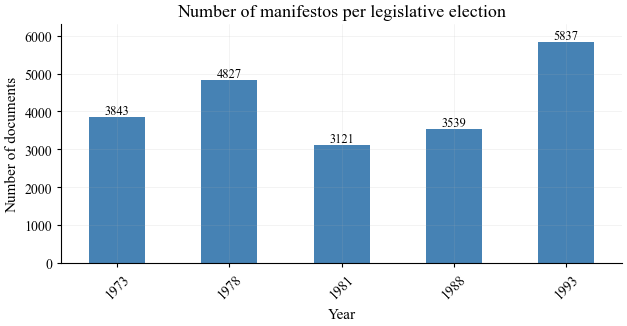

In [8]:
# Documents per legislative election year

docs_per_year = df["year"].value_counts().sort_index()
docs_per_year.index = docs_per_year.index.astype(int).astype(str)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
docs_per_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of manifestos per legislative election")
ax.set_xlabel("Year")
ax.set_ylabel("Number of documents")
ax.tick_params(axis="x", rotation=45)

for i, v in enumerate(docs_per_year.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, docs_per_year.max() * 1.08)

plt.tight_layout()
plt.savefig("charts/01_docs_per_year.png", dpi=150)
plt.show()

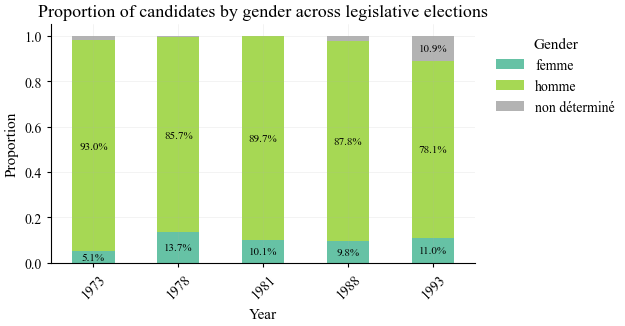

In [9]:
# Gender distribution over time — illustrates the slow feminization of candidacies
gender_over_time = temporal_distribution(df, group_col="titulaire-sexe")

# Convert to proportions per year
gender_props = gender_over_time.div(gender_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
gender_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates by gender across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02a_gender_over_time.png", dpi=150)
plt.show()

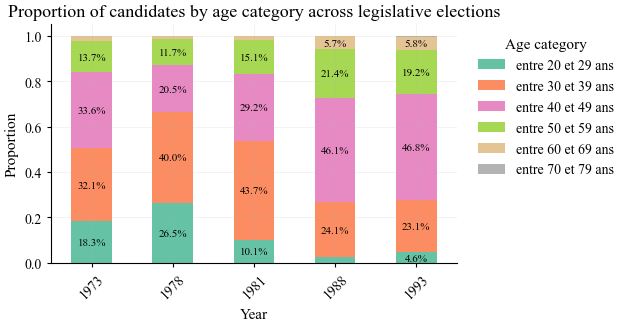

In [10]:
# Age distribution over time — politicians gets older or younger ?
age_over_time = temporal_distribution(df, group_col="titulaire-age-tranche")

# Convert to proportions per year
age_props = age_over_time.div(age_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
age_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates by age category across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Age category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02b_age_over_time.png", dpi=150)
plt.show()

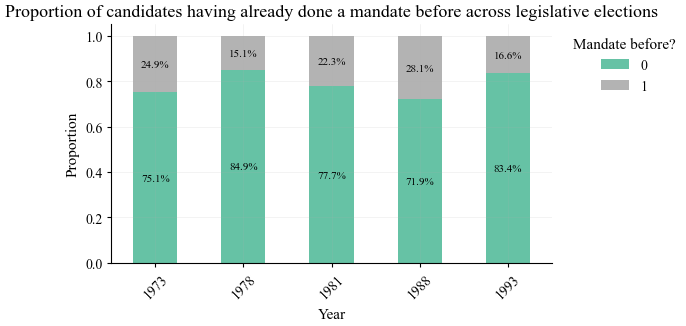

In [11]:
# Mandate_before distribution over time — is there a professionalisation of the politics?
mandate_before_over_time = temporal_distribution(df, group_col="dummy_titulaire_mandat_passe")

# Convert to proportions per year
mandate_before_props = mandate_before_over_time.div(mandate_before_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
mandate_before_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates having already done a mandate before across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Mandate before?", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02c_mandate_before_over_time.png", dpi=150)
plt.show()

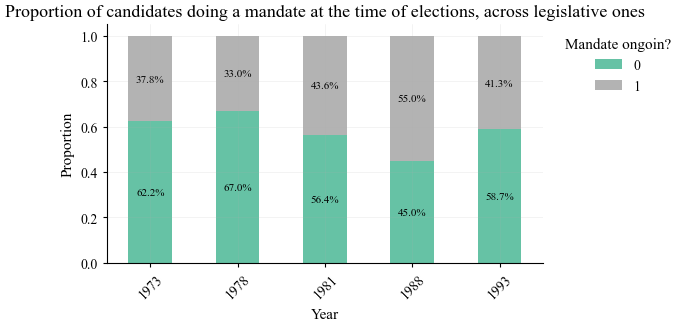

In [12]:
# Mandate_en_cours distribution over time — is there a professionalisation of the politics?
mandate_en_cours_over_time = temporal_distribution(df, group_col="dummy_titulaire_mandat_en_cours")

# Convert to proportions per year
mandate_en_cours_props = mandate_en_cours_over_time.div(mandate_en_cours_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
mandate_en_cours_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates doing a mandate at the time of elections, across legislative ones")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Mandate ongoin?", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02d_mandate_en_cours_over_time.png", dpi=150)
plt.show()

#### Volume of manifestos per election

The number of archived manifestos varies substantially across the five
legislative elections covered (1973, 1978, 1981, 1988, 1993), ranging from
roughly 3,100 documents in 1981 to about 5,800 in 1993. This imbalance has two
implications. First, the time slices used for the Dynamic Topic Model will not
be of equal size, which is acceptable as long as the slice ordering is
respected. Second, any per-year average should be interpreted in light of these
differences in coverage rather than as a direct measure of political activity.


#### Gender of the candidates accross time

Female candidacies remain a small minority across all five elections,
oscillating between roughly 5% (1973) and 14% (1978), with no clear monotonic
trend over the period. The 1993 election introduces a noticeable share of
*non-déterminé* cases, which reflects metadata quality rather than a real
sociological change. This low level of female representation makes any
finely-grained sex × topic analysis statistically tenuous, and we will treat
sex as a secondary covariate rather than a primary axis of analysis.

#### Age of the candidates accross time

#### Mandate before and mandate still ongoing


==> commentaire à updater et à ajouter

### Occupations of the candidates

#### Before harmonizing and creating occupations' categories

In [13]:
professions = (
    df["titulaire-profession"]
    .value_counts(dropna=False)
    .rename_axis("profession")
    .reset_index(name="n_documents")
)
professions.to_csv("data/professions.csv", index=False, encoding="utf-8")

print(f"{len(professions)} professions uniques sauvegardées dans data/professions.csv")
professions.head(15)

3397 professions uniques sauvegardées dans data/professions.csv


,profession,n_documents
0,NaN,9481
1,professeur,480
2,avocat,368
3,chef d'entreprise,234
4,ingénieur,232
5,instituteur,213
6,docteur,202
7,médecin,188
8,enseignant,183
9,agriculteur,148


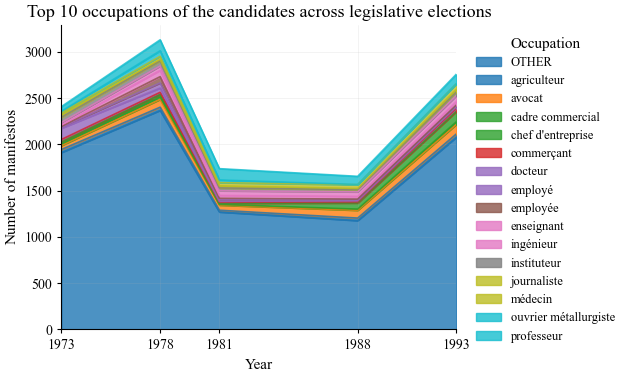

In [14]:
# Top political affiliations across time (stacked area)
jobs_over_time = temporal_distribution(df, group_col="titulaire-profession", top_n=15)

fig, ax = plt.subplots(figsize=(6.5, 4))
jobs_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title("Top 10 occupations of the candidates across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of manifestos")
ax.set_xticks(jobs_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Occupation", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/03_jobs_over_time.png", dpi=150)
plt.show()

==> commentaire to add on before + need to create categories

In [15]:
df, occ_dummies, cat_dummies, diag = add_occupation_columns(
    df, source_col="titulaire-profession", top_n_occupations=30
)
print_occupation_diagnostic(diag, df)

Canonical occupations distincts : 2041

Top 15 occupations :
   1184  professeur (collège, lycée)
    725  médecin
    625  ouvrier
    563  avocat
    498  ingénieur
    491  cadre
    331  professeur université
    331  chef d'entreprise
    292  instituteur
    278  employé
    210  directeur
    186  agriculteur
    171  technicien
    165  commerçant
    165  journaliste

Occupation categories (distribution) :
occupation_category
Aucun                                              9481
Enseignement & recherche                           2350
Cadres & dirigeants                                1652
Santé                                              1265
Ouvriers                                           1089
Employés & services                                1072
Ingénierie & technique                             1042
Justice & droit                                     713
Fonction publique & forces                          520
Commerce & artisanat                                449
H

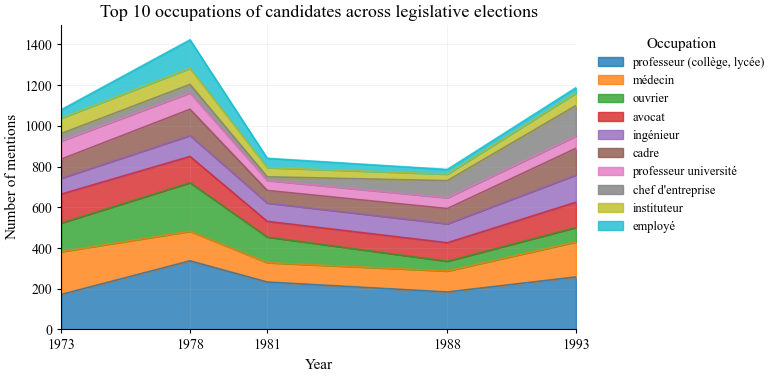

In [16]:
TOP_N = 10

top_occ_names = diag["top_occupations"][:TOP_N]
occ_over_time = occ_dummies[top_occ_names].groupby(df["year"]).sum()

fig, ax = plt.subplots(figsize=(8, 4))
occ_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title(f"Top {TOP_N} occupations of candidates across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(occ_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Occupation", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/03a_occupations_over_time_processed.png", dpi=150)
plt.show()

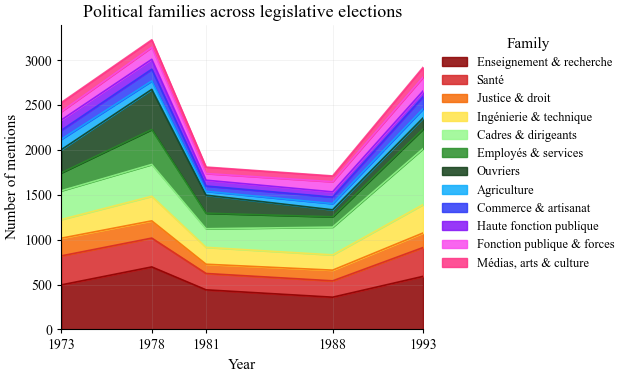

In [17]:
cat_to_plot = [f for f in CATEGORY_ORDER if f != "Non mentionné"]
cat_over_time = cat_dummies[cat_to_plot].groupby(df["year"]).sum()

cat_colors = {
    "Enseignement & recherche":    "#8B0000",
    "Santé":                       "#D62728",
    "Justice & droit":             "#F66B07",
    "Ingénierie & technique" :     "#FFE347",
    "Cadres & dirigeants" :        "#97F98E",
    "Employés & services":         "#298E29",
    "Ouvriers":                    "#133F18",
    "Agriculture":                 "#0EADFC",
    "Commerce & artisanat":        "#2D3AF7",
    "Haute fonction publique" :    "#8615F7",
    "Fonction publique & forces" : "#F94AED",
    "Médias, arts & culture" :     "#FE3384",
}
colors = [cat_colors[f] for f in cat_to_plot]

fig, ax = plt.subplots(figsize=(6.5, 4))
cat_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.85, color=colors)
ax.set_title("Political families across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(cat_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/03b_occ_categories_over_time_processed.png", dpi=150)
plt.show()

### Parties supporting the electoral lists

In [18]:
# Analyzing the titulaire-soutien and titulaire-liste columns
# to see if we can regroup together certain values of each

rows = []
for col in ["titulaire-soutien", "titulaire-liste"]:
    counts = df[col].value_counts(dropna=False)
    for value, count in counts.items():
        rows.append({
            "column": col,
            "value": value,
            "count": count,
        })

parties = pd.DataFrame(rows)
parties.to_csv("data/processed/value_counts_soutien_liste.csv", index=False, encoding="utf-8")
print(parties.head(10))

              column                                              value  count
0  titulaire-soutien                                                NaN   4040
1  titulaire-soutien                          Parti communiste français   2474
2  titulaire-soutien                                   Parti socialiste   1735
3  titulaire-soutien                                     Front national   1366
4  titulaire-soutien                                     Lutte ouvrière   1023
5  titulaire-soutien  Rassemblement pour la République;Union pour la...    764
6  titulaire-soutien                   Rassemblement pour la République    637
7  titulaire-soutien  Union pour la démocratie française;Rassembleme...    455
8  titulaire-soutien                            Parti socialiste unifié    441
9  titulaire-soutien  Nouveaux écologistes du rassemblement nature e...    387


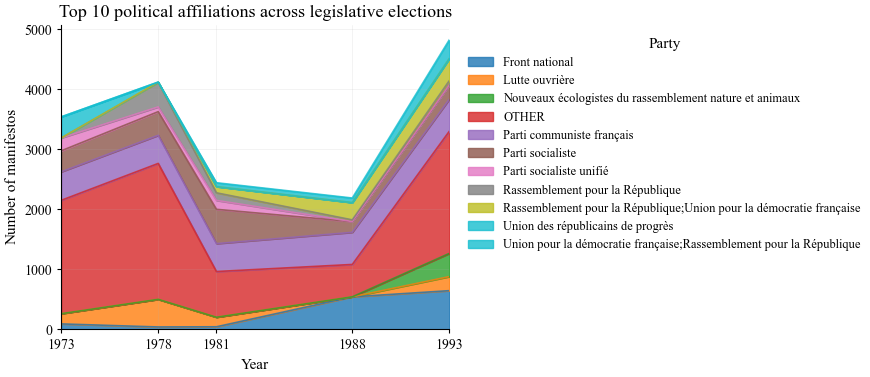

In [19]:
# Top political affiliations across time (stacked area)
party_over_time = temporal_distribution(df, group_col="titulaire-soutien", top_n=10)

fig, ax = plt.subplots(figsize=(9, 4))
party_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title("Top 10 political affiliations across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of manifestos")
ax.set_xticks(party_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/04_parties_over_time.png", dpi=150)
plt.show()

#### Before harmonizing and creating political categories

One can already see that there is some values that can be brought together : "Rassemblement pour la République; Union pour la démocratie française" is the same as "Union pour la démocratie française; Rassemblement pour la République". I analyzed the csv further and wrote the parties_processing.py script to take care of all the different cases.


The stacked area plot of the top eight `titulaire-soutien` values reveals the
expected shifts of the French political landscape over the period. The Front
National appears only from the 1980s onward, mirroring its historical rise.
Coalition labels (e.g., *RPR;UDF*, *UDF;RPR*) appear and disappear as
right-wing alliances reorganize. A large *OTHER* category remains visible
throughout, reflecting the long tail of small parties and independent
candidates. The plot also exposes the orthographic noise we noted earlier:
*RPR;UDF* and *UDF;RPR* are recorded as distinct labels even though they
denote the same coalition. A normalization step on party labels will be
necessary before any party-level topic analysis.

==> commentaire à udpater

In [20]:
# Fix the parties 

df, party_dummies, family_dummies, diagnostic = add_party_columns(
    df, source_col="titulaire-soutien", top_n_parties=30
)
print_party_diagnostic(diagnostic, df)

Partis canoniques distincts : 615

Top 10 partis :
   2975  Parti communiste français (PCF)
   2735  Parti socialiste (PS)
   2342  Rassemblement pour la République (RPR)
   2062  Union pour la démocratie française (UDF)
   1477  Front national (FN)
   1084  Mouvement des radicaux de gauche (MRG)
   1030  Lutte ouvrière (LO)
    709  Parti socialiste unifié (PSU)
    691  Union des républicains de progrès (URP)
    637  Centre national des indépendants et paysans (CNIP)

Familles principales (distribution) :
famille_principale
Aucun                                                     4040
Gauche socialiste                                         2524
Gauche communiste                                         2518
Centre+Droite                                             1982
Extrême droite                                            1575
Extrême gauche                                            1565
Droite                                                    1492
Centre                    

In [21]:
df[["titulaire-soutien", "soutien_partis", "soutien_familles", "famille_principale"]].head(10)

,titulaire-soutien,soutien_partis,soutien_familles,famille_principale
0,NaN,[],[],Aucun
1,Rassemblement pour la République,[Rassemblement pour la République (RPR)],[Droite],Droite
2,Parti socialiste,[Parti socialiste (PS)],[Gauche socialiste],Gauche socialiste
3,Parti ouvrier européen,[Parti ouvrier européen],[Divers / Sans étiquette],Divers / Sans étiquette
4,Parti ouvrier européen,[Parti ouvrier européen],[Divers / Sans étiquette],Divers / Sans étiquette
5,NaN,[],[],Aucun
6,Parti communiste français,[Parti communiste français (PCF)],[Gauche communiste],Gauche communiste
7,NaN,[],[],Aucun
8,Parti socialiste,[Parti socialiste (PS)],[Gauche socialiste],Gauche socialiste
9,Parti socialiste,[Parti socialiste (PS)],[Gauche socialiste],Gauche socialiste


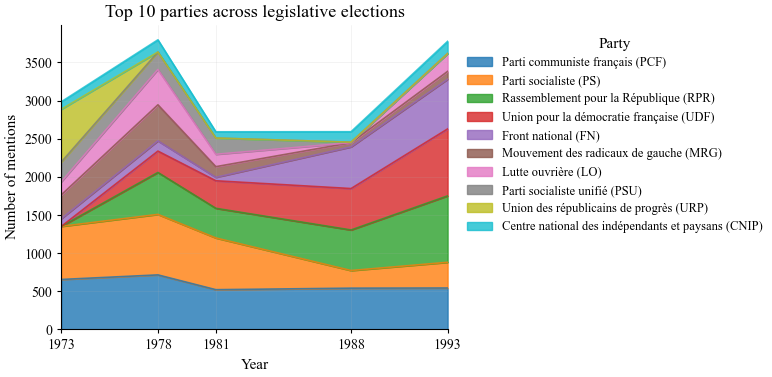

In [22]:
# Top parties across time (stacked area)

TOP_N = 10

top_party_names = diagnostic["top_parties"][:TOP_N]
party_over_time = party_dummies[top_party_names].groupby(df["year"]).sum()

fig, ax = plt.subplots(figsize=(8, 4))
party_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title(f"Top {TOP_N} parties across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(party_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/04a_parties_over_time_processed.png", dpi=150)
plt.show()

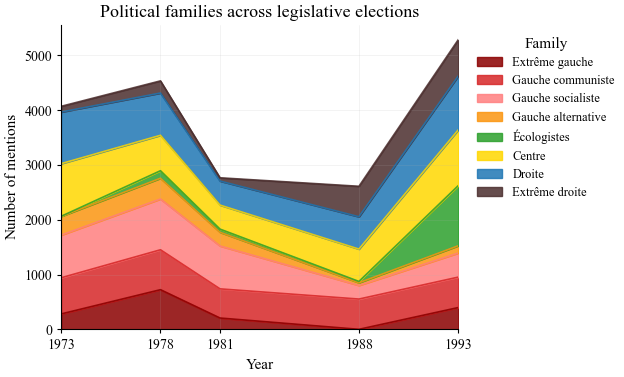

In [23]:
# Top political families across time (stacked area)

families_to_plot = [f for f in FAMILY_ORDER if f != "Divers / Sans étiquette"]
family_over_time = family_dummies[families_to_plot].groupby(df["year"]).sum()

family_colors = {
    "Extrême gauche":      "#8B0000",
    "Gauche communiste":   "#D62728",
    "Gauche socialiste":   "#FF7F7F",
    "Gauche alternative":  "#FB9510",
    "Écologistes":         "#2CA02C",
    "Centre":              "#FFD700",
    "Droite":              "#1F77B4",
    "Extrême droite":      "#4B2E2E",
}
colors = [family_colors[f] for f in families_to_plot]

fig, ax = plt.subplots(figsize=(6.5, 4))
family_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.85, color=colors)
ax.set_title("Political families across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(family_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/04b_polt_fam_over_time_processed.png", dpi=150)
plt.show()

#### Political affiliations across time



=> commentaire à add

### Occupations x parties and Job categories x political families

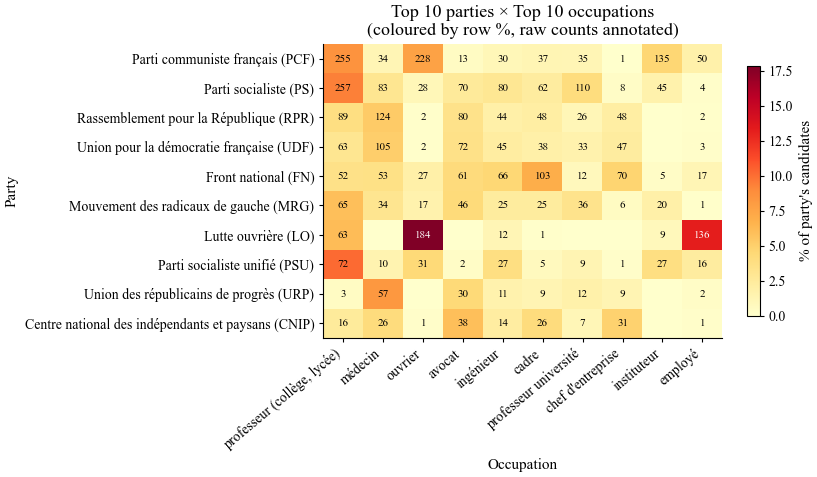

In [24]:
# Cross-analysis: top 10 parties × top 10 occupations
# Cell [i, j] = number of candidates supported by party i AND declaring occupation j.
# Colour = row-normalized % ("of party X's candidates, share with occupation Y"),
# raw counts annotated inside the cells.

TOP_N_PARTIES = 10
TOP_N_OCC     = 10

top_parties = diagnostic["top_parties"][:TOP_N_PARTIES]
top_occs    = diag["top_occupations"][:TOP_N_OCC]

# Co-occurrence count matrix via dummies (handles multi-label correctly)
cross_counts = party_dummies[top_parties].T.dot(occ_dummies[top_occs])

# Row-normalize by the actual number of candidates per party
party_totals = party_dummies[top_parties].sum(axis=0)
cross_pct    = cross_counts.div(party_totals, axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(cross_pct.values, aspect="auto", cmap="YlOrRd", vmin=0)
ax.grid(False)  # rcParams turns grid on by default — disable behind heatmap

ax.set_xticks(range(len(top_occs)))
ax.set_xticklabels(top_occs, rotation=40, ha="right")
ax.set_yticks(range(len(top_parties)))
ax.set_yticklabels(top_parties)

# Annotate cells with raw candidate counts
vmax = cross_pct.values.max()
for i in range(len(top_parties)):
    for j in range(len(top_occs)):
        n = int(cross_counts.iat[i, j])
        if n == 0:
            continue
        color = "white" if cross_pct.iat[i, j] > 0.6 * vmax else "black"
        ax.text(j, i, f"{n}", ha="center", va="center", fontsize=8, color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("% of party's candidates")

ax.set_title(f"Top {TOP_N_PARTIES} parties × Top {TOP_N_OCC} occupations\n"
             "(coloured by row %, raw counts annotated)")
ax.set_xlabel("Occupation")
ax.set_ylabel("Party")

plt.tight_layout()
plt.savefig("charts/04c_party_x_occupation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

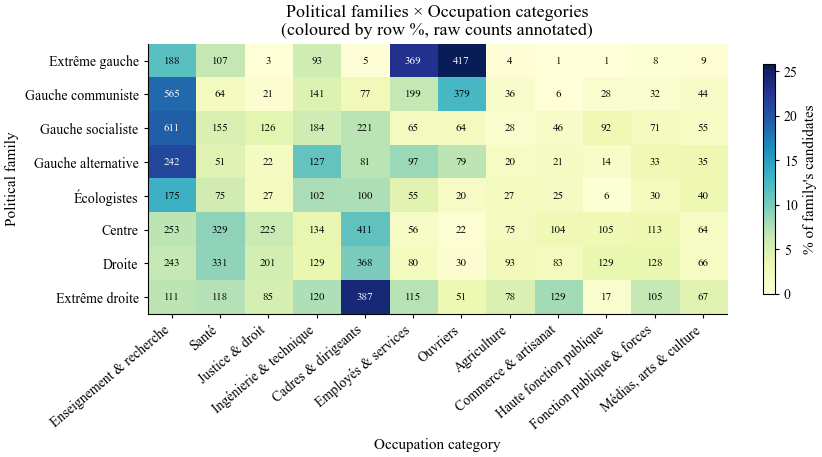

In [25]:
# Cross-analysis: political families × occupation categories
# Same logic as above, but on the higher-level groupings (no top-N needed: the
# CATEGORY_ORDER / FAMILY_ORDER lists are already curated).

families_to_plot   = [f for f in FAMILY_ORDER   if f != "Divers / Sans étiquette"]
categories_to_plot = [c for c in CATEGORY_ORDER if c != "Non mentionné"]

# Co-occurrence count matrix
cross_counts_fc = family_dummies[families_to_plot].T.dot(cat_dummies[categories_to_plot])

# Row-normalize by the number of candidates per political family
family_totals = family_dummies[families_to_plot].sum(axis=0)
cross_pct_fc  = cross_counts_fc.div(family_totals, axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(cross_pct_fc.values, aspect="auto", cmap="YlGnBu", vmin=0)
ax.grid(False)

ax.set_xticks(range(len(categories_to_plot)))
ax.set_xticklabels(categories_to_plot, rotation=40, ha="right")
ax.set_yticks(range(len(families_to_plot)))
ax.set_yticklabels(families_to_plot)

vmax = cross_pct_fc.values.max()
for i in range(len(families_to_plot)):
    for j in range(len(categories_to_plot)):
        n = int(cross_counts_fc.iat[i, j])
        if n == 0:
            continue
        color = "white" if cross_pct_fc.iat[i, j] > 0.6 * vmax else "black"
        ax.text(j, i, f"{n}", ha="center", va="center", fontsize=8, color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("% of family's candidates")

ax.set_title("Political families × Occupation categories\n"
             "(coloured by row %, raw counts annotated)")
ax.set_xlabel("Occupation category")
ax.set_ylabel("Political family")

plt.tight_layout()
plt.savefig("charts/04d_family_x_category_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Length of the professions de foi

            total         mean  median          std  min    max
n_chars  94349358  4457.379789  4017.0  2298.357776  139  25120
n_words  15065370   711.738555   639.0   368.197190   19   4002


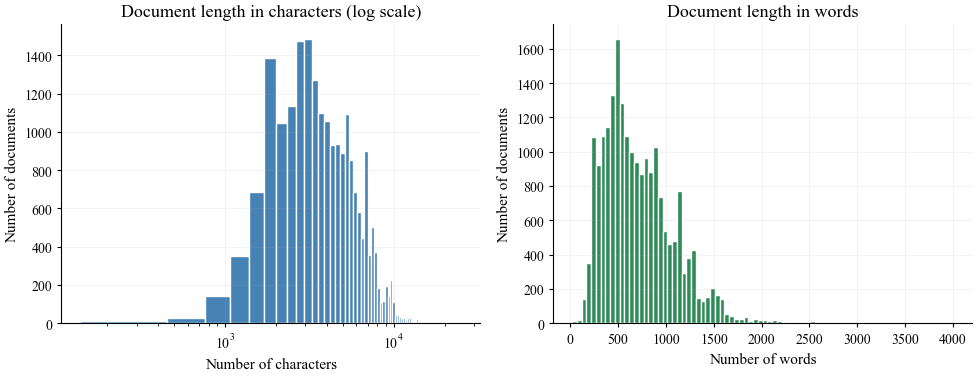

In [26]:
# Document length distribution
text_stats_summary = text_statistics(df)
print(text_stats_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Char length distribution (log scale to spot OCR failures)
df["text"].str.len().hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Document length in characters (log scale)")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of documents")

# Word length distribution
df["text"].str.split().str.len().hist(bins=80, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Document length in words")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Number of documents")

plt.tight_layout()
plt.savefig("charts/05a_text_lengths.png", dpi=150)
plt.show()

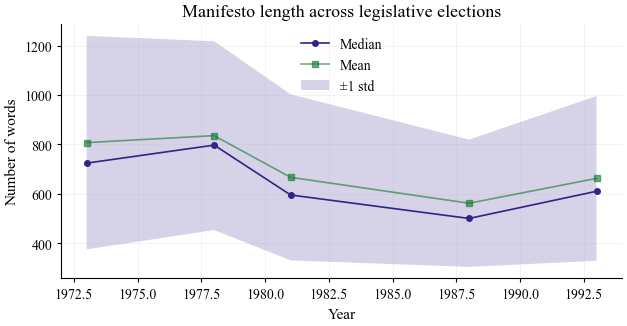

In [27]:
# Median document length over time — has OCR quality improved? Have manifestos changed in style?
length_by_year = (
    df.assign(n_words=df["text"].str.split().str.len())
    .groupby("year")["n_words"]
    .agg(["median", "mean", "std"])
)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(length_by_year.index, length_by_year["median"], marker="o", label="Median")
ax.plot(length_by_year.index, length_by_year["mean"],   marker="s", label="Mean", alpha=0.6)
ax.fill_between(
    length_by_year.index,
    length_by_year["mean"] - length_by_year["std"],
    length_by_year["mean"] + length_by_year["std"],
    alpha=0.2, label="±1 std"
)
ax.set_title("Manifesto length across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of words")
ax.legend()
plt.tight_layout()
plt.savefig("charts/05b_length_over_time.png", dpi=150)
plt.show()

#### Document-length distribution accross time

The character-length histogram (left, log scale) shows a small left-tail of
documents below ~500 characters that is well separated from the bulk of the
distribution centered around 2,000–5,000 characters. This left-tail is most
likely caused by OCR failures (very partial transcriptions) and motivates a
minimum-length filter before topic modeling. The word-length histogram
(right, linear scale) confirms a right-skewed distribution: the median
manifesto contains a few hundred words, while a small number of documents
exceed 2,000 words.

#### Manifesto length over time

Median and mean document lengths drop noticeably between 1978 (~800 words)
and 1988 (~550 words), then partially recover in 1993. This downward trend
could reflect a real stylistic evolution toward more concise manifestos, but
it is equally plausible that variations in OCR quality across decades
contribute to it. We do not attempt to disentangle these two hypotheses here,
but flag the trend as a potential confounder when interpreting topic
prevalence over time.


==> commentaire à updater : clairement we need some pre-processing here

### 1.3 Processing the text data

The preprocessing pipeline follows the recipe outlined in the course
(*Topic Modeling*) and consists of:

1. **OCR cleanup** — removing recurring archival headers (Sciences Po,
   République française, Élections législatives), mending hyphenated 
   line breaks, dropping non-letters and isolated single characters.
2. **Lemmatization** — using `spaCy`'s French model 
   (`fr_core_news_md`) with the parser and NER components disabled for speed.
3. **POS filtering** — keeping only content words (nouns, proper nouns,
   adjectives, verbs).
4. **Stopword removal** — combining spaCy's default French stopword list
   with a domain-specific list (generic electoral vocabulary, formulas of
   address, month names) iteratively refined by inspection of early model
   outputs.

The result is a list of lemmatized tokens per document, persisted to
`data/processed/tokens.pkl` for reuse across sessions.

In [28]:
# Preprocess the corpus for topic modeling
# This takes ~10-15 minutes on the 21k documents.
# I pickle the result so I don't have to redo this in future sessions
# Next run, I can just load the processed tokens from disk and skip directly to modeling and analysis

if FIRST_RUN:
    # Make sure the output directory exists
    Path("data/processed").mkdir(parents=True, exist_ok=True)

    # Run preprocessing on the entire corpus
    tokens = preprocess_corpus(df["text"].tolist())

    # Save to disk
    with open("data/processed/tokens_v4.pkl", "wb") as f:
        pickle.dump(tokens, f)
else:
    # Load preprocessed tokens from disk
    with open("data/processed/tokens_v4.pkl", "rb") as f:
        tokens = pickle.load(f)

assert len(tokens) == len(df), "tokens / df length mismatch"
print(f"Preprocessed {len(tokens)} documents")
print(f"Vocabulary size (raw): {len(set(t for doc in tokens for t in doc))}")

Preprocessed 21167 documents
Vocabulary size (raw): 92202


In [29]:
# Diagnostic 1 — quels compounds ont matché ?
compound_hits = summarize_compound_hits(tokens, top_n=30)

=== Found 403 distinct compound tokens ===
Total compound occurrences: 118,555

=== Top 30 ===
  programme_commun                                9089
  assemblee_nationale                             7937
  front_national                                  7038
  lutte_ouvriere                                  5810
  union_de_la_gauche                              5561
  parti_communiste_francais                       5091
  president_republique                            4613
  securite_sociale                                3553
  majorite_presidentielle                         3526
  justice_sociale                                 3346
  nouvelle_majorite                               2844
  le_pen                                          2619
  pouvoir_achat                                   2572
  conseil_general                                 2541
  peine_mort                                      2000
  rpr_udf                                         2000
  giscard_destaing       

In [30]:
# Diagnostic 2 — tokens suspects qui devraient avoir disparu
freq = summarize_token_frequencies(
    tokens,
    suspicious_tokens=("die", "und", "fur", "marie", "sciences", "po",
                       "cevipof", "vilain", "renne", "vosge", "tion"),
    doc_pct_threshold=40.0,
    top_n=20,
)

=== Suspicious tokens (should ideally be 0) ===
  'die            ' in     0 docs (  0.0%)
  'und            ' in     0 docs (  0.0%)
  'fur            ' in     0 docs (  0.0%)
  'marie          ' in    21 docs (  0.1%) ⚠
  'sciences       ' in     0 docs (  0.0%)
  'po             ' in     0 docs (  0.0%)
  'cevipof        ' in     0 docs (  0.0%)
  'vilain         ' in     0 docs (  0.0%)
  'renne          ' in     0 docs (  0.0%)
  'vosge          ' in     0 docs (  0.0%)
  'tion           ' in     0 docs (  0.0%)

=== Top 20 tokens by total count ===
  gauche                         total=  32544  in  47.6% docs
  travailleur                    total=  32332  in  31.2% docs
  socialiste                     total=  27794  in  50.7% docs
  emploi                         total=  24320  in  56.8% docs
  communiste                     total=  23303  in  32.8% docs
  droite                         total=  22731  in  36.6% docs
  travail                        total=  21946  in  54.3% doc

In [31]:
# Diagnostic 3 — visuel sur 3 docs (un avant, un milieu, un fin de période)
inspect_documents(df, tokens, n_samples=3, n_chars=1000)

Document 20952
  id      : EL104_L_1978_03_042_05_1_PF_07
  year    : 1978
  titulaire-soutien: nan
  n_chars : 5053
  n_tokens: 269

--- ORIGINAL TEXT (first 1000 chars) ---
RÉPUBLIQUE FRANÇAISE
DÉPARTEMENT DE LA LOIRE
LIBERTÉ ÉGALITÉ
FRATERNITÉ
5e CIRCONSCRIPTION DE LA LOIRE
ÉLECTIONS LÉGISLATIVES - 12 MARS 1978
Une PLAISANTERIE, un Candidat
non au barrage de villerest ?
OUI ... A condition que les buldozers qui bouffent les collines à Commelle-Vernay et Villerest soient une PLAISANTERIE; A condition aussi que, détruire 30 km de Gorges de la Loire avec tout son patrimoine et son économie, soit une PLAISANTERIE; 1200 ha de chambons inondés, 180 exploitations agricoles atteintes, des centaines de personnes déplacées, expulsées, fermes et maisons dynamitées, tuer faune et flore, empoisonner la Loire : IL N'EXISTE PAS PLUS JOYEUSE PLAISANTERIE !.
POURTANT, UN CANDIDAT "NON AU BARRAGE DE VILLEREST", ce n'est pas uniquement se lamenter sur l'avenir des Gorges de la Loire, c'est avant tout 

Could be even more improved (through the EXTRA STOPWORDS, maybe I haven't been enough conservative), but I decide to keep some words that a very present, but that could actually be part of several topics.

In [32]:
# Quality filter on professions de foi.
# I filter on TWO criteria computed on different stages of the pipeline:
#   - char length of the raw OCR text (very short = OCR failure)
#   - number of useful tokens after preprocessing (the actual signal LDA sees).
# Doing it in this order means we don't pre-emptively discard documents whose
# raw form looks short but lemmatize into rich content (or vice versa).

MIN_CHARS  = 500     # raw OCR floor: clear OCR failure
MIN_TOKENS = 50      # post-preprocessing floor: LDA needs enough signal
MAX_TOKENS = 1000    # post-preprocessing ceiling: probably concatenated docs

n_tokens = pd.Series([len(t) for t in tokens], index=df.index, name="n_tokens")

mask = (
    (df["text"].str.len() >= MIN_CHARS) &
    (n_tokens >= MIN_TOKENS) &
    (n_tokens <= MAX_TOKENS)
)

# Diagnostic
print(f"Before filter                       : {len(df):>6d} docs")
print(f"  too few chars (<{MIN_CHARS})      : {(df['text'].str.len() < MIN_CHARS).sum():>6d}")
print(f"  too few tokens (<{MIN_TOKENS})    : {(n_tokens < MIN_TOKENS).sum():>6d}")
print(f"  too many tokens (>{MAX_TOKENS})   : {(n_tokens > MAX_TOKENS).sum():>6d}")
print(f"After filter                        : {mask.sum():>6d} docs ({mask.mean():.1%})")


Before filter                       :  21167 docs
  too few chars (<500)      :     14
  too few tokens (<50)    :    312
  too many tokens (>1000)   :      3
After filter                        :  20852 docs (98.5%)


In [33]:
# Apply the mask CONSISTENTLY to df and tokens, then RE-RUN add_party_columns
# on the filtered corpus so the top-30 reflects the actual analysis sample.
# This is the single most important alignment step in the whole notebook —
# every downstream cell must use these *_clean variables (or rebound names).

mask_arr = mask.to_numpy()  # avoid index-vs-position pitfalls

# 1) Mask df and tokens
df_clean     = df[mask].reset_index(drop=True).copy()
tokens_clean = [t for t, keep in zip(tokens, mask_arr) if keep]

# 2) Drop the columns added by the earlier add_party_columns call so we
#    can re-run cleanly on the filtered corpus
cols_added_by_party_fn = ["soutien_partis", "soutien_familles", "famille_principale"]
df_clean = df_clean.drop(
    columns=[c for c in cols_added_by_party_fn if c in df_clean.columns]
)

# 3) Re-run add_party_columns on df_clean. The top-30 is recomputed on the
#    filtered corpus, so dummies and derived columns are internally consistent.
df_clean, party_dummies, family_dummies, diagnostic = add_party_columns(
    df_clean, source_col="titulaire-soutien", top_n_parties=30
)
print_party_diagnostic(diagnostic, df_clean)

# 4) Same for occupation columns — drop and re-run
cols_added_by_occ_fn = ["profession_categories", "profession_categorie_principale"]
# Adjust this list to whatever columns add_occupation_columns adds in your codebase
df_clean = df_clean.drop(
    columns=[c for c in cols_added_by_occ_fn if c in df_clean.columns]
)
df_clean, occ_dummies, cat_dummies, occ_diag = add_occupation_columns(
    df_clean, source_col="titulaire-profession", top_n_occupations=30
)
print_occupation_diagnostic(occ_diag, df_clean)

# 5) Sanity check
assert (
    len(df_clean) == len(tokens_clean)
    == len(party_dummies) == len(family_dummies)
    == len(occ_dummies) == len(cat_dummies)
), (
    f"Length mismatch: df={len(df_clean)}, tokens={len(tokens_clean)}, "
    f"party={len(party_dummies)}, family={len(family_dummies)}, "
    f"occ={len(occ_dummies)}, cat={len(cat_dummies)}"
)
print(f"All objects aligned at {len(df_clean)} rows.")

# 6) Rebind tokens so downstream cells don't need renaming
tokens = tokens_clean

Partis canoniques distincts : 610

Top 10 partis :
   2969  Parti communiste français (PCF)
   2695  Parti socialiste (PS)
   2294  Rassemblement pour la République (RPR)
   2018  Union pour la démocratie française (UDF)
   1475  Front national (FN)
   1073  Mouvement des radicaux de gauche (MRG)
   1030  Lutte ouvrière (LO)
    707  Parti socialiste unifié (PSU)
    674  Union des républicains de progrès (URP)
    629  Centre national des indépendants et paysans (CNIP)

Familles principales (distribution) :
famille_principale
Aucun                                                     3897
Gauche communiste                                         2515
Gauche socialiste                                         2477
Centre+Droite                                             1939
Extrême droite                                            1572
Extrême gauche                                            1565
Droite                                                    1466
Centre                    

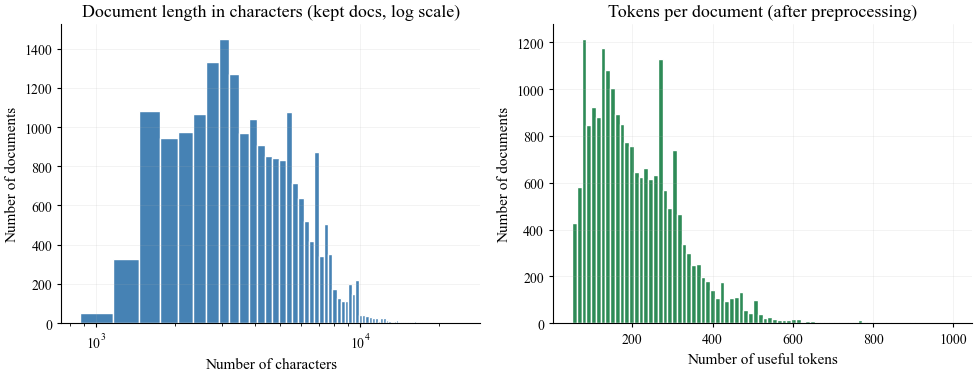

count    20852.0
mean       210.1
std        111.5
min         50.0
25%        125.0
50%        189.0
75%        274.0
max        999.0
Name: n_tokens, dtype: float64


In [34]:
# Sanity-check the post-preprocessing token-length distribution.
# This is the distribution that LDA/NMF actually see, so it's the one
# that matters for interpreting the model.

token_lengths = pd.Series([len(t) for t in tokens], name="n_tokens")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_clean["text"].str.len().hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Document length in characters (kept docs, log scale)")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of documents")

token_lengths.hist(bins=80, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Tokens per document (after preprocessing)")
axes[1].set_xlabel("Number of useful tokens")
axes[1].set_ylabel("Number of documents")

plt.tight_layout()
plt.savefig("charts/06_lengths_after_preprocessing.png", dpi=150)
plt.show()

print(token_lengths.describe().round(1))

In [35]:
import pickle
texts = df_clean["text"].tolist()
with open("data/processed/texts_for_colab.pkl", "wb") as f:
    pickle.dump(texts, f)
print(f"Exported {len(texts)} texts, file size: ", end="")
import os
print(f"{os.path.getsize('data/processed/texts_for_colab.pkl')/1e6:.1f} MB")

Exported 20852 texts, file size: 96.7 MB


## 2. First topic analysis : LDA and NMF

### Hidden hyperparameters: filterting the remaining vocabulary

In [36]:
# Simulate Dictionary.filter_extremes on the freq table from summarize_token_frequencies
# Reuses `freq` (cell 44) — no need to rebuild a Gensim Dictionary.

NO_BELOW = 15      # drop tokens in fewer than N docs
NO_ABOVE = 0.6     # drop tokens in more than this fraction of docs
KEEP_N   = 10000   # cap vocabulary
TOK_K = 10

# Same logic as gensim.Dictionary.filter_extremes:
#   1) no_below on dfs    2) no_above on dfs/N    3) top keep_n by dfs
kept = (
    freq[(freq["n_docs"] >= NO_BELOW) & (freq["doc_pct"] <= NO_ABOVE * 100)]
    .nlargest(KEEP_N, "n_docs")
)
dropped_high = freq[freq["doc_pct"] >  NO_ABOVE * 100]
dropped_low  = freq[freq["n_docs"]  <  NO_BELOW]

print(f"Vocab: {len(freq):,} → {len(kept):,} kept "
      f"(dropped {len(dropped_high)} too frequent, {len(dropped_low)} too rare)\n")

print(f"Dropped because too frequent (doc_pct > {NO_ABOVE*100:.0f}%):")
print(dropped_high.head(TOK_K).to_string(index=False))

print(f"\nDropped because too rare (n_docs < {NO_BELOW}, top by total mentions):")
print(dropped_low.nlargest(TOK_K, "total").to_string(index=False))

print(f"\nTop {TOK_K} kept tokens by TOTAL MENTIONS:")
print(kept.nlargest(TOK_K, "total").to_string(index=False))

print(f"\nTop {TOK_K} kept tokens by DOCUMENT FREQUENCY:")
print(kept.nlargest(TOK_K, "n_docs").to_string(index=False))

Vocab: 92,202 → 10,000 kept (dropped 0 too frequent, 81656 too rare)

Dropped because too frequent (doc_pct > 60%):
Empty DataFrame
Columns: [token, total, n_docs, doc_pct]
Index: []

Dropped because too rare (n_docs < 15, top by total mentions):
  token  total  n_docs  doc_pct
    mau    131      11 0.051968
    nei    120      11 0.051968
    tei     91       7 0.033070
corsica     80       8 0.037795
   roto     65      13 0.061416
 frayss     64      13 0.061416
 megret     63      13 0.061416
 euskal     63      12 0.056692
rosiere     61       5 0.023622
   durr     59      13 0.061416

Top 10 kept tokens by TOTAL MENTIONS:
      token  total  n_docs   doc_pct
     gauche  32544   10075 47.597676
travailleur  32332    6602 31.190060
 socialiste  27794   10727 50.677942
     emploi  24320   12029 56.829026
 communiste  23303    6936 32.767988
     droite  22731    7756 36.641943
    travail  21946   11489 54.277885
    liberte  19765    9988 47.186658
 conseiller  16908    8965 42

In the end, after several tries, I decided to go for in total 10 000 tokens, and to exclude mostly the very seldom ones (the vasst majority is present in less than 15 documents), and keep some tokens appearing in a high proportion of 'profession de foi' but because they convey a very important meaning in this context (like 'emploi').

In [37]:
NO_BELOW = 15
NO_ABOVE = 0.6
KEEP_N = 10000

### Hyperparameter sweep on K for LDA and NMF

In [38]:
# First sweep analysis run gave me that the optimal number of topics is 10 according to the coherence criterion, but the diversity was better with more topics
# cf. the previous commit where I ran the first sweep with a wider range of values for 
# so I want to explore a bit more the range around 10, and see if I can get better diversity without losing too much coherence
# also this run is on a better preprocessed corpus, so the results might be different from the first run where I had a lot of noise in the data

K_GRID_SHORT = [5, 8, 10, 12, 15, 18, 20]

if FIRST_RUN:
    t0 = time.time()
    lda_sweep = sweep_n_topics(
        model_factory   = lambda k: LDATopicModel(
            n_topics    = k,
            no_below    = NO_BELOW,
            no_above    = NO_ABOVE,
            keep_n      = KEEP_N,
        ),
        n_topics_grid   = K_GRID_SHORT,
        documents       = tokens,      
        tokenized_texts = tokens,
    )
    print(f"\nLDA sweep done in {(time.time()-t0)/60:.1f} min")
    print(lda_sweep)
    lda_sweep.to_csv("data/processed/lda_sweep_v4.csv", index=False)

    t0 = time.time()
    nmf_sweep = sweep_n_topics(
        model_factory   = lambda k: NMFTopicModel(
            n_topics    = k,
            max_features= KEEP_N,
            min_df      = NO_BELOW,
            max_df      = NO_ABOVE,
        ),
        n_topics_grid   = K_GRID_SHORT,
        documents       = tokens,
        tokenized_texts = tokens,
    )
    print(f"\nNMF sweep done in {(time.time()-t0)/60:.1f} min")
    print(nmf_sweep)
    nmf_sweep.to_csv("data/processed/nmf_sweep_v4.csv", index=False)
else:
    lda_sweep = pd.read_csv("data/processed/lda_sweep_v4.csv")
    nmf_sweep = pd.read_csv("data/processed/nmf_sweep_v4.csv")

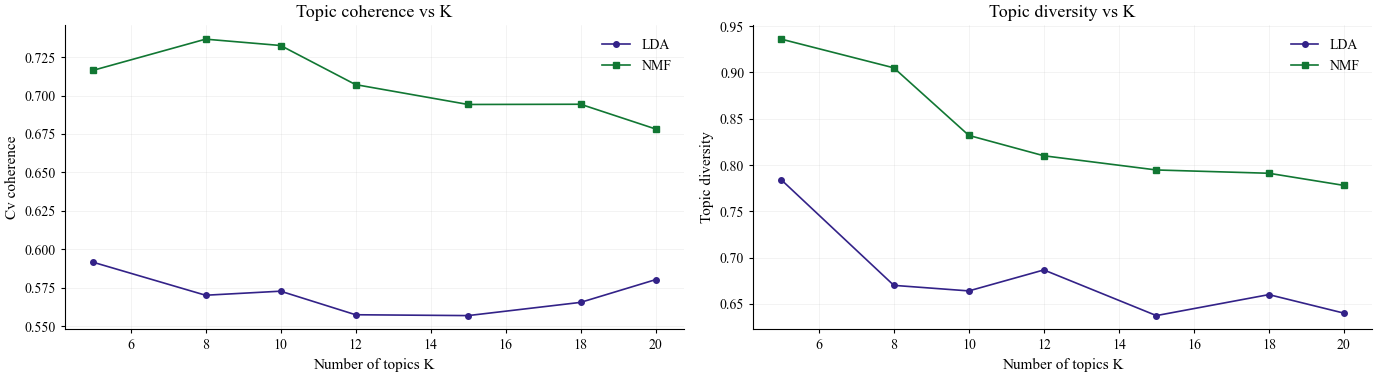

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Coherence
axes[0].plot(lda_sweep["n_topics"], lda_sweep["coherence_cv"], marker="o", label="LDA")
axes[0].plot(nmf_sweep["n_topics"], nmf_sweep["coherence_cv"], marker="s", label="NMF", )
axes[0].set_xlabel("Number of topics K")
axes[0].set_ylabel("Cv coherence")
axes[0].set_title("Topic coherence vs K")
axes[0].legend()

# Diversity
axes[1].plot(lda_sweep["n_topics"], lda_sweep["diversity"], marker="o", label="LDA")
axes[1].plot(nmf_sweep["n_topics"], nmf_sweep["diversity"], marker="s", label="NMF")
axes[1].set_xlabel("Number of topics K")
axes[1].set_ylabel("Topic diversity")
axes[1].set_title("Topic diversity vs K")
axes[1].legend()

plt.tight_layout()
plt.savefig("charts/06_sweep_v4_results.png", dpi=200, bbox_inches="tight")
plt.show()

In [40]:
# Just wanted to make sure that the coherence didn't continue to increase for LDA after 20 topics
# Because maybe NMF needs very few topics whereas LDA needs a lot of them
 
K_GRID_SUPP = [22, 25, 28, 30]

if FIRST_RUN:
    t0 = time.time()
    lda_sweep_bis = sweep_n_topics(
            model_factory   = lambda k: LDATopicModel(
                n_topics    = k,
                no_below    = NO_BELOW,
                no_above    = NO_ABOVE,
                keep_n      = KEEP_N,
            ),
            n_topics_grid   = K_GRID_SUPP,
            documents       = tokens,      
            tokenized_texts = tokens,
        )
    print(f"\nLDA sweep done in {(time.time()-t0)/60:.1f} min")
    print(lda_sweep_bis)
    lda_sweep_bis.to_csv("data/processed/lda_sweep_v4bis.csv", index=False)

    t0 = time.time()
    nmf_sweep_bis = sweep_n_topics(
            model_factory   = lambda k: NMFTopicModel(
                n_topics    = k,
                max_features= KEEP_N,
                min_df      = NO_BELOW,
                max_df      = NO_ABOVE,
            ),
            n_topics_grid   = K_GRID_SUPP,
            documents       = tokens,
            tokenized_texts = tokens,
        )
    print(f"\nNMF sweep done in {(time.time()-t0)/60:.1f} min")
    print(nmf_sweep_bis)
    nmf_sweep_bis.to_csv("data/processed/nmf_sweep_v4bis.csv", index=False)
else:
    lda_sweep_bis = pd.read_csv("data/processed/lda_sweep_v4bis.csv")
    nmf_sweep_bis = pd.read_csv("data/processed/nmf_sweep_v4bis.csv")

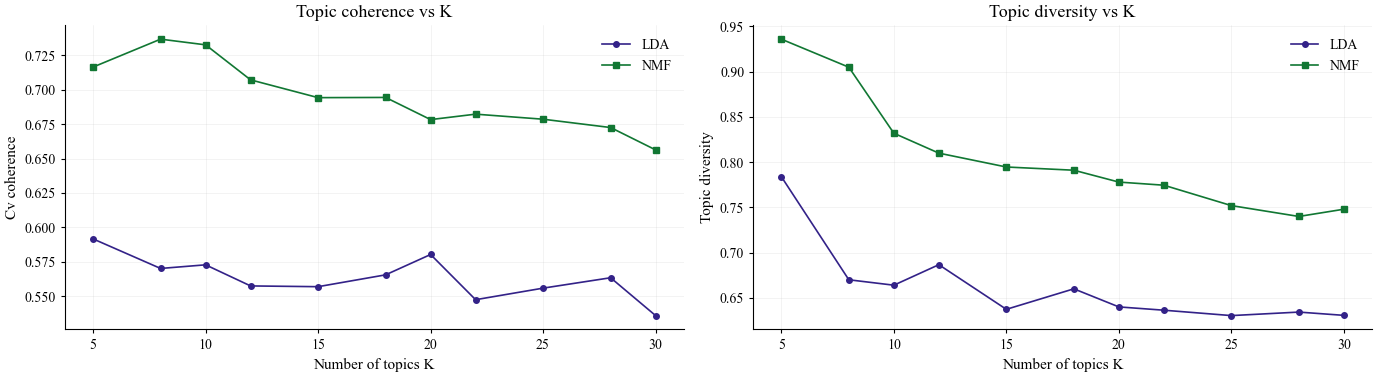

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lda_sweep_together = pd.concat([lda_sweep, lda_sweep_bis], ignore_index=True)
nmf_sweep_together = pd.concat([nmf_sweep, nmf_sweep_bis], ignore_index=True)

# Coherence
axes[0].plot(lda_sweep_together["n_topics"], lda_sweep_together["coherence_cv"], marker="o", label="LDA")
axes[0].plot(nmf_sweep_together["n_topics"], nmf_sweep_together["coherence_cv"], marker="s", label="NMF", )
axes[0].set_xlabel("Number of topics K")
axes[0].set_ylabel("Cv coherence")
axes[0].set_title("Topic coherence vs K")
axes[0].legend()

# Diversity
axes[1].plot(lda_sweep_together["n_topics"], lda_sweep_together["diversity"], marker="o", label="LDA")
axes[1].plot(nmf_sweep_together["n_topics"], nmf_sweep_together["diversity"], marker="s", label="NMF")
axes[1].set_xlabel("Number of topics K")
axes[1].set_ylabel("Topic diversity")
axes[1].set_title("Topic diversity vs K")
axes[1].legend()

plt.tight_layout()
plt.savefig("charts/06_sweep_v4bis_results.png", dpi=200, bbox_inches="tight")

### Choosing the number of topics K

I performed several sweeps of K under different preprocessing configurations:
a stricter version (`no_above=0.5`, `keep_n=8000`) covering K ∈ {5, 10, 15,
20, 25, 30, 40, 50}, and a more permissive version (`no_above=0.65`,
`keep_n=18000`) covering K ∈ {8, 10, 12, 15}. With this preprocessing, I
concluded that it would be best to strict preprocessing setting (`no_above=0.5`, `keep_n=8000`) for
the final models, as it yielded slightly better LDA coherence at K = 10.

But looking at the topics themselves and seeing that there were still too many undistinctive tokens, 
I changed the underlying preprocessing to exclude more common expressions in political discourse of the time,
and I conducted more sweep anlaysis, after having fix the preprocessing to (`no_below=15`, `no_above=0.6`, `keep_n=10000`).
For each K ∈ {8, 10, 12, 15} (and also K ∈ {22, 25, 28, 30} in a second time) we evaluated Cv coherence 
(Röder et al. 2015) — the metric most correlated with human judgments of topic interpretability 
— and topic diversity (Dieng et al.2020).

The coherence and diversity sweeps initially suggested **K = 8** as the
optimal value (highest $C_v$ for NMF, second-highest topic diversity), but
qualitative inspection of the inferred topics revealed that this choice is
slightly too coarse for our analytical needs. In particular, the LDA model
at K = 8 merges environmental and economic-development vocabulary into a
single hybrid topic, conflating two themes that are politically distinct
in French manifestos and that we want to track separately. Re-running both
models at **K = 9** resolves this issue and, more importantly, makes a
ninth, substantively meaningful topic emerge in NMF: a **self-management
and anti-capitalist** theme (autogestion, PSU, capitalisme, ouvrier) that
is absorbed into the broader class-struggle topic at K = 8. This
distinction matters because it separates three different registers of the
left — institutional left (Union de la gauche & programme commun),
economist radical left (lutte des classes / patronat), and alternative
left (autogestion) — which are likely to map onto distinct political
families in the downstream analysis.

We verified that K = 9 does not destabilize the rest of the topic
structure: the immigration/insecurity, national-preference, ecology, and
local-action topics remain identical to those obtained at K = 8, and no
redundant topic appears (unlike at K = 10, where Union de la gauche splits
into two near-duplicates in NMF). The resulting $C_v$ coherence (0.72 for
NMF, 0.57 for LDA) and topic diversity (0.86 for NMF, 0.66 for LDA)
remain in the high-quality range, only marginally below the K = 8 peak. We
therefore retain **K = 9 for both models** as the best compromise between
quantitative metrics, thematic granularity, and substantive
interpretability for the political-science analysis that follows.

### After looking at the topics in detail for K=8,9,10 and 12

I noticed that LDA needs more topics than NMF: the role of $\alpha$ and $\eta$

LDA and NMF do not concentrate topical information in the same way, which explains why they reach an interpretable solution at different values of $K$. NMF imposes a non-negativity constraint that mechanically produces **sparse, quasi-orthogonal topics**: each word tends to load strongly on a single component, so clean themes emerge even at low $K$. LDA, by contrast, is a Bayesian model whose Dirichlet priors **smooth** both the document-topic distribution $\theta_d \sim \mathrm{Dir}(\alpha)$ and the topic-word distribution $\phi_k \sim \mathrm{Dir}(\eta)$. This smoothing makes topics overlap more, and frequent non-discriminative vocabulary (institutional terms, mentions of opponents, candidate names) remains spread across many topics until $K$ is large enough for it to be absorbed into dedicated "junk" topics. As a result, LDA typically requires a larger $K$ than NMF to reach comparable readability — at the cost of having to filter several noisy topics afterwards.

A natural way to mitigate this without inflating $K$ is to tune the Dirichlet priors. The default in `scikit-learn` is $\alpha = \eta = 1/K$, but two adjustments can sharpen LDA's output:

- **Lowering $\eta$** (the topic-word concentration) below $1/K$ — e.g. $\eta = 0.01$ — forces each topic toward a small set of strongly characteristic words, mimicking NMF's sparsity.
- **Lowering $\alpha$** (the document-topic concentration) — e.g. $\alpha = 0.1$ — encourages each document to load on only a few topics, which is appropriate for political manifestos that typically cover a handful of clearly delineated themes.

Formally, smaller Dirichlet concentrations push the prior mass toward the corners of the simplex, yielding **peakier** posterior distributions:

$$
p(\phi_k \mid \eta) = \frac{1}{\mathrm{B}(\eta)} \prod_{v=1}^{V} \phi_{k,v}^{\,\eta - 1}, \qquad \eta < 1 \;\Rightarrow\; \text{sparse } \phi_k.
$$

A practical next step would be to grid-search over $(\alpha, \eta) \in \{0.01, 0.1, 0.5\}^2$ at fixed $K$, possibly using an *asymmetric* prior learned from the data (Wallach et al., 2009), and select the configuration that maximizes $C_v$ coherence while keeping topic diversity above a chosen threshold. This is expected to narrow — though not necessarily close — the gap with NMF, and to yield interpretable LDA topics at a smaller $K$ than the $K \approx 12\text{–}15$ otherwise required.

In [42]:
# Chosen number of topics

K_FINAL = 9

In [43]:
# Train final LDA and NMF with the final number of topics

lda = LDATopicModel(
    n_topics    = K_FINAL,
    no_below    = NO_BELOW,
    no_above    = NO_ABOVE,
    keep_n      = KEEP_N,
).fit(tokens)

nmf = NMFTopicModel(
    n_topics    = K_FINAL,
    max_features= KEEP_N,
    min_df      = NO_BELOW,
    max_df      = NO_ABOVE,
    random_state= 42,
).fit(tokens)

In [44]:
# Final comparison
comparison = pd.DataFrame([
    summarize_model(lda, tokens),
    summarize_model(nmf, tokens),
])
print(comparison)
comparison.to_csv("data/processed/model_comparison_final.csv", index=False)

           model  n_topics  coherence_cv  diversity   perplexity  \
0  LDATopicModel         9      0.575866   0.693333  1639.914954   
1  NMFTopicModel         9      0.737490   0.875556          NaN   

   reconstruction_err  
0                 NaN  
1          130.708668  


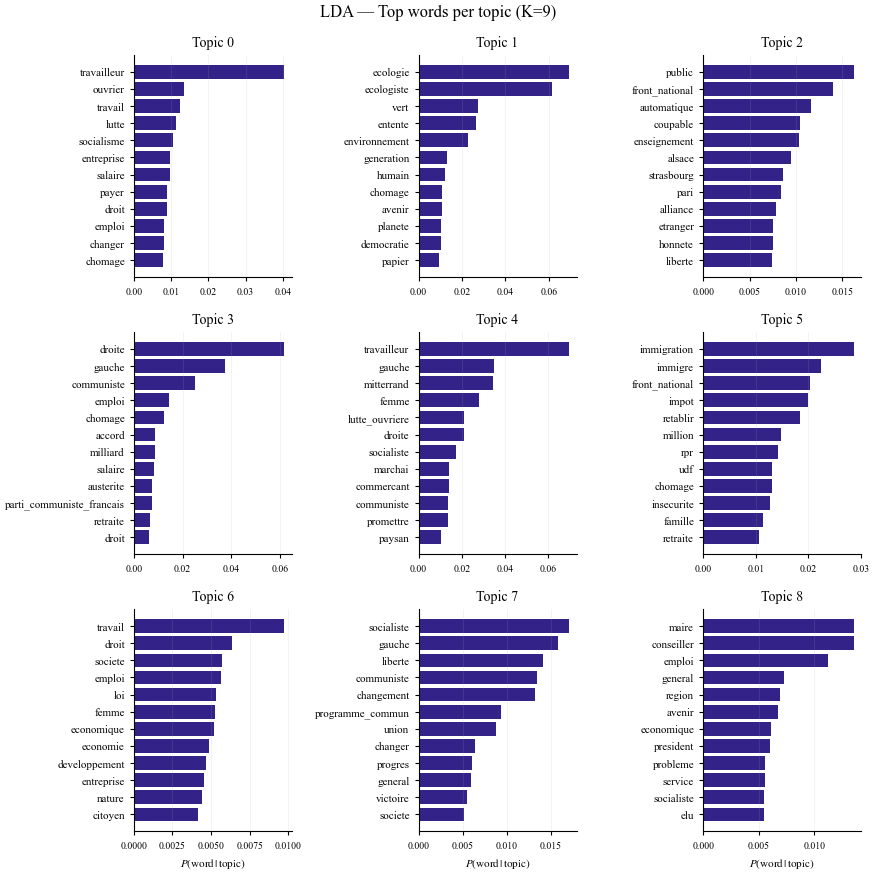

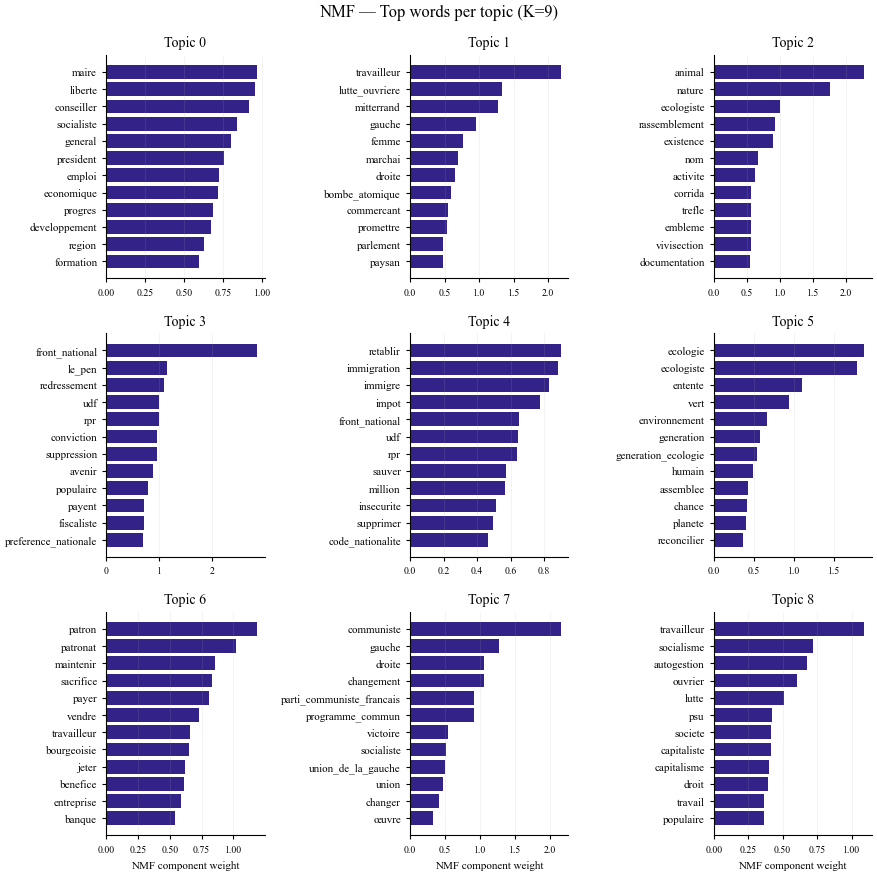

In [45]:
# Side-by-side visualization

plot_topic_words(lda, title=f"LDA — Top words per topic (K={K_FINAL})", n_cols=3, n_words=12)
plt.savefig("charts/07a_lda_topics.png", dpi=200, bbox_inches="tight")
plot_topic_words(nmf, title=f"NMF — Top words per topic (K={K_FINAL})", n_cols=3, n_words=12)
plt.savefig("charts/07a_nmf_topics.png", dpi=200, bbox_inches="tight")
plt.show()

### Interpreting and labelling topics

In [46]:
# Inspect & label LDA topics 

# Prints a fill-in template — you write the labels by reading top words + docs
print("\nLDA topic labeling template:")
_ = make_label_template(lda, n_words=12, save_path="data/processed/lda_labels_template.txt")

print("\nNMF topic labeling template:")
_ = make_label_template(nmf, n_words=12, save_path="data/processed/nmf_labels_template.txt")


LDA topic labeling template:
Topic  0 [travailleur, ouvrier, travail, lutte, socialisme, entreprise, salaire, payer, droit, emploi, changer, chomage] -> __________
Topic  1 [ecologie, ecologiste, vert, entente, environnement, generation, humain, chomage, avenir, planete, democratie, papier] -> __________
Topic  2 [public, front_national, automatique, coupable, enseignement, alsace, strasbourg, pari, alliance, etranger, honnete, liberte] -> __________
Topic  3 [droite, gauche, communiste, emploi, chomage, accord, milliard, salaire, austerite, parti_communiste_francais, retraite, droit] -> __________
Topic  4 [travailleur, gauche, mitterrand, femme, lutte_ouvriere, droite, socialiste, marchai, commercant, communiste, promettre, paysan] -> __________
Topic  5 [immigration, immigre, front_national, impot, retablir, million, rpr, udf, chomage, insecurite, famille, retraite] -> __________
Topic  6 [travail, droit, societe, emploi, loi, femme, economique, economie, developpement, entreprise,

In [47]:
_ = find_representative_documents(lda, df_clean, n_docs=3, n_chars=400, start_char=500)

Topic 0  (top 3 representative documents)

  [1] doc index = 8729, topic weight = 0.997
      year              : 1973
      titulaire-soutien : Ligue communiste
      preview: la banqueroute du régime sont à présent connues de tous : trafic d'influences, pots de vin, spéculation immobilière, tout y est ! En revanche, pour les travailleurs, c'est toujours le chômage, les salaires inférieurs à 1000 francs, l'insécurité ou la misère pour les vieux, les cadences, les brimades, en particulier contre les jeunes et les travailleurs immigrés. A bout de souffle et d'imagination,...

  [2] doc index = 9739, topic weight = 0.997
      year              : 1973
      titulaire-soutien : Ligue communiste
      preview:  la banqueroute du régime sont à présent connues de tous : trafic d'influences, pots de vin, spéculation immobilière, tout y est ! En revanche, pour les travailleurs, c'est toujours le chômage, les salaires inférieurs à 1000 francs, l'insécurité ou la misère pour les vieux, les caden

In [48]:
_ = find_representative_documents(nmf, df_clean, n_docs=3, n_chars=400, start_char=500)

Topic 0  (top 3 representative documents)

  [1] doc index = 17056, topic weight = 1.000
      year              : 1978
      titulaire-soutien : Comité d'action gaulliste
      preview:  pu occuper, les responsabilités qui sont les miennes au sein de la municipalité m'ont procuré la sympathie d'un grand nombre d'entre vous. Vous m'avez élu au Conseil municipal pour la 2e fois en 1977. Chaque fois le Maire m'a confié une charge dans un arrondissement désigné. Chacun de vous connait la sollicitude qui est la mienne pour les personnes âgées et les handicapés en particulier comme aux...

  [2] doc index = 16208, topic weight = 1.000
      year              : 1978
      titulaire-soutien : Parti républicain;Centre des démocrates sociaux
      preview: ançais se sont dans l'ensemble amé- liorées, et que notre économie résiste, malgré les assauts provoqués par la crise mondiale. Faire le bon choix pour la France, comme le Président de la Répu- blique nous le demande, c'est d'abord lui donner

### Labeling difficulties and the choice of NMF for downstream analysis

Topic labeling is intrinsically a **subjective and post-hoc step**: topic
models return distributions over the vocabulary, not semantic categories,
and the analyst has to read the top words of each topic and infer a label
that captures their common thread. This exercise is straightforward when
a topic concentrates on a coherent semantic field, but becomes
problematic when the top words mix several registers or when the topic
absorbs corpus-wide noise (mentions of candidates, generic political
vocabulary, residual stopwords).

In our case, **LDA at K = 9 produces several topics that resist clean
labeling**. Topic 2 mixes school-related vocabulary (*enseignement*,
*public*), regional anchors (*Alsace*, *Strasbourg*) and far-right
references (*front_national*) without an obvious unifying theme. Topic 3
combines opposition rhetoric (*droite*, *gauche*, *communiste*) with
economic-crisis vocabulary (*chômage*, *austérité*, *milliard*), making it
ambiguous whether it captures a left-wing critique of austerity or a
right-wing campaign on unemployment. Topic 4 collapses candidate names
(*Mitterrand*, *Marchais*) with corporatist categories (*commerçant*,
*paysan*) into what is essentially a presidential-campaign noise topic.
Topic 6 mixes work, rights and economic development in a vague
republican-reformist register. These ambiguities reflect LDA's tendency
to produce **smoother, more overlapping distributions**, which is useful
for capturing latent gradients but problematic for the categorical,
party-by-topic analysis we want to conduct.

By contrast, **NMF at K = 9 yields topics that are markedly easier to
label**. Each of the nine components corresponds to a recognizable
political register — local action and economic development, far-left
revolutionary anti-reformism, animal welfare, national preference,
immigration and insecurity, political ecology, class struggle against the
patronat, Union de la gauche, and self-management / anti-capitalism — with
a clear semantic core and minimal cross-contamination. Only one topic
(Topic 1) functions as a residual "presidential noise" component, which
is straightforward to identify and filter out. This sharper structure is
a direct consequence of NMF's sparsity-inducing non-negativity constraint
combined with TF-IDF weighting, which together push each word toward a
single dominant topic.

Given that the downstream analyses — **topic distribution per party, per
political family, per profession, and per occupational category** — rely
on the assumption that each topic corresponds to an interpretable and
politically meaningful theme, we retain **the NMF topics at K = 9 as the
reference topic set**. LDA results are kept as a robustness check but are
not used as the primary basis for the substantive interpretation, since
their labeling is too uncertain for the categorical comparisons that
follow.

In [49]:
# Manual labels based on the above templates and representative docs

LDA_LABELS = {
    0: "Lutte des classes & salaire",                   
    1: "Ecologie politique",                     
    2: "Ancrage régional & école libre",                               
    3: "Chômage & austérité ",             
    4: "Anti-réformisme révolutionnaire",                     
    5: "Immigration & insécurité",
    6: "Société, travail & économie",
    7: "Union gauche & Programme commun",           
    8: "Action locale",                       
}
NMF_LABELS = {
    0: "Action locale & dév. éco.",                            
    1: "Anti-réformisme révol.",                                     
    2: "Cause animale & nature",                                      
    3: "Préférence nationale & baisse impôts",
    4: "Insécurité et immigration",
    5: "Écologie politique",
    6: "Lutte des classes",
    7: "Union gauche & Programme commun",
    8: "Autogestion & anticapitalisme",
}
lda_labels = apply_labels(LDA_LABELS, n_topics=lda.n_topics)
nmf_labels = apply_labels(NMF_LABELS, n_topics=nmf.n_topics)

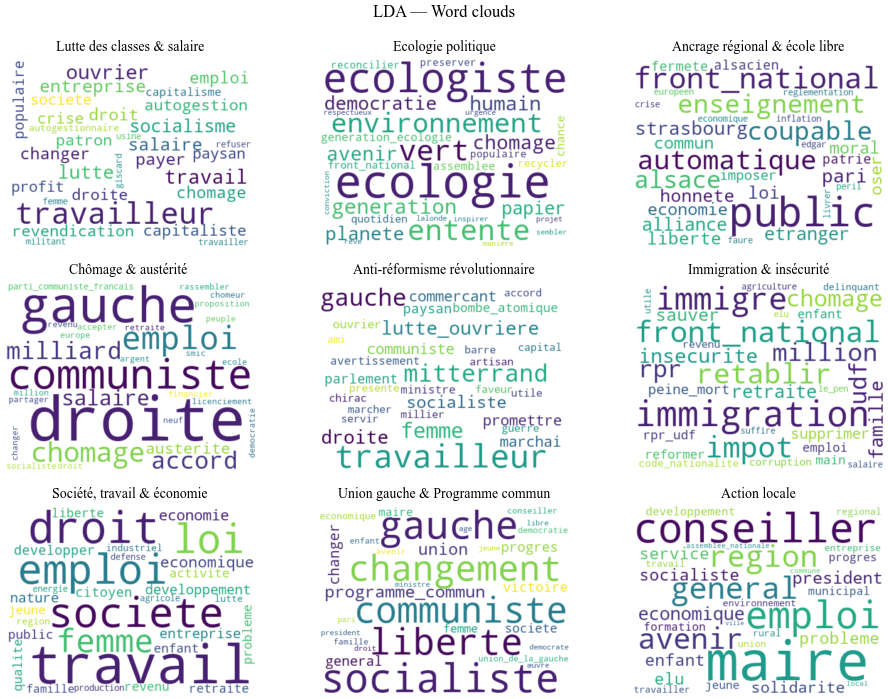

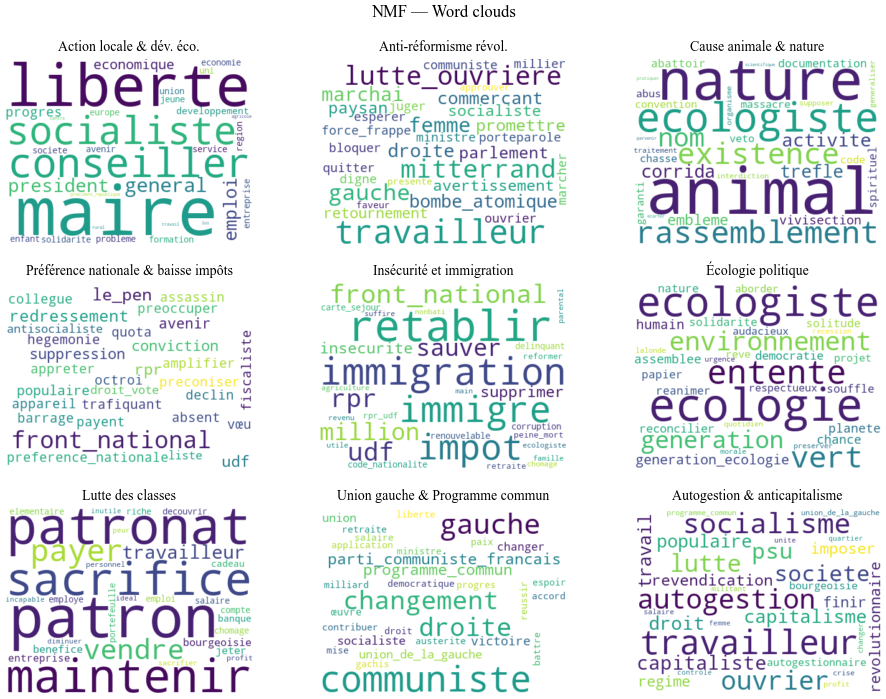

In [50]:
# --- Topic visualisations ---
plot_topic_wordclouds(lda, topic_labels=lda_labels, title="LDA — Word clouds", n_cols=3)
plt.savefig("charts/07b_lda_wordclouds.png", dpi=200, bbox_inches="tight")
plot_topic_wordclouds(nmf, topic_labels=nmf_labels, title="NMF — Word clouds", n_cols=3)
plt.savefig("charts/07b_nmf_wordclouds.png", dpi=200, bbox_inches="tight")
plt.show() 

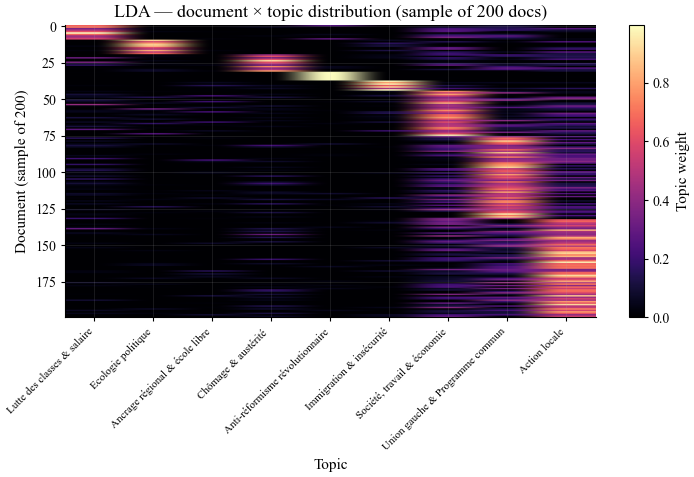

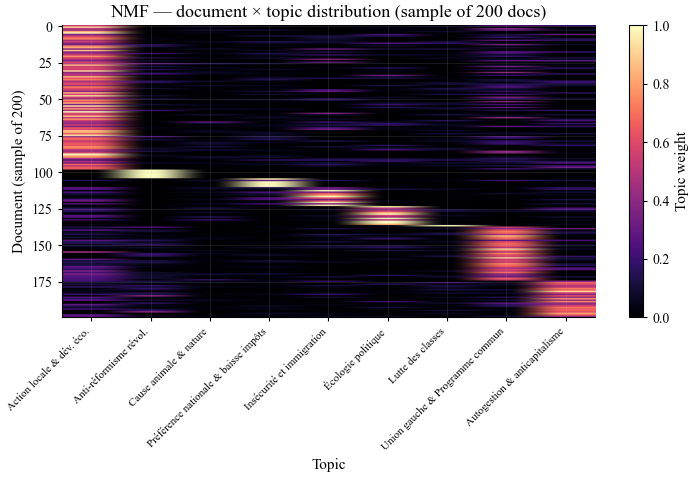

In [51]:
plot_doc_topic_heatmap(lda.get_doc_topic_matrix(), topic_labels=lda_labels,
                       title="LDA — document × topic distribution (sample of 200 docs)")
plt.savefig("charts/07c_lda_doc_topics_heatmap.png", dpi=200, bbox_inches="tight")
plot_doc_topic_heatmap(nmf.get_doc_topic_matrix(), topic_labels=nmf_labels,
                       title="NMF — document × topic distribution (sample of 200 docs)")
plt.savefig("charts/07c_nmf_doc_topics_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

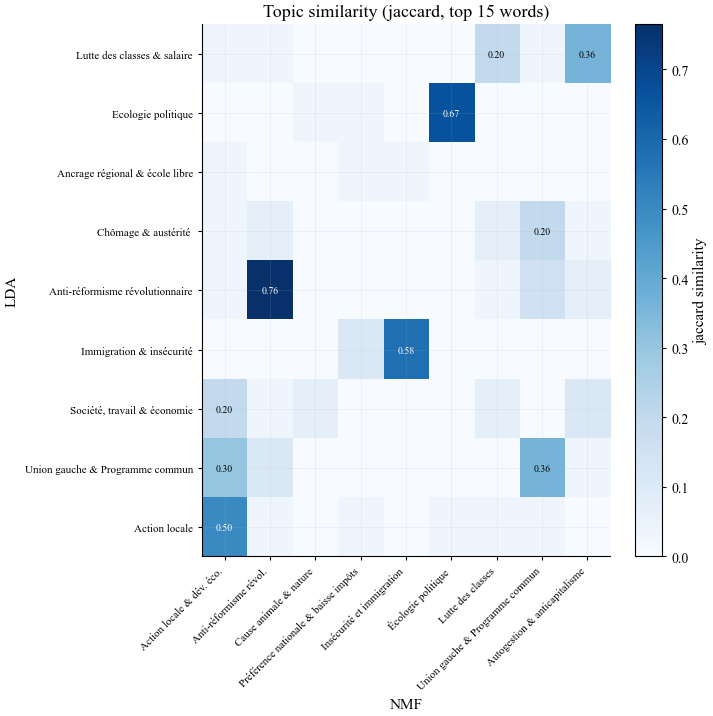

In [52]:
plot_topic_alignment_matrix(lda.get_top_words(15), nmf.get_top_words(15),
                            labels_a=lda_labels, labels_b=nmf_labels)
plt.savefig("charts/07d_lda_nmf_alignment.png", dpi=200, bbox_inches="tight")
plt.show() 

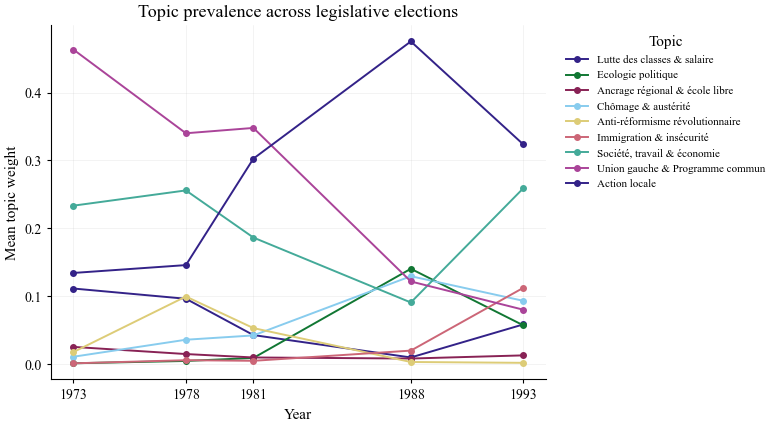

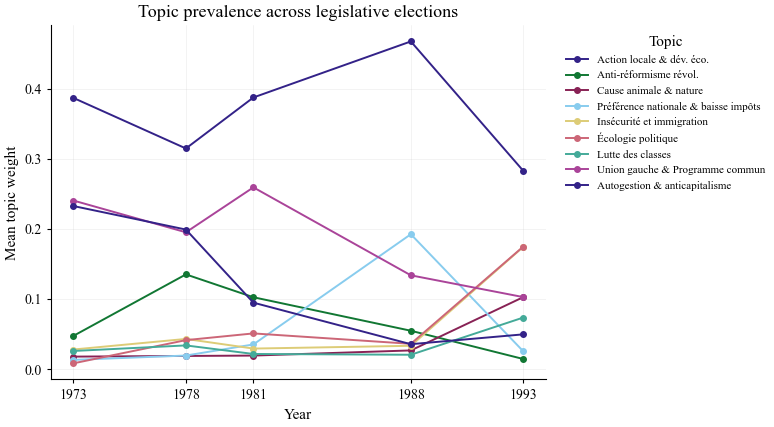

In [53]:
plot_topic_prevalence_over_time(lda.get_doc_topic_matrix(),
                                df_clean["year"], topic_labels=lda_labels)
plt.savefig("charts/07e_lda_topic_prevalence_over_time.png", dpi=200, bbox_inches="tight")
plot_topic_prevalence_over_time(nmf.get_doc_topic_matrix(),
                                df_clean["year"], topic_labels=nmf_labels)
plt.savefig("charts/07e_nmf_topic_prevalence_over_time.png", dpi=200, bbox_inches="tight")

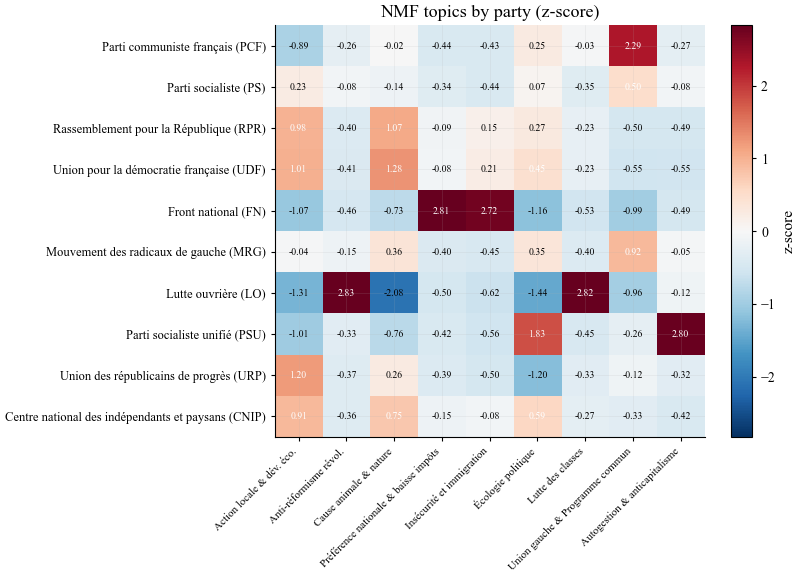

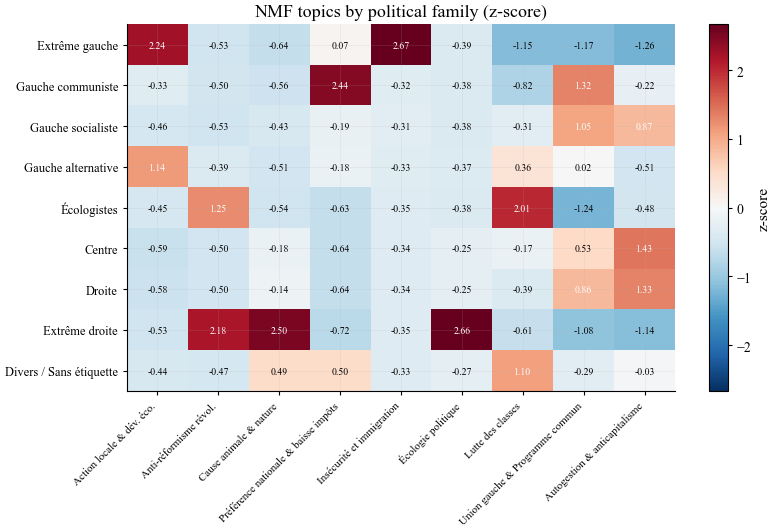

In [54]:
# Parties:
party_dist, party_counts = topics_by_party(
    nmf.get_doc_topic_matrix(), party_dummies,
    top_n_parties=10, party_counts=diagnostic["party_counts"],
    topic_labels=nmf_labels,
)
plot_topic_group_heatmap(party_dist, normalize="z",
                         title="NMF topics by party (z-score)")
plt.savefig("charts/07f_nmf_topic_by_party.png", dpi=200, bbox_inches="tight")

# Families:
fam_dist, fam_counts = topics_by_family(
    lda.get_doc_topic_matrix(), family_dummies, topic_labels=nmf_labels,
)
plot_topic_group_heatmap(fam_dist, normalize="z",
                         title="NMF topics by political family (z-score)")
plt.savefig("charts/07f_nmf_topic_by_polt_fam.png", dpi=200, bbox_inches="tight")
plt.show()

[skip] 'Non mentionné' has only 4 documents (< min_docs=10)


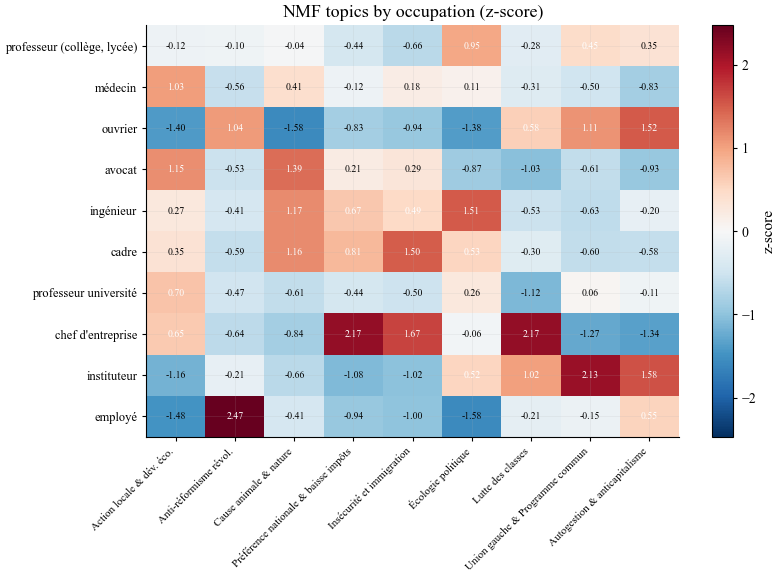

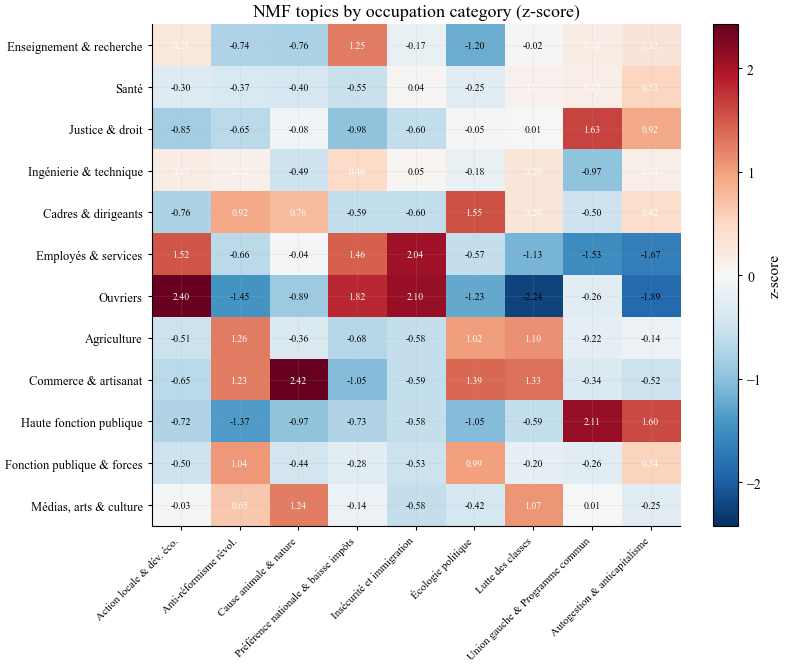

In [80]:
# Occupations
occ_dist, occ_counts = topics_by_party(
    nmf.get_doc_topic_matrix(), occ_dummies,
    top_n_parties=10, party_counts=diag["occupation_counts"],
    topic_labels=nmf_labels,
)
plot_topic_group_heatmap(occ_dist, normalize="z",
                         title="NMF topics by occupation (z-score)")
plt.savefig("charts/07g_nmf_topic_by_occupation.png", dpi=200, bbox_inches="tight")


# Categories of jobs
cat_dist, cat_counts = topics_by_family(
    lda.get_doc_topic_matrix(), cat_dummies, topic_labels=nmf_labels,
)
plot_topic_group_heatmap(cat_dist, normalize="z",
                         title="NMF topics by occupation category (z-score)")
plt.savefig("charts/07g_nmf_topic_by_occ_category.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. State-of-the-art: BERTopic

LDA and NMF treat manifestos as bags of words and rely entirely on
co-occurrence statistics. BERTopic (Grootendorst, 2022) replaces the
bag-of-words assumption by Sentence-BERT contextual embeddings, clusters
the embedded documents with HDBSCAN, and re-extracts topic words via a
class-based TF-IDF on the resulting clusters. This is the modern endpoint
of the topic-modelling timeline reproduced in the course slides
(*"History (until BERT)"*, Churchill & Singh 2022) and it has two concrete
advantages on our corpus:

1. **Semantic understanding** — synonyms (*ouvrier* / *travailleur* /
   *salarié*) and paraphrases collapse onto the same topic without us having
   to merge them by hand.
2. **Native temporal evolution** — `topics_over_time` produces the
   year-by-year topic prevalence directly, which is the goal stated in the
   notebook title and which a Dynamic Topic Model would otherwise require
   ~1–3 hours to fit.

BERTopic operates on **raw text**, not on the lemmatised tokens used for
LDA/NMF: the embedding model handles morphology natively, and removing it
upfront would actually hurt the embeddings.

In [56]:
# Compute Sentence-BERT embeddings
# Cached to disk so kernel restarts don't redo the work.

EMBED_MODEL = "paraphrase-multilingual-mpnet-base-v2"  # "paraphrase-multilingual-MiniLM-L12-v2"  # small, fast, French-friendly
CACHE_PATH = "data/processed/bertopic_embeddings_v2.pkl"

if FIRST_RUN:
    t0 = time.time()
    embeddings = compute_embeddings(
        df_clean["text"].tolist(),
        model_name = EMBED_MODEL,
        cache_path = CACHE_PATH,
        batch_size = 32,
    )
    print(f"Embeddings: {embeddings.shape}  (elapsed: {(time.time()-t0)/60:.1f} min)")
else : 
    with open(CACHE_PATH, "rb") as f:
            embeddings = pickle.load(f)
    print(f"Loaded cached embeddings: {embeddings.shape}")

    

Loaded cached embeddings: (20852, 768)


In [57]:
m = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
real_lengths = [len(m.tokenizer.encode(t)) for t in df_clean["text"]]
print(f"Médiane tokens BERT (texte brut) : {np.median(real_lengths):.0f}")
print(f"P90 : {np.percentile(real_lengths, 90):.0f}")
print(f"P99 : {np.percentile(real_lengths, 99):.0f}")
print(f"% docs > 128 : {(np.array(real_lengths) > 128).mean():.1%}")
print(f"% docs > 512 : {(np.array(real_lengths) > 512).mean():.1%}")
print(f"% docs > 1024 : {(np.array(real_lengths) > 1024).mean():.1%}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (912 > 128). Running this sequence through the model will result in indexing errors


Médiane tokens BERT (texte brut) : 1089
P90 : 1955
P99 : 2981
% docs > 128 : 100.0%
% docs > 512 : 91.6%
% docs > 1024 : 53.9%


### 3.1. Re-embedding with extended context window

The diagnostic of the WordPiece tokenisation of the corpus above revealed a critical
mismatch between the documents and the embedding model used in my first
BERTopic run. The median manifesto length is **1089 BERT tokens** (P90 = 1955,
P99 = 2981), while `paraphrase-multilingual-mpnet-base-v2` ships with a default
`max_seq_length` of **128 tokens** — meaning **100% of our manifestos were
silently truncated** by the tokenizer, with on average only ~12% of each
document's content actually reaching the transformer. The remainder was
discarded before encoding (no sliding window: SentenceTransformer applies
hard truncation by design).

This explains the pathologies observed in the first BERTopic run: a single
catch-all topic absorbing ~50% of the corpus, and several near-duplicate
clusters for templated national campaigns (Lutte Ouvrière 1993, Front National
1988, Nouveaux écologistes 1993). The clusters were not reflecting programmatic
content — they were reflecting **administrative headers** (candidate names,
constituency labels, "Sciences Po / fonds CEVIPOF" boilerplate, OCR artefacts
in the first ~100 words), which is the only signal the model could see.

We therefore re-embed the entire corpus with **`BAAI/bge-m3`** configured at
`max_seq_length = 2048`. bge-m3 is a state-of-the-art multilingual long-context
embedding model (2024) that supports up to 8192 tokens architecturally, and
2048 covers ~95% of our manifestos in their entirety. The 21k embeddings were
computed on a Colab T4 GPU (≈110 minutes) and cached locally; downstream
BERTopic fitting reuses them as pre-computed vectors with no further encoding
cost.

In [58]:
EMBED_MODEL = "BAAI/bge-m3"   # juste pour log/rapport, pas réutilisé pour le chargement
CACHE_PATH = "data/processed/bge_m3_2048_embeddings.pkl"

with open(CACHE_PATH, "rb") as f:
    embeddings = pickle.load(f)

# Sanity checks — important
print(f"Loaded embeddings: shape={embeddings.shape}, dtype={embeddings.dtype}")
assert embeddings.shape[0] == len(df_clean), (
    f"Mismatch: {embeddings.shape[0]} embeddings vs {len(df_clean)} docs in df_clean. "
    f"Vérifie que df_clean n'a pas été refiltré depuis l'export."
)
assert embeddings.shape[1] == 1024, f"Expected 1024-dim (bge-m3), got {embeddings.shape[1]}"

# bge-m3 retourne des embeddings normalisés (norm=1), à vérifier
norms = np.linalg.norm(embeddings, axis=1)
print(f"Norms: mean={norms.mean():.4f}, min={norms.min():.4f}, max={norms.max():.4f}")
print("(should be ~1.0 if normalize_embeddings=True was used)")

Loaded embeddings: shape=(20852, 1024), dtype=float32
Norms: mean=1.0000, min=1.0000, max=1.0000
(should be ~1.0 if normalize_embeddings=True was used)


In [59]:
bertopic_model = BERTopicModel(
    n_topics         = "auto",
    embedding_model  = EMBED_MODEL,
    min_topic_size   = 50,
    min_df           = NO_BELOW,
    max_df           = NO_ABOVE,
    max_features     = KEEP_N,
    extra_stopwords  = list(EXTRA_STOPWORDS),
    n_gram_range     = (1, 2),
    verbose          = True,
).fit(
    df_clean["text"].tolist(),
    embeddings=embeddings,
    lemmatized_documents=[" ".join(toks) for toks in tokens],  
)

print(bertopic_model)
print(f"\nKept topics: {bertopic_model.n_topics}")
print(f"Outlier docs (-1): {bertopic_model.n_outliers()} "
      f"({bertopic_model.n_outliers() / len(df_clean):.1%})")

# Topic info table — useful summary
bertopic_info = bertopic_model.get_topic_info()
print(bertopic_info.head(15))
bertopic_info.to_csv("data/processed/bertopic_info.csv", index=False)

BERTopic vocabulary after doc-level filtering: 10000 terms


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

2026-05-03 14:09:48,330 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 14:10:19,345 - BERTopic - Dimensionality - Completed ✓
2026-05-03 14:10:19,349 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 14:10:23,097 - BERTopic - Cluster - Completed ✓
2026-05-03 14:10:23,109 - BERTopic - Representation - Fine-tuning topics using representation models.
/Users/emmaleguay/miniforge3/envs/archelec/lib/python3.11/site-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-05-03 14:10:31,762 - BERTopic - Representation - Completed ✓


BERTopicModel(n_topics=68, n_outliers=9192, fitted=True)

Kept topics: 68
Outlier docs (-1): 9192 (44.1%)
    Topic  Count                                               Name  \
0       0    878           0_liberte_progres_republicain_economique   
1       1    658  1_socialiste_gauche_programme_commun_union_de_...   
2       2    652  2_uni_majorite_presidentielle_majorite_preside...   
3       3    581   3_ecologiste_ecologie_entente ecologiste_entente   
4       4    572               4_immigration_retablir_immigre_impot   
5       5    550  5_front_national_avenir front_national_le_pen_...   
6       6    464                   6_union_conseiller_maire_rpr_udf   
7       7    380            7_droite_communiste_neuf_opposer droite   
8       8    293               8_alsace_strasbourg_alsacien_basrhin   
9       9    288  9_reformateur_mouvement reformateur_mouvement_...   
10     10    287   10_droite_rassemblement gauche_gauche_communiste   
11     11    281  11_programme_commun_comm

### 3.2. On the 68 topics and 44% outliers — a feature of HDBSCAN, not a bug

The fitted model returns **68 topics** with **44% of documents labelled as
outliers** (cluster -1). Both numbers are expected behaviour for HDBSCAN with
`n_topics="auto"` and reflect deliberate methodological choices:

- **No imposed dimensionality reduction.** Forcing `n_topics=k` at fit time
  triggers BERTopic's iterative merging procedure during the clustering step,
  which on our corpus previously cascaded smaller clusters into a single
  catch-all topic. Letting HDBSCAN find its natural density structure produces
  more semantically coherent micro-clusters (e.g. PSU autogestionnaire,
  Alsace-specific manifestos, réformateurs centristes), which a forced
  reduction would have destroyed.

- **Outliers are not classification errors.** HDBSCAN explicitly refuses to
  assign documents that do not lie in a clear density region, rather than
  forcing them into the nearest cluster (as LDA's soft assignment implicitly
  does). On a heterogeneous political corpus with many idiosyncratic
  manifestos, a 30–50% outlier rate is standard and is more honest than
  spurious cluster membership.

We address both issues **post-hoc**, in two complementary steps:

1. **Outlier reassignment via embedding similarity.** We use BERTopic's
   `reduce_outliers(strategy="embeddings")` to reassign each -1 document to
   the topic whose centroid is closest in **bge-m3 embedding space**. This
   leverages the same semantic representation that drove the original
   clustering, rather than the c-TF-IDF representation, and is therefore
   consistent with HDBSCAN's own notion of similarity.

2. **Hierarchical topic reduction to k=25.** We then merge topic pairs by
   c-TF-IDF cosine similarity until reaching a target of 25 topics, mirroring
   the granularity of LDA/NMF (k=15) plus a margin for the additional fine
   structure that BERTopic legitimately recovers. The reduction follows a
   single-linkage hierarchy that we visualise as a dendrogram, allowing us
   to inspect *which* topics are merged at each step and confirm that
   merges are semantically warranted (e.g. the three Lutte Ouvrière 1993
   sub-clusters fuse early, as expected from their templated content).

This two-step procedure preserves the semantic granularity that bge-m3 makes
visible, while producing a topic count that is interpretable and directly
comparable to the bag-of-words baselines.

In [60]:
# Actual assignments
new_topics = bertopic_model.model.reduce_outliers(
    documents = df_clean["text"].tolist(),
    topics    = bertopic_model._topic_assignments.tolist(),
    strategy  = "embeddings",
    embeddings = embeddings,
    threshold = 0.0,   
)

# Update of the model
bertopic_model.model.update_topics(
    df_clean["text"].tolist(),
    topics = new_topics,
    vectorizer_model = bertopic_model.model.vectorizer_model,
)

# Refresh of the information
bertopic_model._topic_assignments = np.asarray(new_topics)
info = bertopic_model.model.get_topic_info()
bertopic_model._kept_topic_ids = [t for t in info["Topic"].tolist() if t != -1]
bertopic_model.n_topics = len(bertopic_model._kept_topic_ids)

print(f"After reduce_outliers: {bertopic_model.n_topics} topics, "
      f"{(np.asarray(new_topics) == -1).sum()} outliers")

2026-05-03 14:10:40,654 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


After reduce_outliers: 68 topics, 0 outliers


/Users/emmaleguay/miniforge3/envs/archelec/lib/python3.11/site-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


In [61]:
# Visualizing the potential topics hierarchical clustering
# that will be used in next cell to reduce the number of topics from 68 to 

hierarchical_topics = bertopic_model.model.hierarchical_topics(
    df_clean["text"].tolist()
)

fig = bertopic_model.model.visualize_hierarchy(
    hierarchical_topics = hierarchical_topics
)
fig.show()

100%|██████████| 67/67 [00:00<00:00, 375.86it/s]


In [62]:
# Reducing the number of topics by hierarchical fusion
bertopic_model.model.reduce_topics(
    df_clean["text"].tolist(),
    nr_topics = 25,
)

# Refresh of the information
bertopic_model._topic_assignments = np.asarray(bertopic_model.model.topics_)
info = bertopic_model.model.get_topic_info()
bertopic_model._kept_topic_ids = [t for t in info["Topic"].tolist() if t != -1]
bertopic_model.n_topics = len(bertopic_model._kept_topic_ids)

print(f"After reduce_topics: {bertopic_model.n_topics} topics")
print(bertopic_model.model.get_topic_info().head(30))

2026-05-03 14:10:57,527 - BERTopic - Topic reduction - Reducing number of topics
2026-05-03 14:10:57,544 - BERTopic - Representation - Fine-tuning topics using representation models.
/Users/emmaleguay/miniforge3/envs/archelec/lib/python3.11/site-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-05-03 14:11:06,253 - BERTopic - Representation - Completed ✓
2026-05-03 14:11:06,266 - BERTopic - Topic reduction - Reduced number of topics from 68 to 25


After reduce_topics: 25 topics
    Topic  Count                                               Name  \
0       0  10540                   0_gauche_fonds_communiste_droite   
1       1   1983                     1_union_fonds_maire_conseiller   
2       2   1194                             2_front_rpr_udf_avenir   
3       3   1086                       3_udf_rpr_immigration_sauver   
4       4    912       4_entente_ecologie_autogestion_environnement   
5       5    847    5_gauche_autogestionnaire_changement_mitterrand   
6       6    813        6_bretagne_mitterrand_socialiste_changement   
7       7    489                       7_corse_loi_gaullisme_gaulle   
8       8    442               8_changement_communiste_union_commun   
9       9    415                      9_maire_conseiller_fonds_nord   
10     10    398       10_nature_rassemblement nature_moselle_femme   
11     11    245                  11_ecologie_nature_eau_croissance   
12     12    227                     12_orne_m

I should have done this chart before reducting from 68 to 25 topics, but it also shows that the 25 topics can be regrouped in 4 big macro families

In [63]:
# Top words side-by-side with LDA / NMF
print("=== BERTopic — top words per topic ===")
print(topic_words_dataframe(bertopic_model, n_words=12))

# Representative manifestos — read 2 docs per topic to validate the labels
_ = find_representative_documents(
    bertopic_model, df_clean, n_docs=2, n_chars=600,
    extra_cols=("year", "titulaire-soutien"),
)

=== BERTopic — top words per topic ===
      Topic 0        Topic 1             Topic 2       Topic 3        Topic 4  \
0      gauche          union               front           udf        entente   
1       fonds          fonds                 rpr           rpr       ecologie   
2  communiste          maire                 udf   immigration    autogestion   
3      droite     conseiller              avenir        sauver  environnement   
4       union            udf         suppression         carte     generation   
5  socialiste            rpr           populaire         front            psu   
6      commun         avenir             barrage    corruption     socialisme   
7       maire        conseil       rassemblement        gauche         projet   
8        bien         centre          fiscaliste         peine         chance   
9     travail  rassemblement  attitude exclusion  renouvelable        aujourd   

                  Topic 5               Topic 6       Topic 7       T

In [64]:
BERTOPIC_LABELS = {
    0:  "Mandat sortant & confirmation de confiance",
    1:  "Alternance & rejet de la politique menée",
    2:  "Redressement national & avenir d'un mouvement enraciné",
    3:  "Constat de crise — chômage, insécurité, immigration",
    4:  "Écologie politique & démocratie participative",
    5:  "Construire la gauche autogestionnaire contre la droite",
    6:  "Espoir du changement & rupture mitterrandienne",
    7:  "Connaissance des lois naturelles & gouvernement spirituel",
    8:  "Union et changement — appel au vote utile à gauche",
    9:  "Député présent, attentif et au-delà des clivages",
    10: "Témoignage militant — voix des travailleuses & travailleurs",
    11: "Critique de la société industrielle & alternative écologiste",
    12: "Volonté d'alternance & rénovation territoriale",
    13: "Idéal socialiste & justice sociale",
    14: "Partage du travail & alternative féministe-autogestionnaire",
    15: "Spécificités ultramarines & développement insulaire",
    16: "Refus du sectarisme partisan & morale publique",
    17: "Sécurité, apprentissage & préférence nationale",
    18: "Pouvoir aux travailleurs & rupture révolutionnaire",
    19: "Dénonciation du régime & corruption du pouvoir",
    20: "Défense de la nature, des animaux & cause universelle",
    21: "Souveraineté ouvrière contre la mondialisation",
    22: "Union de la gauche & dynamique de premier tour",
    23: "Refus de Maastricht & défense du monde rural",
    24: "Valeurs traditionnelles & droite assumée",
}
bertopic_labels = apply_labels(BERTOPIC_LABELS, n_topics=bertopic_model.n_topics)

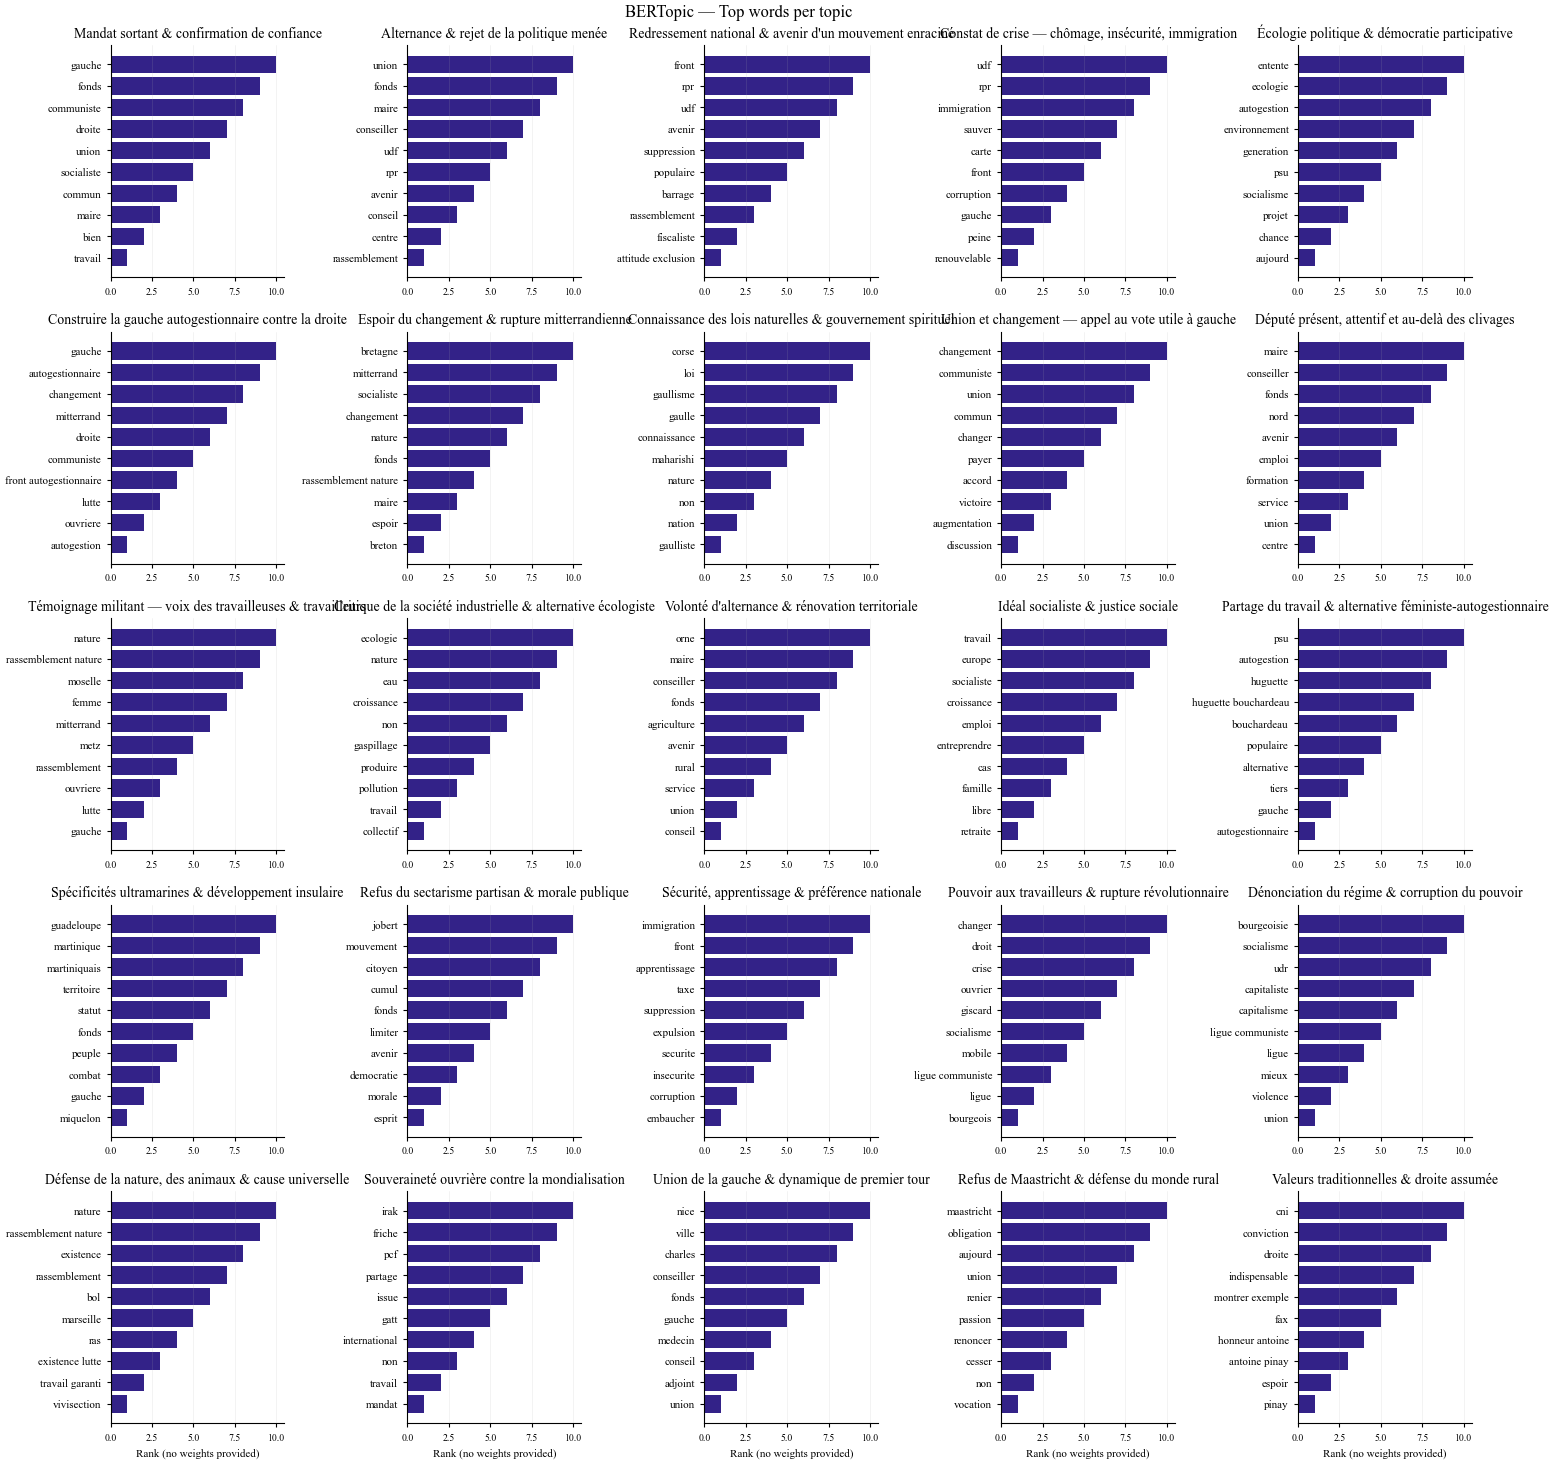

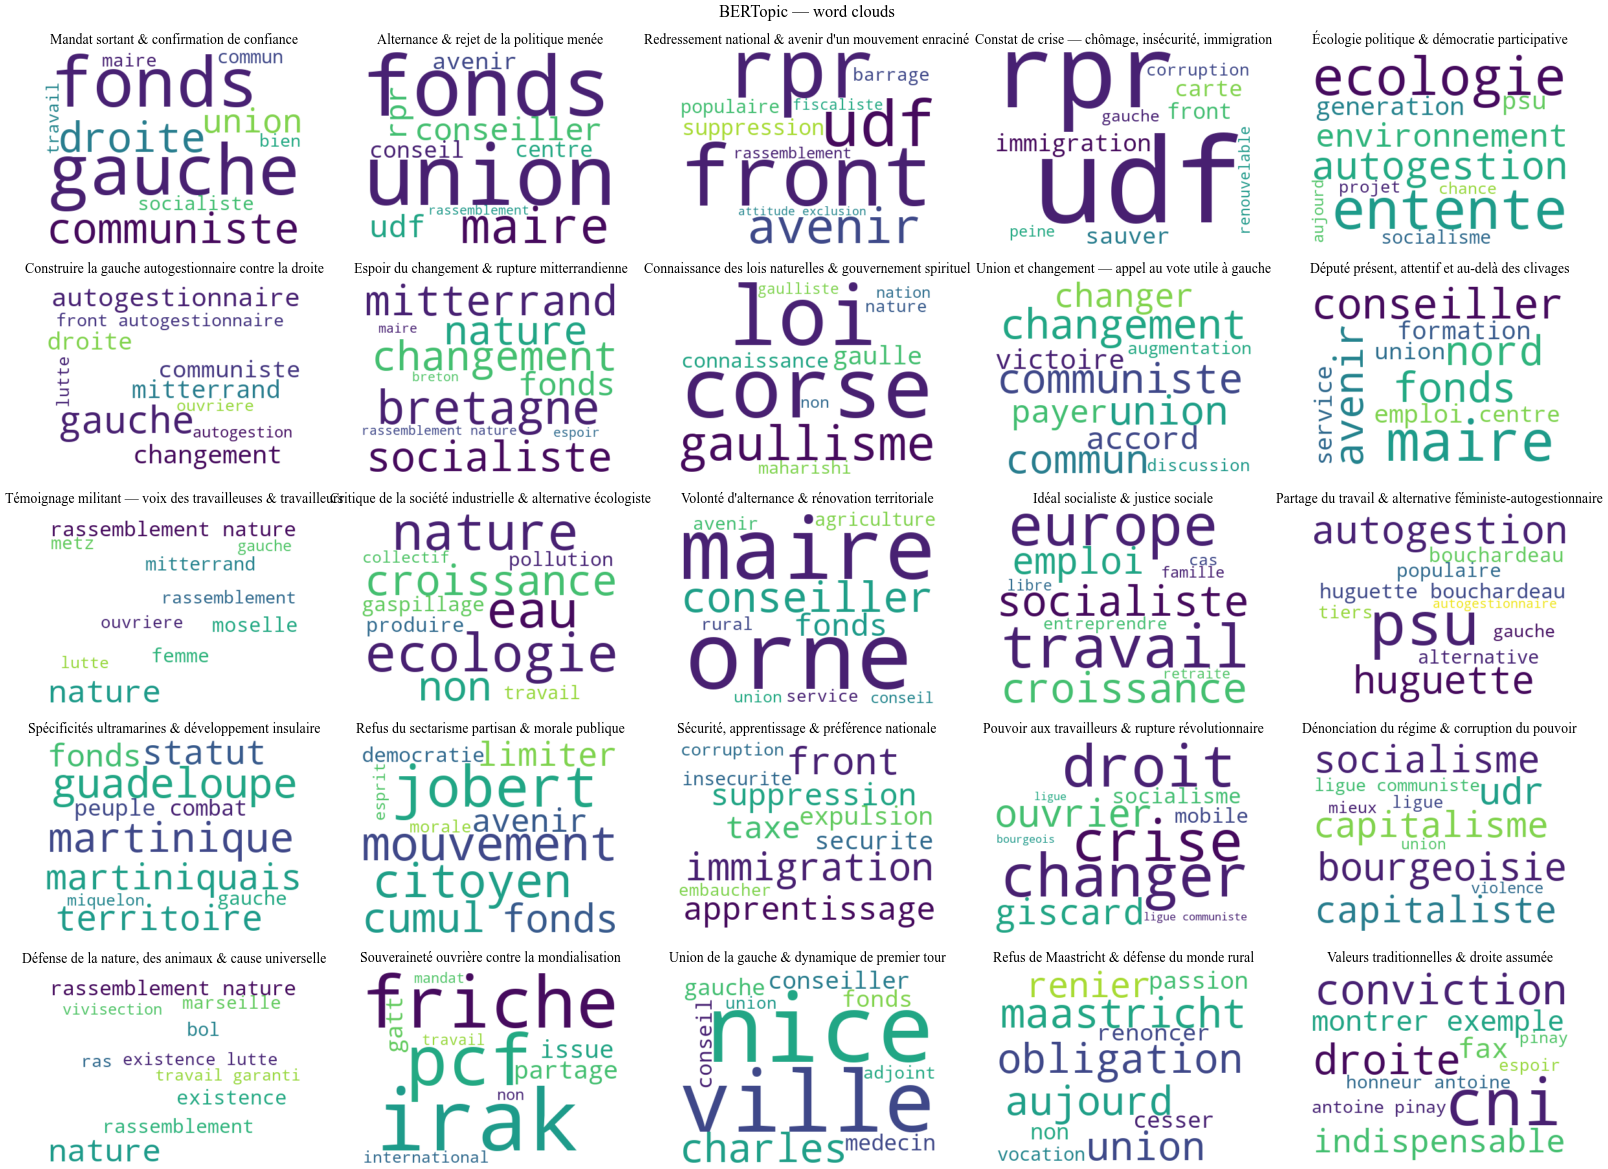

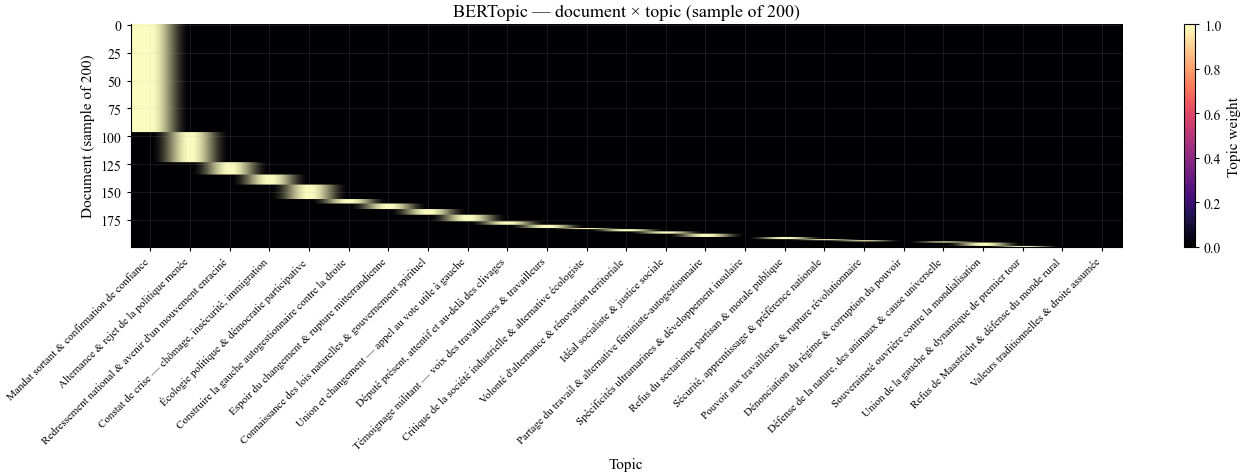

In [65]:
# Bar chart of top words
plot_topic_words(
    bertopic_model.get_top_words(12),
    "BERTopic — Top words per topic",
    topic_labels=bertopic_labels,
)
plt.savefig("charts/08a_bertopic_topics.png", dpi=200, bbox_inches="tight")
plt.show()

# Word clouds — note these use c-TF-IDF weights, sharper than rank-based
plot_topic_wordclouds(
    bertopic_model, n_words=30,
    topic_labels=bertopic_labels,
    title="BERTopic — word clouds",
)
plt.savefig("charts/08b_bertopic_wordclouds.png", dpi=200, bbox_inches="tight")
plt.show()

# Doc-topic heatmap — by construction one-hot, so blocks will be very sharp
plot_doc_topic_heatmap(
    bertopic_model.get_doc_topic_matrix(),
    sample_size=200,
    topic_labels=bertopic_labels,
    title="BERTopic — document × topic (sample of 200)",
)
plt.savefig("charts/08c_bertopic_doc_x_topics.png", dpi=200, bbox_inches="tight")
plt.show()

This means that BERTopic identifies a big cluster, and very small "niche" topics : this is linked to its very different inner functionning than LDA and NMF.

           model  n_topics  coherence_cv  diversity   perplexity  \
0  LDATopicModel         9      0.575866   0.693333  1639.917609   
1  NMFTopicModel         9      0.737490   0.875556          NaN   
2  BERTopicModel        25      0.484800   0.652000          NaN   

   reconstruction_err  
0                 NaN  
1          130.708668  
2                 NaN  

LDA → closest BERTopic topic:
   topic_a  best_match_b  similarity  n_shared  \
0        0            18    0.250000         5   
1        1             4    0.250000         5   
2        2             7    0.041667         1   
3        3             0    0.136364         3   
4        4             0    0.190476         4   
5        5             3    0.190476         4   
6        6             7    0.086957         2   
7        7             0    0.250000         5   
8        8             9    0.250000         5   

                                        shared_words  
0         changer, crise, droit, ouvrier, so

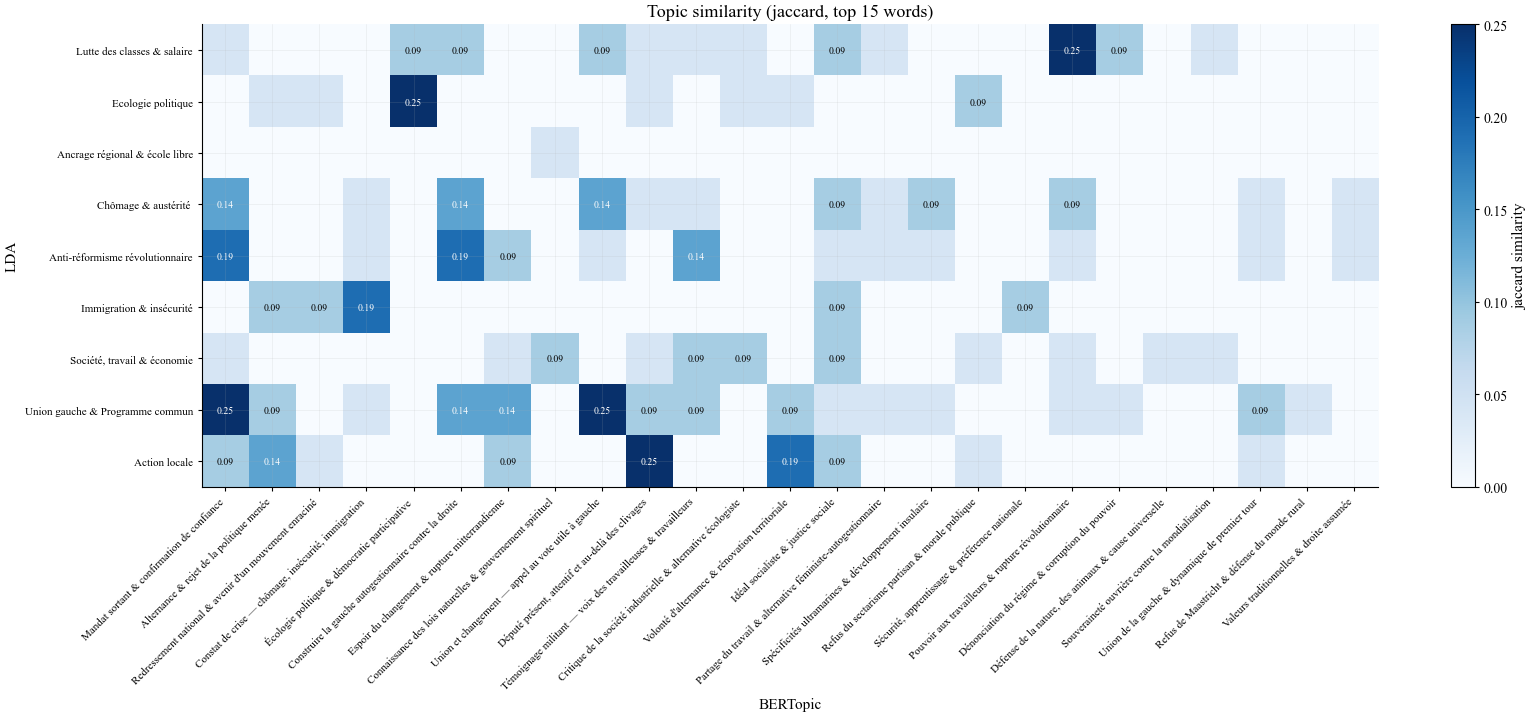

In [66]:
# Comparison

all_models = pd.DataFrame([
    summarize_model(lda, tokens),
    summarize_model(nmf, tokens),
    summarize_model(bertopic_model, tokens),
])
print(all_models)
all_models.to_csv("data/processed/model_comparison_all.csv", index=False)

# Topic alignment LDA <-> BERTopic
sim_lda_bert, matches_lda_bert = align_topics(
    lda.get_top_words(15),
    bertopic_model.get_top_words(15),
    n_words=15, method="jaccard",
)
print("\nLDA → closest BERTopic topic:")
print(matches_lda_bert)

# Heatmap
plot_topic_alignment_matrix(
    lda.get_top_words(15), bertopic_model.get_top_words(15),
    name_a="LDA", name_b="BERTopic",
    labels_a=lda_labels, labels_b=bertopic_labels,
)
plt.savefig("charts/08_lda_bertopic_alignment.png", dpi=200, bbox_inches="tight")
plt.show()


LDA → closest BERTopic topic:
   topic_a  best_match_b  similarity  n_shared  \
0        0             9    0.190476         4   
1        1             0    0.136364         3   
2        2            20    0.190476         4   
3        3             2    0.315789         6   
4        4             3    0.250000         5   
5        5             4    0.250000         5   
6        6             8    0.041667         1   
7        7             0    0.250000         5   
8        8             4    0.136364         3   

                                        shared_words  
0               conseiller, emploi, formation, maire  
1                         droite, gauche, socialiste  
2      existence, nature, rassemblement, vivisection  
3  avenir, fiscaliste, populaire, rpr, suppressio...  
4        immigration, renouvelable, rpr, sauver, udf  
5  chance, ecologie, entente, environnement, gene...  
6                                              payer  
7      communiste, droite, g

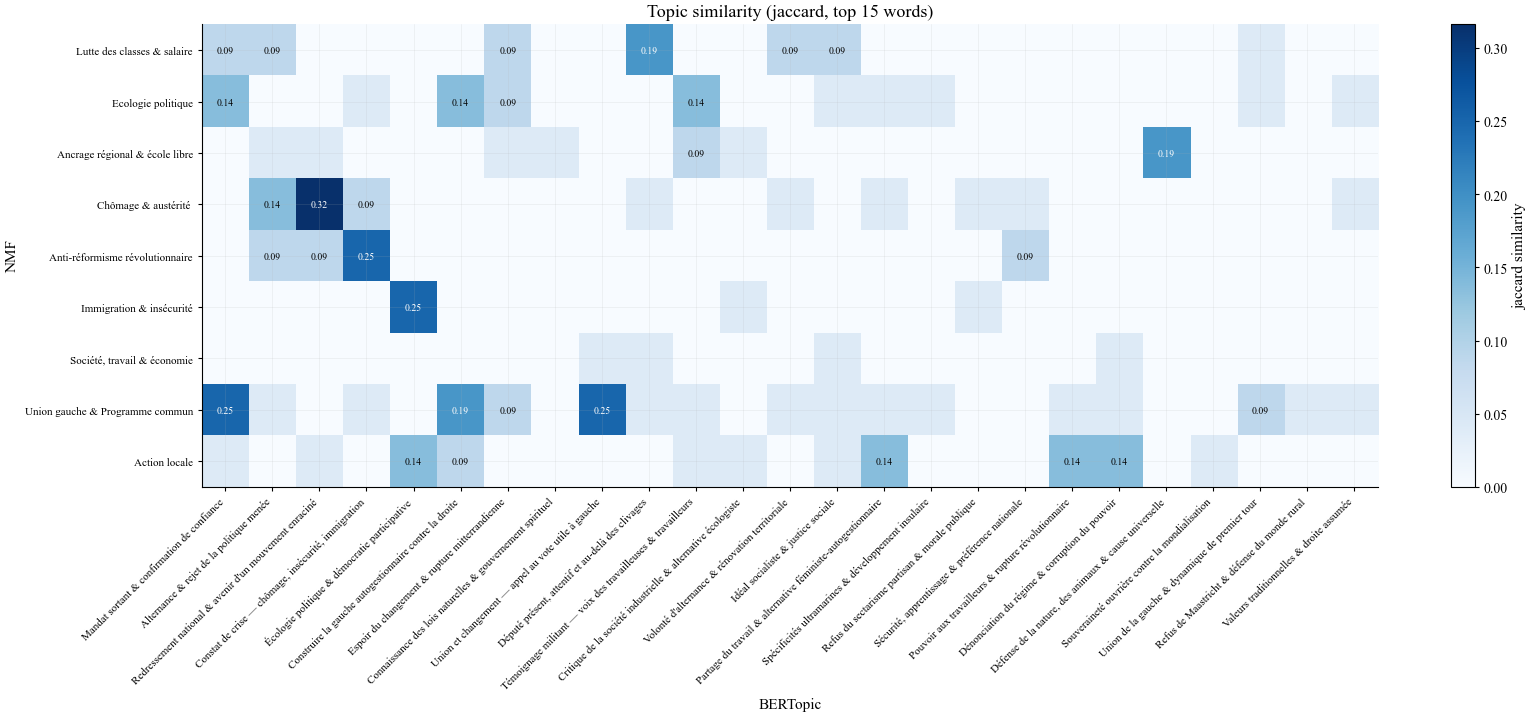

In [67]:
# 2) Topic alignment LDA <-> BERTopic
sim_nmf_bert, matches_nmf_bert = align_topics(
    nmf.get_top_words(15),
    bertopic_model.get_top_words(15),
    n_words=15, method="jaccard",
)
print("\nLDA → closest BERTopic topic:")
print(matches_nmf_bert)

# 3) Heatmap
plot_topic_alignment_matrix(
    nmf.get_top_words(15), bertopic_model.get_top_words(15),
    name_a="NMF", name_b="BERTopic",
    labels_a=lda_labels, labels_b=bertopic_labels,
)
plt.savefig("charts/08_nmf_bertopic_alignment.png", dpi=200, bbox_inches="tight")
plt.show()

Documents per party kept: {'Parti communiste français (PCF)': 2969, 'Parti socialiste (PS)': 2695, 'Rassemblement pour la République (RPR)': 2294, 'Union pour la démocratie française (UDF)': 2018, 'Front national (FN)': 1475, 'Mouvement des radicaux de gauche (MRG)': 1073, 'Lutte ouvrière (LO)': 1030, 'Parti socialiste unifié (PSU)': 707, 'Union des républicains de progrès (URP)': 674, 'Centre national des indépendants et paysans (CNIP)': 629}


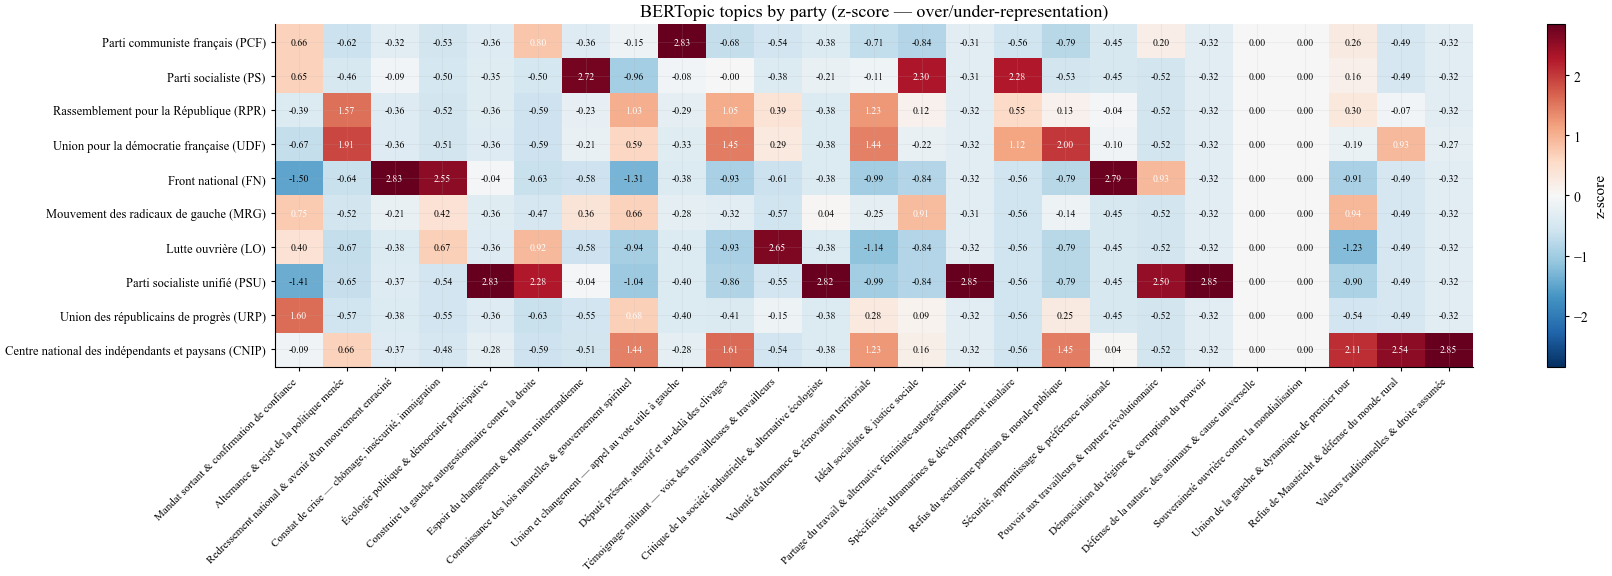

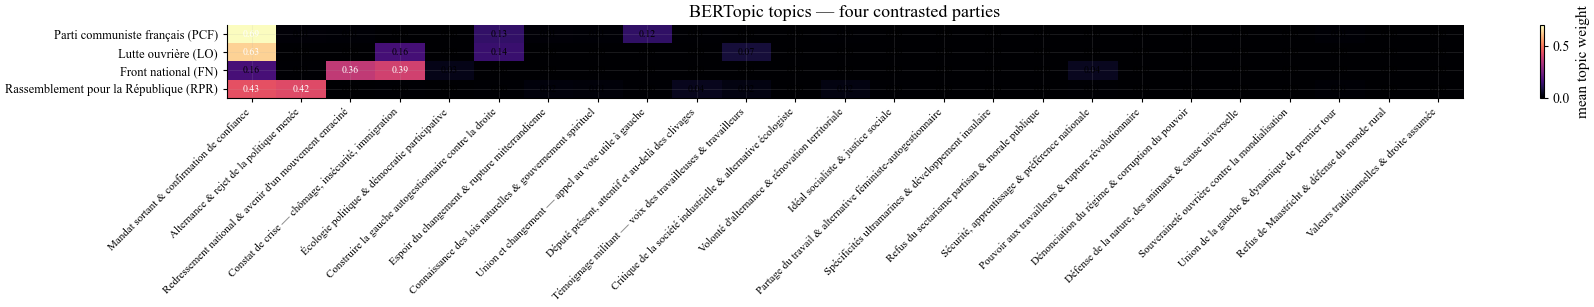

In [68]:
# Topic profile of each of the top 10 parties (by number of supporting docs)
party_dist, party_counts = topics_by_party(
    bertopic_model.get_doc_topic_matrix(),
    party_dummies,
    top_n_parties = 10,
    party_counts  = diagnostic["party_counts"],
    topic_labels  = bertopic_labels,
)
print(f"Documents per party kept: {party_counts.to_dict()}")

plot_topic_group_heatmap(
    party_dist, normalize="z",
    title="BERTopic topics by party (z-score — over/under-representation)",
)
plt.savefig("charts/10_bertopic_topics_by_party.png", dpi=200, bbox_inches="tight")
plt.show()


# Custom party list — example: only the four most ideologically distinct
custom = [
    "Parti communiste français (PCF)",
    "Lutte ouvrière (LO)",
    "Front national (FN)",
    "Rassemblement pour la République (RPR)",
]
custom_dist, _ = topics_by_party(
    bertopic_model.get_doc_topic_matrix(),
    party_dummies,
    parties=custom,
    topic_labels=bertopic_labels,
)
plot_topic_group_heatmap(
    custom_dist, normalize=None,
    title="BERTopic topics — four contrasted parties",
)
plt.show()

Documents per family: {'Extrême gauche': 1617, 'Gauche communiste': 3020, 'Gauche socialiste': 3120, 'Gauche alternative': 1140, 'Écologistes': 1316, 'Centre': 3583, 'Droite': 3653, 'Extrême droite': 1602, 'Divers / Sans étiquette': 1362}


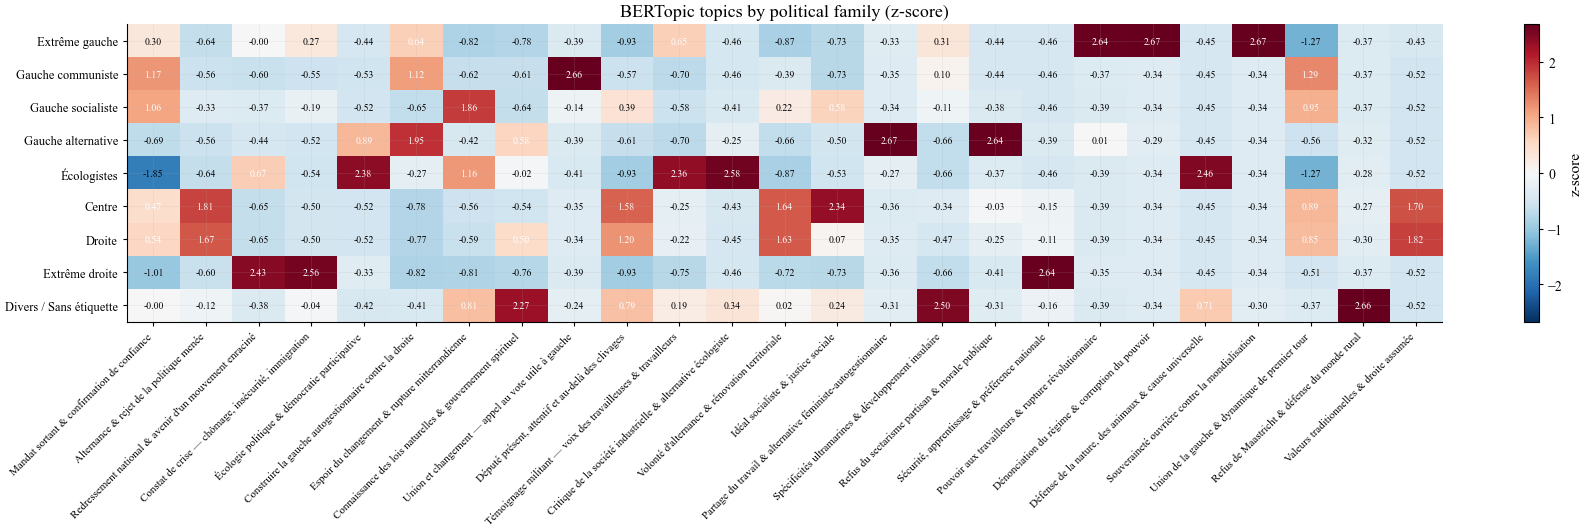

In [69]:
fam_dist, fam_counts = topics_by_family(
    bertopic_model.get_doc_topic_matrix(),
    family_dummies,
    topic_labels=bertopic_labels,
)
print(f"Documents per family: {fam_counts.to_dict()}")

plot_topic_group_heatmap(
    fam_dist, normalize="z",
    title="BERTopic topics by political family (z-score)",
)
plt.savefig("charts/10_bertopic_topics_by_family.png", dpi=200, bbox_inches="tight")
plt.show()

Documents per occupation kept: {'professeur (collège, lycée)': 1178, 'médecin': 707, 'ouvrier': 625, 'avocat': 561, 'ingénieur': 495, 'cadre': 489, 'professeur université': 331, "chef d'entreprise": 326, 'instituteur': 291, 'employé': 278}


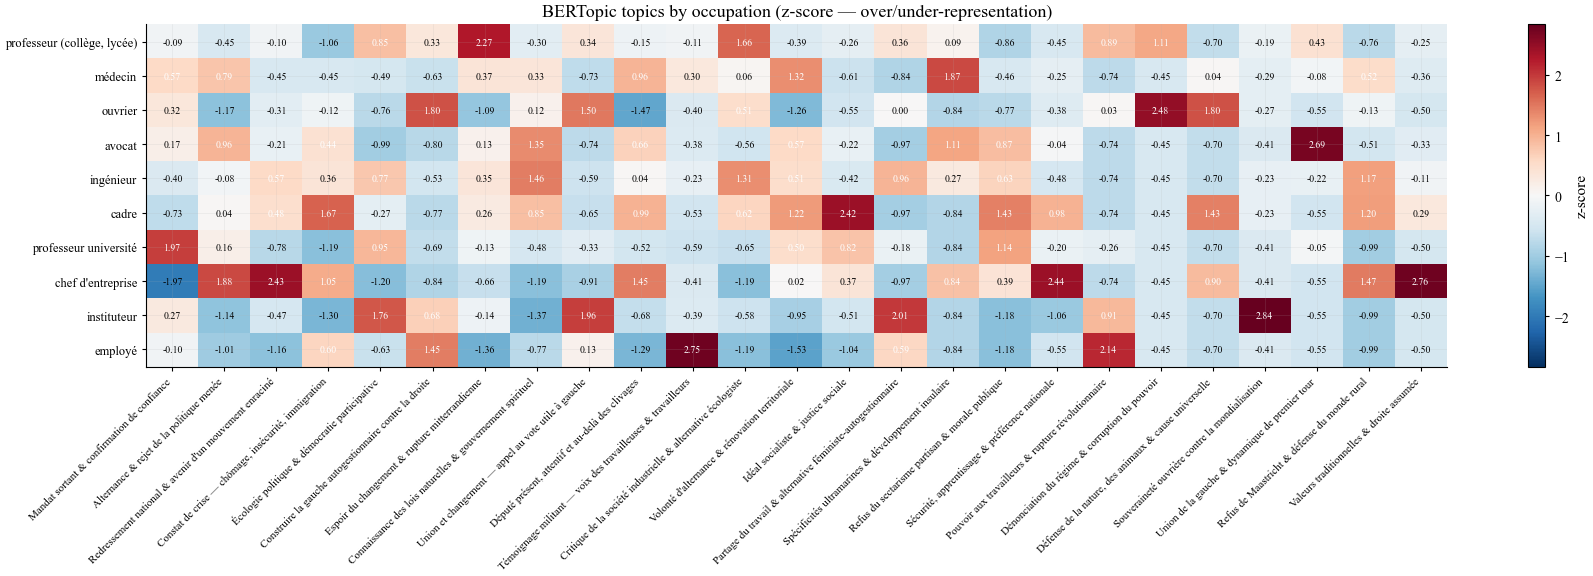

In [70]:
# Topic profile of each of the top 10 occupations (by number of supporting docs)
occ_dist, occ_counts = topics_by_party(
    bertopic_model.get_doc_topic_matrix(),
    occ_dummies,
    top_n_parties = 10,
    party_counts  = diag["occupation_counts"],
    topic_labels  = bertopic_labels,
)
print(f"Documents per occupation kept: {occ_counts.to_dict()}")

plot_topic_group_heatmap(
    occ_dist, normalize="z",
    title="BERTopic topics by occupation (z-score — over/under-representation)",
)
plt.savefig("charts/10bis_bertopic_topics_by_occupation.png", dpi=200, bbox_inches="tight")
plt.show()

Documents per occupation category kept: {'Enseignement & recherche': 2571, 'Cadres & dirigeants': 1799, 'Santé': 1309, 'Ingénierie & technique': 1152, 'Ouvriers': 1107, 'Employés & services': 1091, 'Justice & droit': 769, 'Fonction publique & forces': 565, 'Commerce & artisanat': 497, 'Médias, arts & culture': 426}


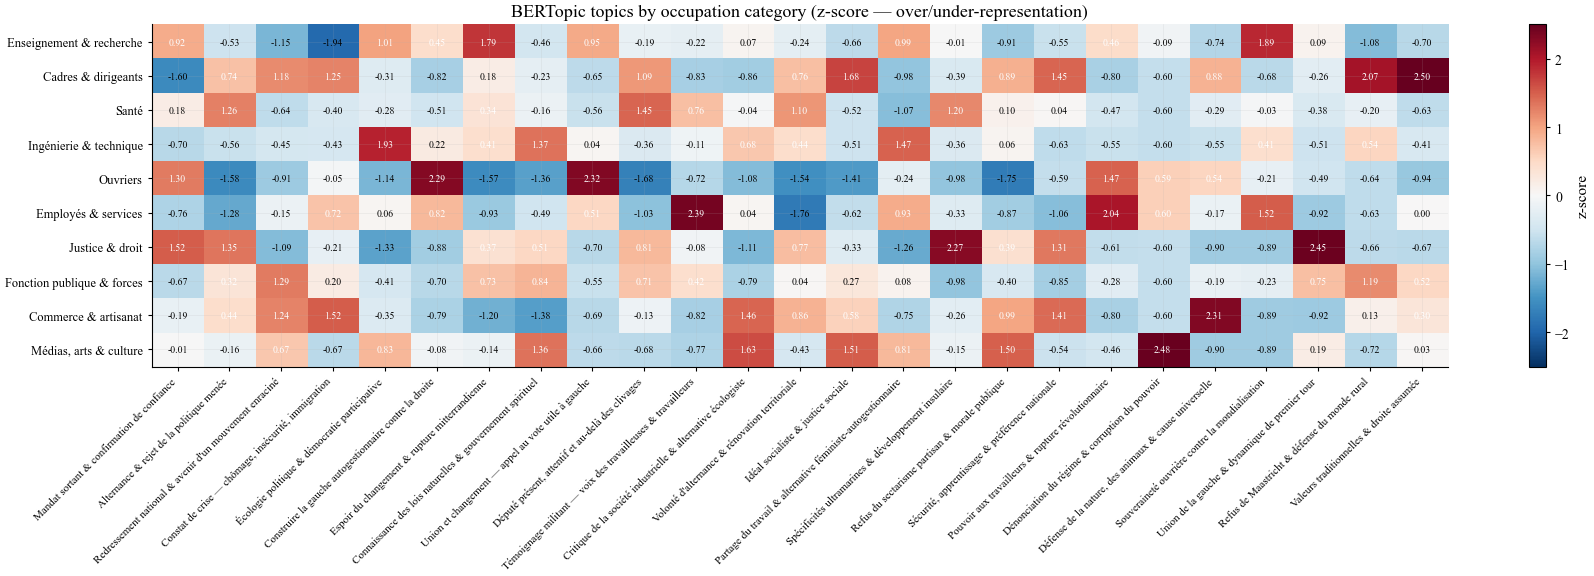

In [71]:
# Topic profile of each of the top 10 occupations (by number of supporting docs)
cat_dist, cat_counts = topics_by_party(
    bertopic_model.get_doc_topic_matrix(),
    cat_dummies,
    topic_labels  = bertopic_labels,
)
print(f"Documents per occupation category kept: {cat_counts.to_dict()}")

plot_topic_group_heatmap(
    cat_dist, normalize="z",
    title="BERTopic topics by occupation category (z-score — over/under-representation)",
)
plt.savefig("charts/10bis_bertopic_topics_by_occ_category.png", dpi=200, bbox_inches="tight")
plt.show()

5it [00:08,  1.69s/it]

topics_over_time shape: (104, 4)
   Topic                                        Words  Frequency  Timestamp
0      0     communiste, commun, gauche, fonds, union       3089       1973
1      1         fonds, union, maire, conseiller, imp         53       1973
2      2     roland, rene, gauche, exode rural, fonds          3       1973
3      3       gauche, udf, rpr, immigration, radical         15       1973
4      4  autogestion, psu, socialisme, finir, projet        228       1973


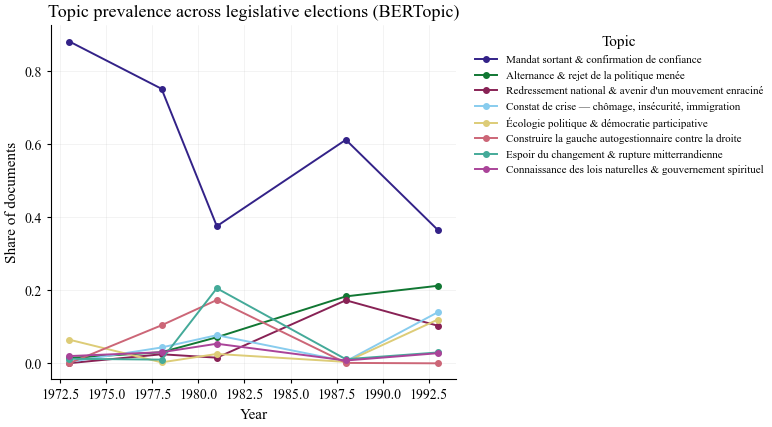


Normalised prevalence per year (top 8 topics):
Topic      Mandat sortant & confirmation de confiance  \
Timestamp                                               
1973                                            0.881   
1978                                            0.751   
1981                                            0.376   
1988                                            0.612   
1993                                            0.365   

Topic      Alternance & rejet de la politique menée  \
Timestamp                                             
1973                                          0.015   
1978                                          0.031   
1981                                          0.072   
1988                                          0.184   
1993                                          0.213   

Topic      Redressement national & avenir d'un mouvement enraciné  \
Timestamp                                                           
1973                        

In [72]:
# BERTopic's native temporal analysis. The `years` series must align with
# the documents passed to fit(), i.e. df_clean.

tot = bertopic_model.topics_over_time(
    timestamps        = df_clean["year"],
    evolution_tuning  = True,              # smoothing, helps readability
)
print(f"topics_over_time shape: {tot.shape}")
print(tot.head())
tot.to_csv("data/processed/bertopic_topics_over_time.csv", index=False)

# Static matplotlib plot (BERTopic's native plot is interactive Plotly,
# unsuitable for the PDF report)
fig, prevalence = plot_bertopic_topics_over_time(
    tot, top_n_topics=8, topic_labels=BERTOPIC_LABELS,
    normalize=True,
)
plt.savefig("charts/09a_bertopic_topics_over_time.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nNormalised prevalence per year (top 8 topics):")
print(prevalence.round(3))

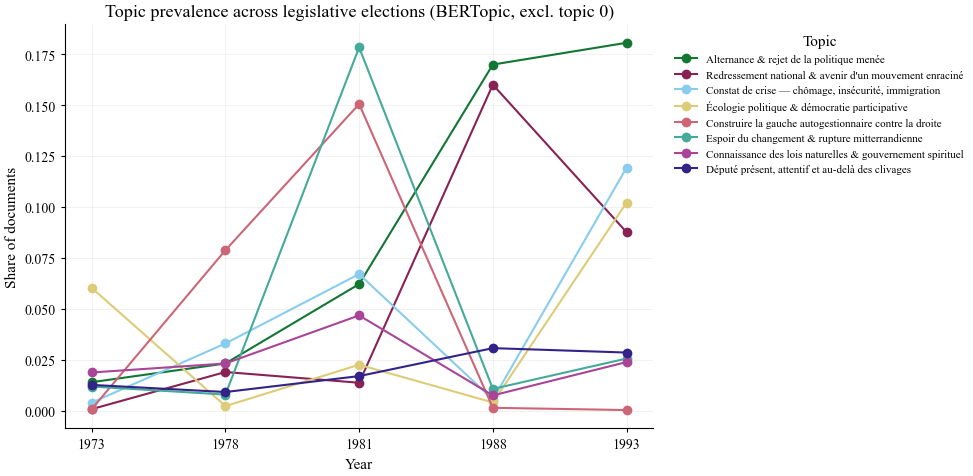

In [73]:
# 1. Construire la matrice prevalence : year × topic

# Récupère les assignations doc→topic et les années correspondantes
topic_assignments = bertopic_model._topic_assignments  # array (n_docs,)
years = df_clean["year"].astype(int).values            # array (n_docs,)

# Compte les docs par (année, topic)
df_counts = pd.DataFrame({"year": years, "topic": topic_assignments})
counts = (df_counts
          .groupby(["year", "topic"])
          .size()
          .unstack(fill_value=0)
          .sort_index())

# Normalise pour que chaque année somme à 1 (part de chaque topic dans l'année)
prevalence = counts.div(counts.sum(axis=1), axis=0)



# 2. Sélectionner les topics à afficher : top 8 hors topic 0

EXCLUDE = {0}     # ajoute d'autres topics à exclure si besoin
TOP_N   = 8

# Classe les topics par prévalence moyenne sur le corpus, hors EXCLUDE
mean_prevalence = prevalence.mean(axis=0).drop(labels=EXCLUDE, errors="ignore")
topics_to_plot  = mean_prevalence.nlargest(TOP_N).index.tolist()

# Sous-ensemble + ré-ordonnance pour avoir les courbes les plus prévalentes en premier
plot_df = prevalence[topics_to_plot]

# Renomme les colonnes avec tes labels thématiques
plot_df = plot_df.rename(columns={tid: BERTOPIC_LABELS.get(tid, f"Topic {tid}")
                                  for tid in plot_df.columns})



# 3. Plot — couleurs cohérentes avec le graphique complet

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Sélection des top-N topics (incluant le 0) par prévalence moyenne
top_n_all = prevalence.mean(axis=0).nlargest(TOP_N).index.tolist()

# IMPORTANT : on trie ensuite par ID croissant — c'est ce que pivot_table
# fait dans le helper d'origine, et donc l'ordre dans lequel matplotlib
# pioche les couleurs séquentiellement.
top_n_all_sorted = sorted(top_n_all)

# Mappage couleur fixe : i-ème ID croissant → i-ème couleur de la palette
color_map = {tid: default_colors[i % len(default_colors)]
             for i, tid in enumerate(top_n_all_sorted)}

# Pour les éventuels topics ajoutés après suppression du 0 (cas où
# `topics_to_plot` contient un topic hors `top_n_all`), fallback couleurs
fallback_idx = TOP_N
for tid in topics_to_plot:
    if tid not in color_map:
        color_map[tid] = default_colors[fallback_idx % len(default_colors)]
        fallback_idx += 1

# Plot — on respecte aussi l'ordre par ID croissant pour la légende
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(plot_df.index))
year_labels = [str(y) for y in plot_df.index]

for tid in sorted(topics_to_plot):
    label = BERTOPIC_LABELS.get(tid, f"Topic {tid}")
    ax.plot(
        x_positions,
        prevalence[tid].values,
        marker="o", linewidth=1.5, markersize=6,
        label=label,
        color=color_map[tid],
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(year_labels)
ax.set_xlabel("Year")
ax.set_ylabel("Share of documents")
ax.set_title("Topic prevalence across legislative elections (BERTopic, excl. topic 0)")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Topic",
          frameon=False)

plt.tight_layout()
plt.savefig("charts/09b_bertopic_topics_over_time_zoomed.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Studying in detail the temporal evolution

### 4.1 Decomposition time x parties x topics : effect shift-share


=== NMF : décomposition shift-share 1973 → 1993 ===
                                      P_start  P_end  delta_total  \
topic                                                               
Action locale & dév. éco.               0.377  0.243       -0.134   
Anti-réformisme révol.                  0.048  0.013       -0.035   
Cause animale & nature                  0.017  0.118        0.101   
Préférence nationale & baisse impôts    0.013  0.025        0.012   
Insécurité et immigration               0.027  0.194        0.166   
Écologie politique                      0.008  0.177        0.169   
Lutte des classes                       0.026  0.079        0.054   
Union gauche & Programme commun         0.240  0.103       -0.138   
Autogestion & anticapitalisme           0.243  0.049       -0.194   

                                      effect_composition  effect_intensity  \
topic                                                                        
Action locale & dév. éco.      

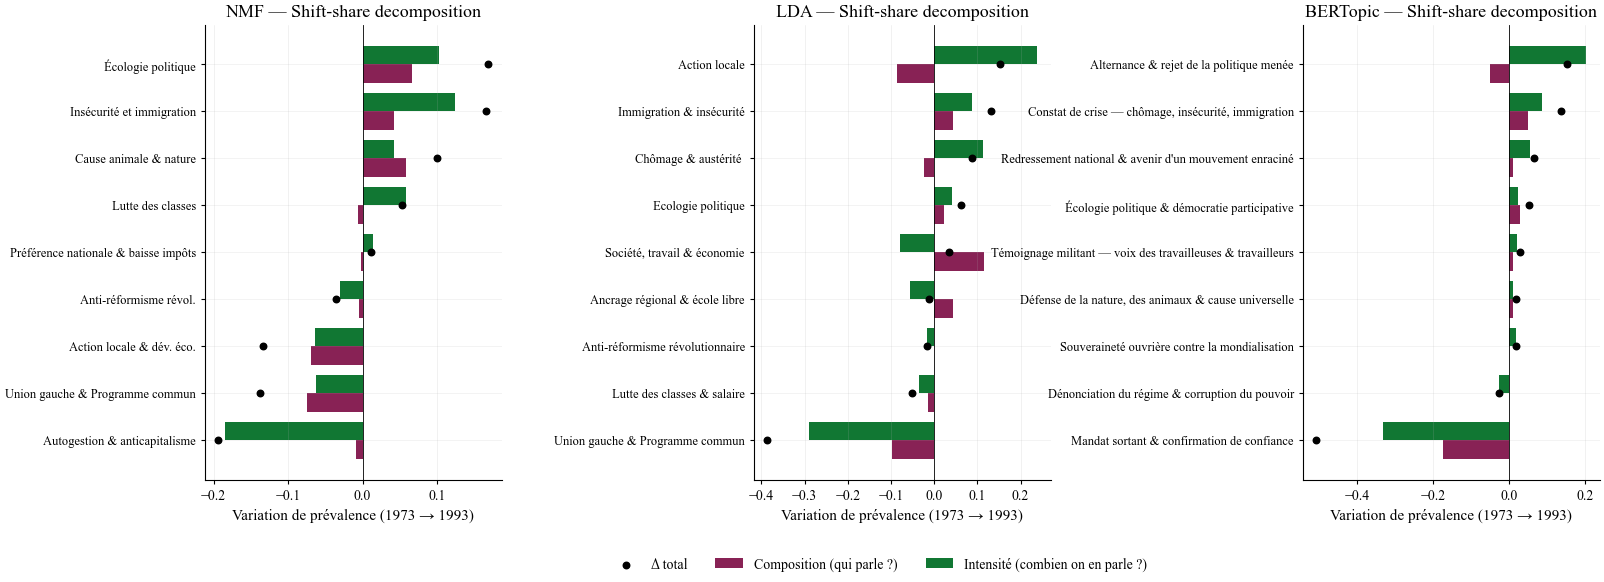



=== Lecture : topics les plus 'composition-driven' vs 'intensity-driven' ===

--- NMF ---
Topics dominés par la COMPOSITION (déclin = parti porteur disparaît) :
                                 delta_total  effect_composition  \
topic                                                              
Cause animale & nature                 0.101               0.058   
Union gauche & Programme commun       -0.138              -0.075   
Action locale & dév. éco.             -0.134              -0.070   

                                 effect_intensity  
topic                                              
Cause animale & nature                      0.042  
Union gauche & Programme commun            -0.063  
Action locale & dév. éco.                  -0.064  

Topics dominés par l'INTENSITÉ (les partis changent leur discours) :
                                      delta_total  effect_composition  \
topic                                                                   
Autogestion & antica

In [74]:
YEAR_START = int(df_clean["year"].min())
YEAR_END   = int(df_clean["year"].max())

models_config = [
    ("NMF",      nmf.get_doc_topic_matrix(),             nmf_labels),
    ("LDA",      lda.get_doc_topic_matrix(),             lda_labels),
    ("BERTopic", bertopic_model.get_doc_topic_matrix(),  bertopic_labels),
]

# Combien de topics afficher pour BERTopic (les autres modèles non filtrés)
BERTOPIC_TOP_N = 9

decomp_results       = {}      # décompositions complètes (pour analyse)
decomp_results_plot  = {}      # versions filtrées pour BERTopic (pour graphique)
tensors              = {}

for name, dt, labels in models_config:
    P, w = build_tyk_tensor(dt, family_dummies, df_clean["year"], labels)
    decomp = shift_share_decomposition(P, w, YEAR_START, YEAR_END)
    decomp_results[name] = decomp
    tensors[name]        = (P, w)

    # Filtrage UNIQUEMENT pour BERTopic
    if name == "BERTopic":
        # Trier par |delta_total| décroissant et garder les top N
        top_topics = (decomp["delta_total"].abs()
                                          .nlargest(BERTOPIC_TOP_N)
                                          .index)
        decomp_results_plot[name] = decomp.loc[top_topics]
        print(f"\n=== {name} : décomposition shift-share {YEAR_START} → {YEAR_END} ===")
        print(f"(Affichage des {BERTOPIC_TOP_N} topics avec la plus grande variation)")
        print(decomp_results_plot[name].round(3))
    else:
        decomp_results_plot[name] = decomp
        print(f"\n=== {name} : décomposition shift-share {YEAR_START} → {YEAR_END} ===")
        print(decomp.round(3))



# Figure 3 panneaux côte-à-côte
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6.5),                          # un peu plus haut pour laisser place à la légende
    gridspec_kw={"wspace": 0.85, "bottom": 0.18},  # bottom margin pour la légende
)

for ax, (name, dec) in zip(axes, decomp_results_plot.items()):
    plot_shift_share(dec, name, YEAR_START, YEAR_END, ax=ax)
    # Supprime la légende individuelle de chaque sous-graphique
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Récupère les handles et labels du premier panneau (ils sont identiques sur les 3)
handles, labels = axes[0].get_legend_handles_labels()

# Légende globale, centrée sous la figure, sur une seule ligne
fig.legend(
    handles, labels,
    loc            = "lower center",
    bbox_to_anchor = (0.5, 0.02),               # centré horizontalement, près du bas
    ncol           = len(labels),               # tout sur une ligne
    fontsize       = 10,
    frameon        = False,
)

plt.savefig("charts/11_shift_share_decomposition.png",
            dpi=200, bbox_inches="tight")
plt.show()


# Diagnostic textuel : top 3 composition-driven vs intensity-driven
# (sur la décomposition COMPLÈTE, pas filtrée — analyse sur tous les topics)
print("\n\n=== Lecture : topics les plus 'composition-driven' vs 'intensity-driven' ===")
for name, dec in decomp_results.items():
    dec = dec.copy()
    denom = dec["effect_composition"].abs() + dec["effect_intensity"].abs()
    dec["compo_share"] = dec["effect_composition"].abs() / denom.replace(0, np.nan)

    # Pour BERTopic, on filtre aussi le diagnostic aux topics qui bougent
    if name == "BERTopic":
        # On ne garde que les topics avec une variation non-négligeable,
        # sinon on diagnostique des topics statiques avec compo_share très bruité
        movers = dec["delta_total"].abs() > dec["delta_total"].abs().quantile(0.5)
        dec = dec[movers]

    print(f"\n--- {name} ---")
    print("Topics dominés par la COMPOSITION (déclin = parti porteur disparaît) :")
    print(dec.nlargest(3, "compo_share")[["delta_total",
                                           "effect_composition",
                                           "effect_intensity"]].round(3))
    print("\nTopics dominés par l'INTENSITÉ (les partis changent leur discours) :")
    print(dec.nsmallest(3, "compo_share")[["delta_total",
                                            "effect_composition",
                                            "effect_intensity"]].round(3))

Transitions analysées : [(np.int32(1973), np.int32(1978)), (np.int32(1978), np.int32(1981)), (np.int32(1981), np.int32(1988)), (np.int32(1988), np.int32(1993))]


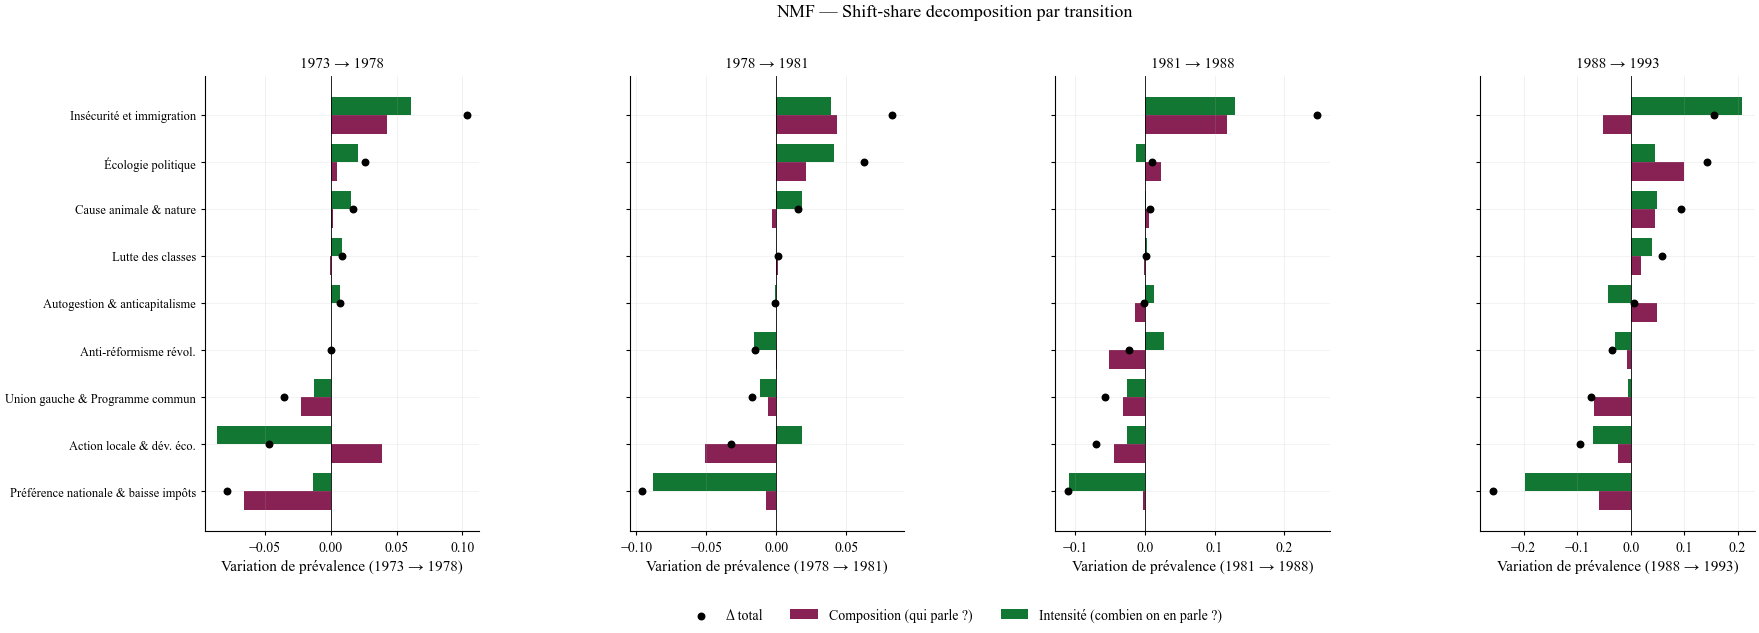

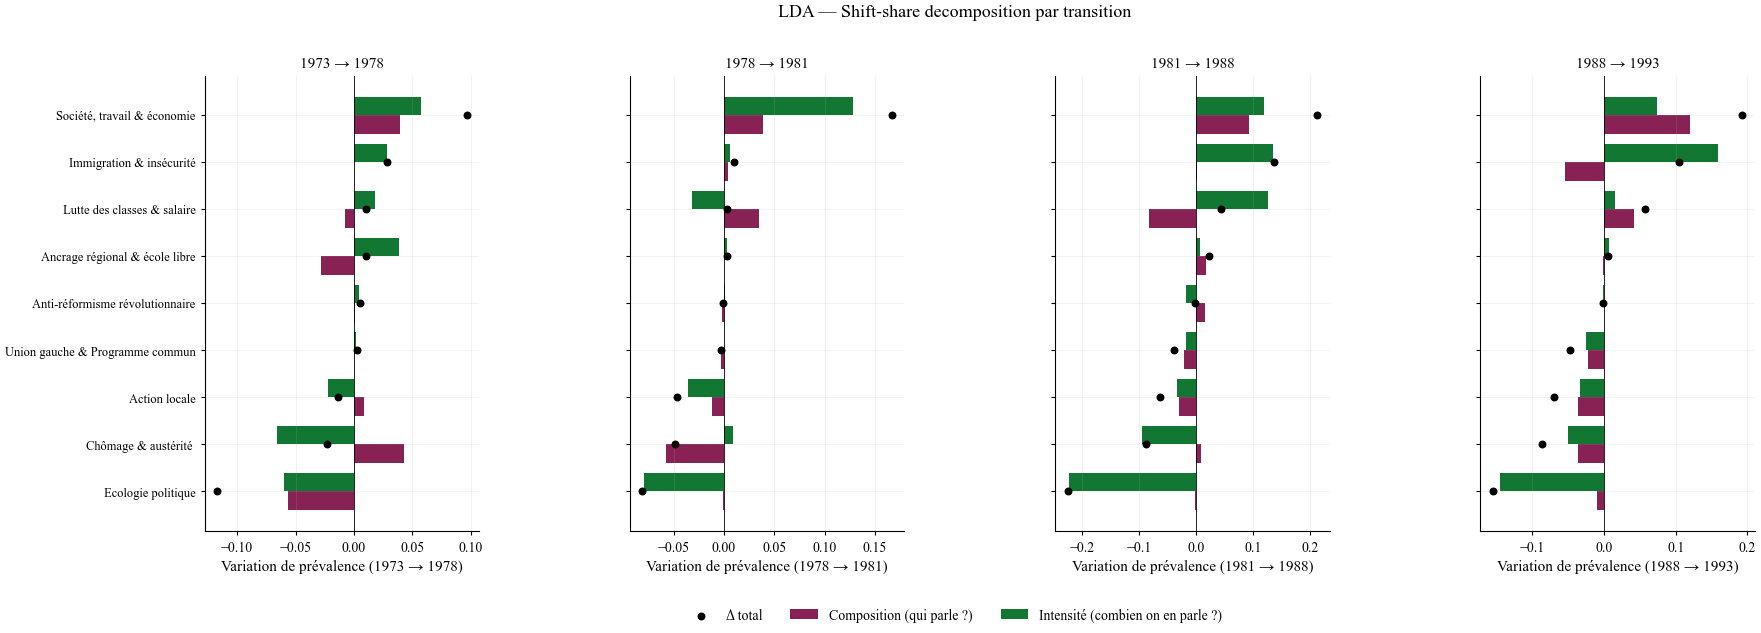

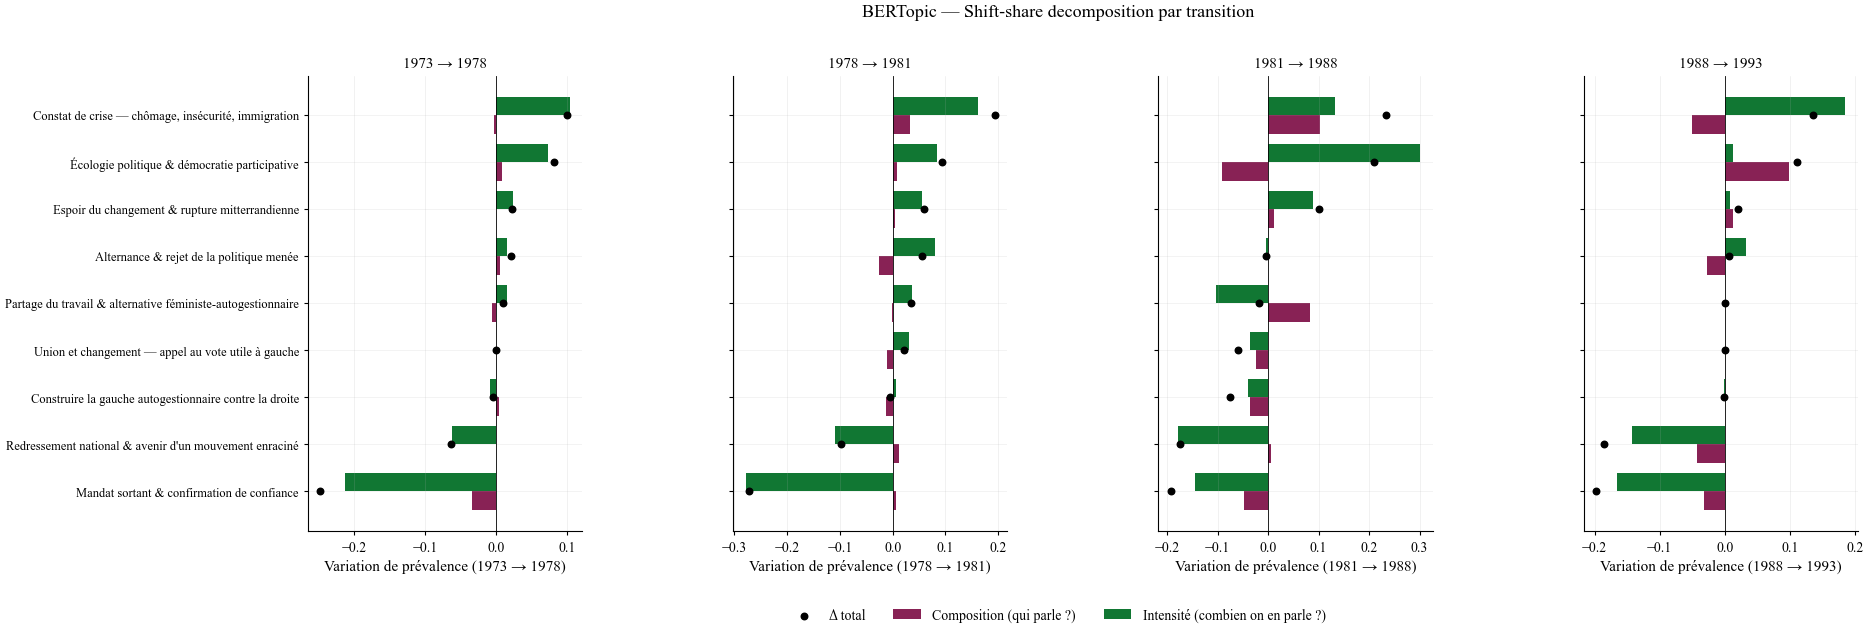

In [75]:
# -----------------------------------------------------------------------------
# Décomposition shift-share par transition consécutive
# -----------------------------------------------------------------------------

# Toutes les transitions consécutives
years_sorted = sorted(df_clean["year"].unique())
transitions = list(zip(years_sorted[:-1], years_sorted[1:]))
print(f"Transitions analysées : {transitions}")

# Stockage : decomp_by_transition[model_name][(y0, y1)] = DataFrame
decomp_by_transition = {name: {} for name, _, _ in models_config}

for name, dt, labels in models_config:
    P, w = tensors[name]   # déjà calculés dans la cellule précédente
    for y0, y1 in transitions:
        decomp_by_transition[name][(y0, y1)] = shift_share_decomposition(
            P, w, y0, y1
        )

# -----------------------------------------------------------------------------
# Visualisation : pour chaque modèle, une figure avec 4 panneaux (1 par transition)
# -----------------------------------------------------------------------------

# Pour BERTopic, on filtre les topics aux 9 plus mouvants AGRÉGÉS sur les 4 transitions
# (sinon les topics sélectionnés peuvent varier entre transitions, peu lisible)
def select_top_topics_bertopic(decomp_by_trans_for_model, top_n=9):
    """Topics les plus mouvants en cumulé sur toutes les transitions."""
    cumulative_movement = sum(
        d["delta_total"].abs() for d in decomp_by_trans_for_model.values()
    )
    return cumulative_movement.nlargest(top_n).index

for name in [n for n, _, _ in models_config]:
    decomps = decomp_by_transition[name]

    # Filtrage BERTopic
    if name == "BERTopic":
        keep_topics = select_top_topics_bertopic(decomps, top_n=9)
        decomps_plot = {tr: d.loc[keep_topics] for tr, d in decomps.items()}
    else:
        decomps_plot = decomps

    n_trans = len(transitions)
    fig, axes = plt.subplots(
        1, n_trans,
        figsize=(5 * n_trans, 6.5),
        gridspec_kw={"wspace": 0.55, "bottom": 0.18},
        sharey=True,                  # même ordre de topics sur tous les panneaux
    )

    for ax, (y0, y1) in zip(axes, transitions):
        plot_shift_share(decomps_plot[(y0, y1)], name, y0, y1, ax=ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        ax.set_title(f"{y0} → {y1}", fontsize=11)

    fig.suptitle(f"{name} — Shift-share decomposition par transition",
                 fontsize=13, y=0.99)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc            = "lower center",
               bbox_to_anchor = (0.5, 0.02),
               ncol           = len(labels),
               fontsize       = 10,
               frameon        = False)

    plt.savefig(f"charts/11b_shift_share_by_transition_{name.lower()}.png",
                dpi=200, bbox_inches="tight")
    plt.show()

### 4.2 Topics prevalence evolution overtime by parties or political families

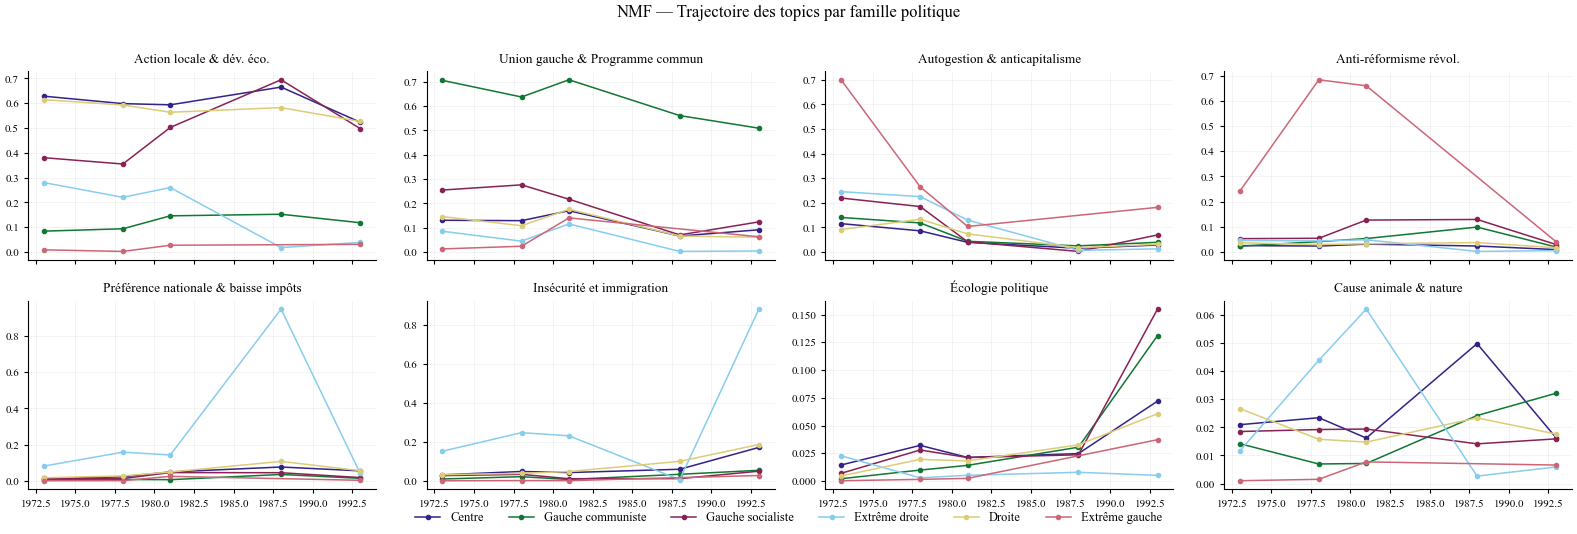

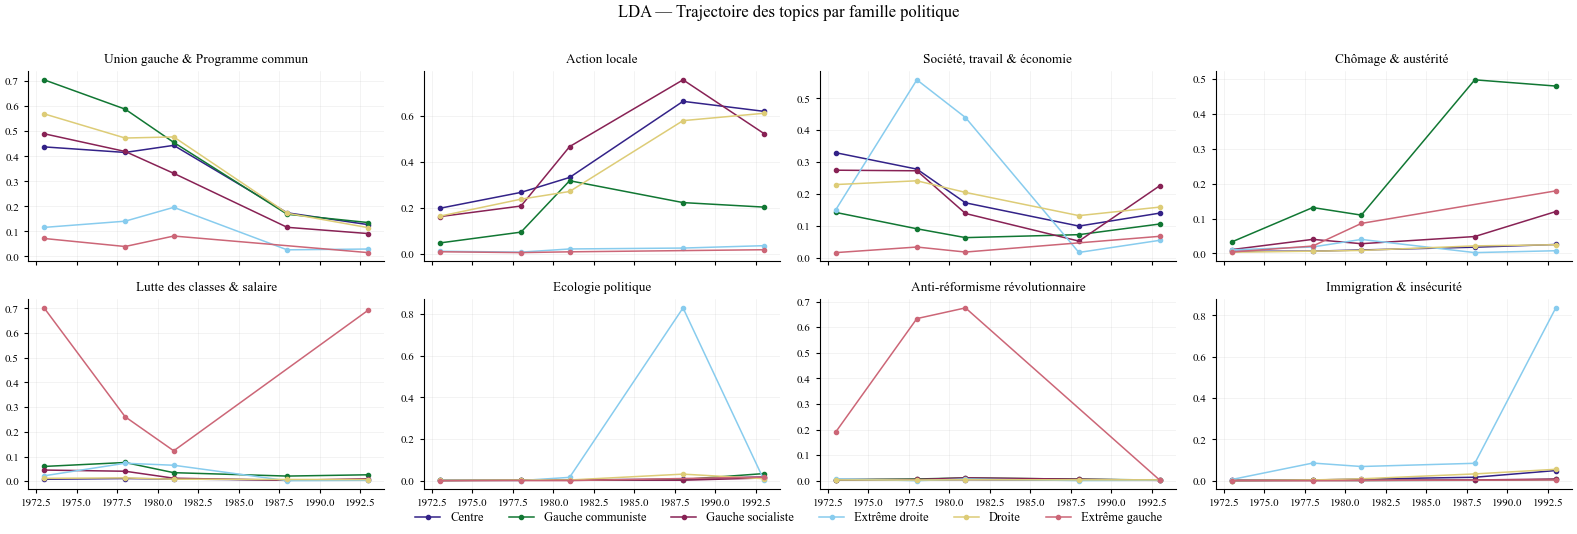

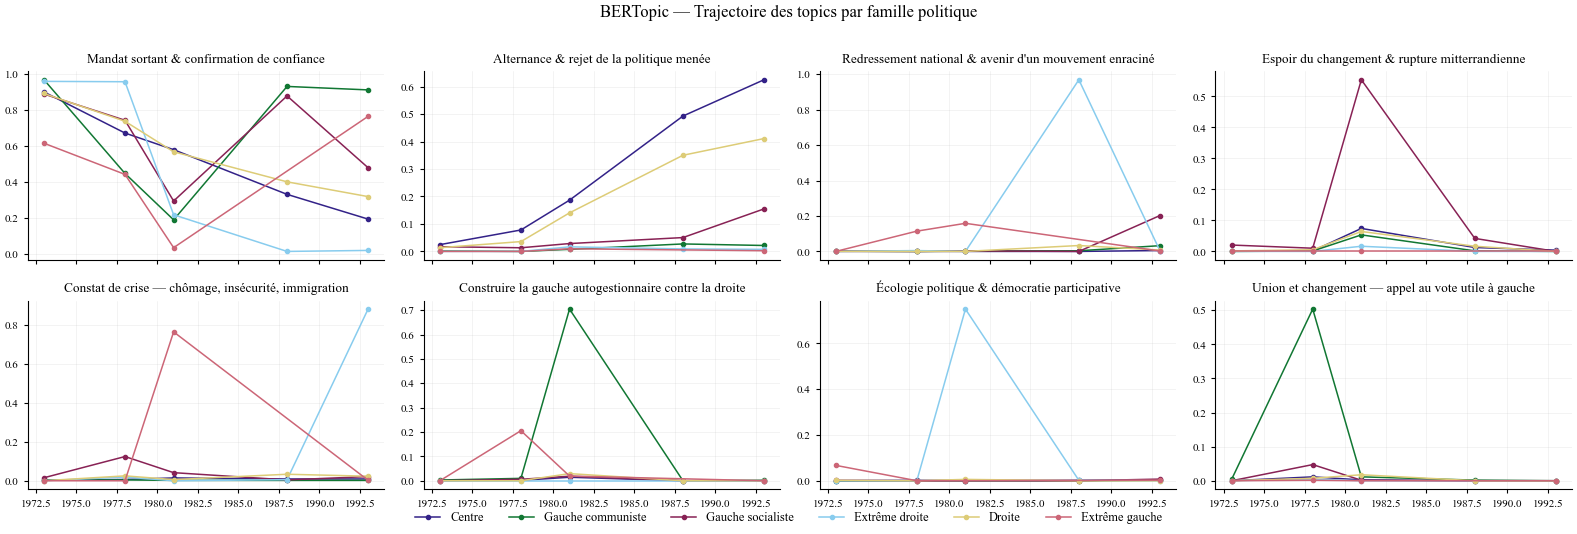

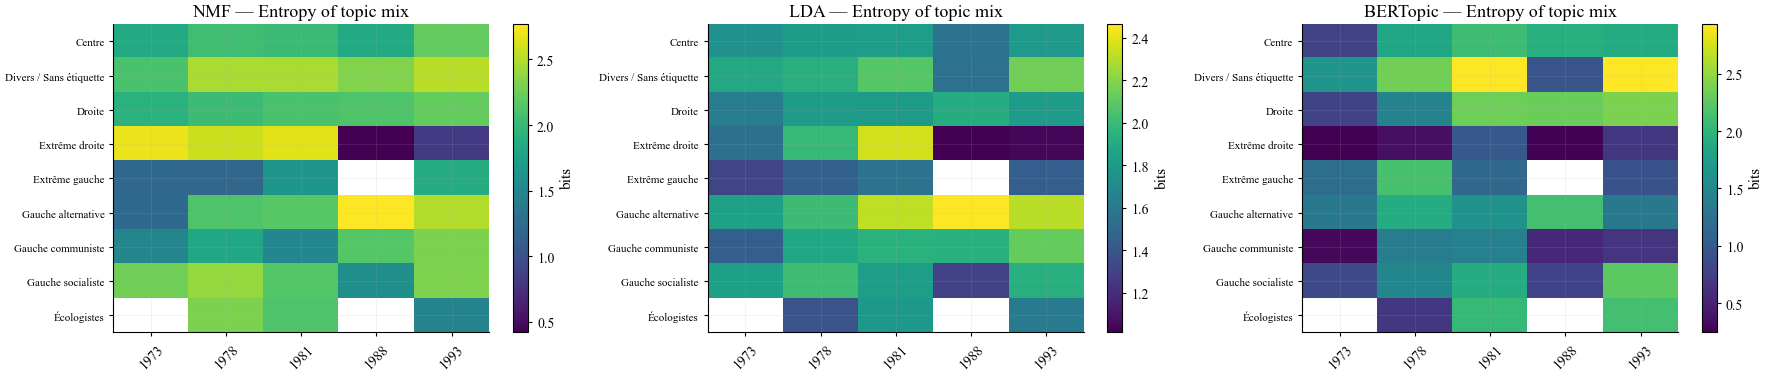


=== Recomposition discursive globale (JSD entre élections successives) ===
model       BERTopic    LDA    NMF
transition                        
1973→1978      0.448  0.211  0.187
1978→1981      0.493  0.201  0.157
1981→1988      0.599  0.466  0.332
1988→1993      0.462  0.365  0.481


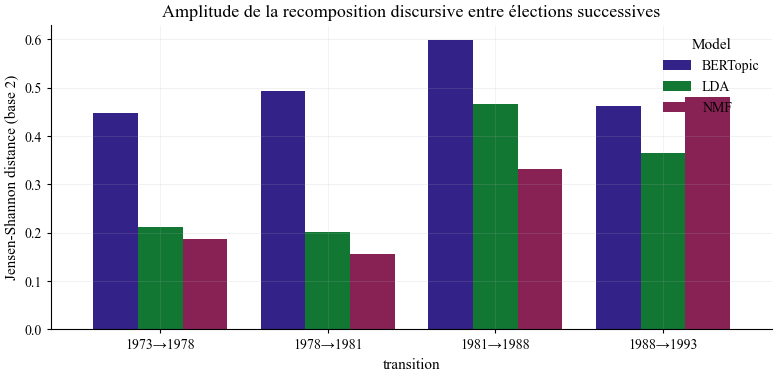

In [76]:
# (1) Small multiples : trajectoires par famille
for name, (P, w) in tensors.items():
    fig = plot_topic_trajectories_by_family(P, w, name,
                                             top_n_topics=8,
                                             top_n_families=6)
    fig.savefig(f"charts/12_trajectories_{name.lower()}.png",
                dpi=200, bbox_inches="tight")
    plt.show()

# (2) Concentration discursive (entropie) par famille × année
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, (P, w)) in zip(axes, tensors.items()):
    H = topic_concentration_by_family(P, w)
    im = ax.imshow(H.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(H.columns)))
    ax.set_xticklabels(H.columns, rotation=45)
    ax.set_yticks(range(len(H.index)))
    ax.set_yticklabels(H.index, fontsize=8)
    ax.set_title(f"{name} — Entropy of topic mix")
    plt.colorbar(im, ax=ax, label="bits")
plt.tight_layout()
plt.savefig("charts/13_topic_entropy_by_family.png",
            dpi=200, bbox_inches="tight")
plt.show()

# (3) JSD inter-élections : amplitude des recompositions
print("\n=== Recomposition discursive globale (JSD entre élections successives) ===")
jsd_table = []
for name, (P, w) in tensors.items():
    jsd = jsd_between_elections(P, w)
    jsd["model"] = name
    jsd_table.append(jsd)
jsd_all = pd.concat(jsd_table)
print(jsd_all.pivot(index="transition", columns="model", values="JSD").round(3))

# Visualisation : barres groupées
fig, ax = plt.subplots(figsize=(8, 4))
pivot = jsd_all.pivot(index="transition", columns="model", values="JSD")
pivot.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Jensen-Shannon distance (base 2)")
ax.set_title("Amplitude de la recomposition discursive entre élections successives")
ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title="Model", frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("charts/14_jsd_between_elections.png",
            dpi=200, bbox_inches="tight")
plt.show()

Top 10 parties (sur tout le corpus) : ['Parti communiste français (PCF)', 'Parti socialiste (PS)', 'Rassemblement pour la République (RPR)', 'Union pour la démocratie française (UDF)', 'Front national (FN)', 'Mouvement des radicaux de gauche (MRG)', 'Lutte ouvrière (LO)', 'Parti socialiste unifié (PSU)', 'Union des républicains de progrès (URP)', 'Centre national des indépendants et paysans (CNIP)']


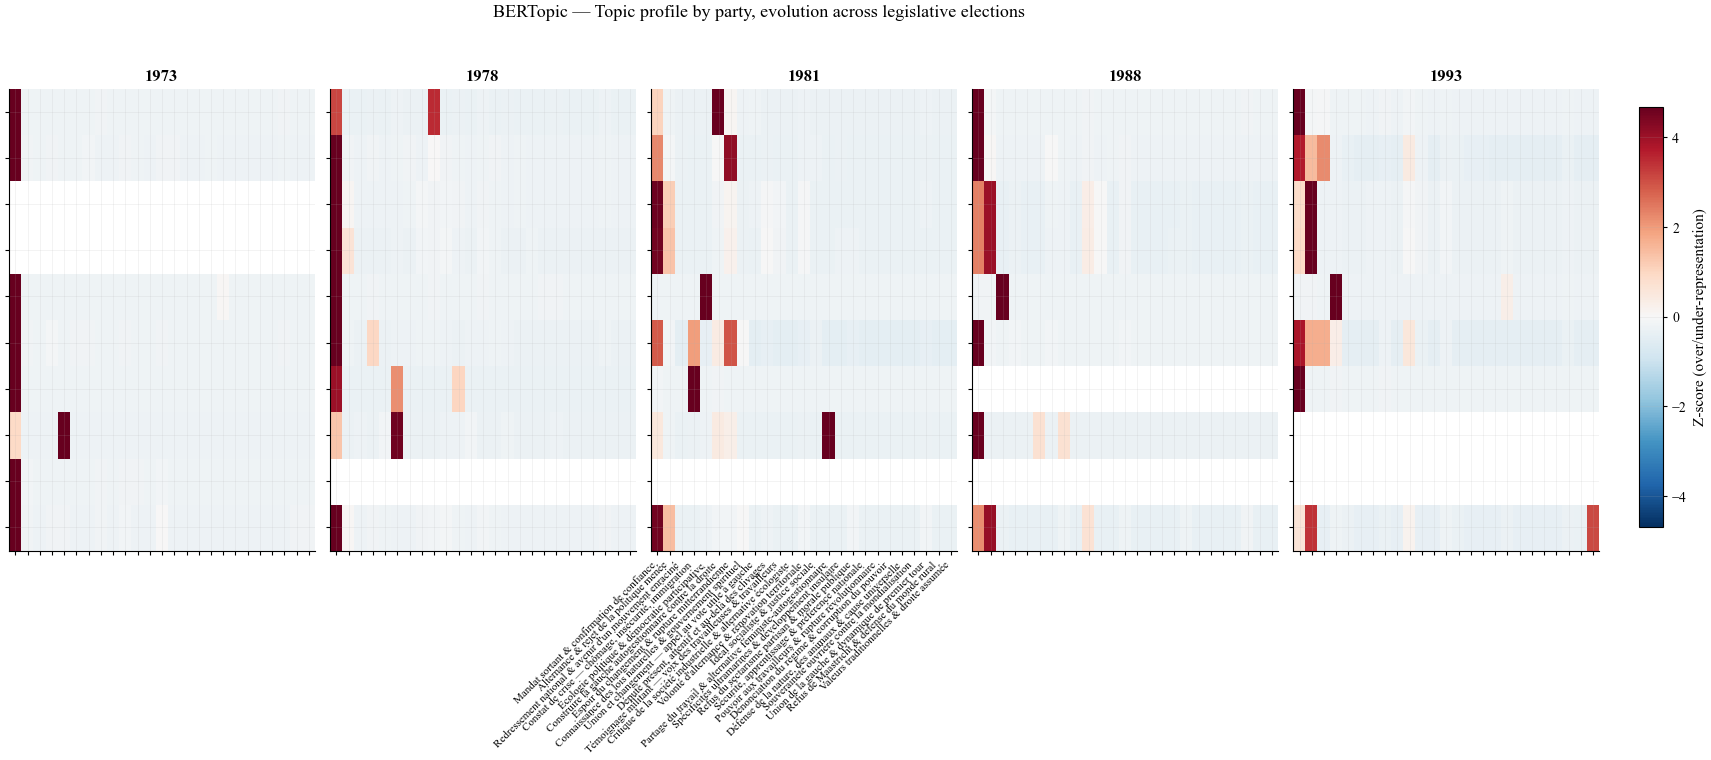

In [78]:
# Liste des partis à afficher (figés sur les 5 années pour la comparabilité)
TOP_PARTIES = (
    pd.Series(diagnostic["party_counts"])
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)
print(f"Top 10 parties (sur tout le corpus) : {TOP_PARTIES}")

# Calcul d'un dist par année
years_sorted = sorted(df_clean["year"].unique())
dist_by_year = {}
counts_by_year = {}

doc_topic_full = bertopic_model.get_doc_topic_matrix()

for y in years_sorted:
    mask = (df_clean["year"] == y).values
    dt_y = doc_topic_full[mask]
    pd_y = party_dummies.iloc[mask].reset_index(drop=True)

    # On ne calcule la moyenne que pour les partis présents avec assez de docs cette année
    # On laisse passer min_docs=5 (plus permissif que les 10 par défaut, sinon trop de NaN)
    rows = {}
    for p in TOP_PARTIES:
        if p not in pd_y.columns:
            continue
        m = pd_y[p].values.astype(bool)
        n = int(m.sum())
        if n >= 5:
            rows[p] = dt_y[m].mean(axis=0)
    if not rows:
        continue
    dist_y = pd.DataFrame(rows, index=bertopic_labels).T
    dist_y.index.name = "party"
    dist_by_year[y] = dist_y

# Z-score normalisation par ligne (pour chaque parti, écart à la moyenne)
def to_zscore(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1).replace(0, np.nan), axis=0)

dist_by_year_z = {y: to_zscore(d) for y, d in dist_by_year.items()}

# Échelle de couleurs commune aux 5 panneaux pour comparabilité visuelle
all_z = pd.concat(dist_by_year_z.values()).values.flatten()
all_z = all_z[~np.isnan(all_z)]
vmin, vmax = np.percentile(all_z, [2, 98])  # robuste aux outliers
abs_max = max(abs(vmin), abs(vmax))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

# Figure : 5 panneaux côte à côte avec axes partagés
n_years = len(years_sorted)
fig, axes = plt.subplots(
    1, n_years,
    figsize=(4 * n_years, 6),
    gridspec_kw={"wspace": 0.05},   # panneaux serrés puisque les axes sont partagés
    sharey=True,
)

# On veut un ordre fixe pour les axes (parti et topic) — celui de la première année dispo
reference_year = years_sorted[0]
party_order = TOP_PARTIES
topic_order = bertopic_labels

for ax, y in zip(axes, years_sorted):
    if y not in dist_by_year_z:
        ax.set_visible(False)
        continue
    d = dist_by_year_z[y].reindex(index=party_order, columns=topic_order)
    im = ax.imshow(d.values, aspect="auto", cmap="RdBu_r", norm=norm)
    ax.set_title(str(y), fontsize=12, fontweight="bold")
    # Labels des topics seulement en bas, pour le panneau du milieu (centré visuellement)
    ax.set_xticks(range(len(topic_order)))
    ax.set_xticklabels([])  # on les mettra une fois en bas via une astuce
    # Labels des partis seulement sur le premier panneau
    ax.set_yticks(range(len(party_order)))
    if y == years_sorted[0]:
        ax.set_yticklabels(party_order, fontsize=9)
    else:
        ax.set_yticklabels([])

# Labels de topics : seulement sur le panneau du MILIEU, en bas
middle_idx = n_years // 2
axes[middle_idx].set_xticklabels(topic_order, rotation=45, ha="right", fontsize=8)

# Colorbar unique à droite
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Z-score (over/under-representation)")

fig.suptitle("BERTopic — Topic profile by party, evolution across legislative elections",
             fontsize=13, y=1.02)

plt.savefig("charts/10b_bertopic_topics_by_party_by_year.png",
            dpi=200, bbox_inches="tight")
plt.show()